In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms
import seaborn as sns
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from torch.optim import Adam
from torch import optim
from torchvision import datasets

In [ ]:
!pip install -q music21

In [ ]:
!unzip chopin.zip -d chopin

In [ ]:
import os
import music21
import glob



def extract_notes(midi_file):
    """
    Extract notes and chords from a MIDI file

    Args:
        midi_file: Path to the MIDI file

    Returns:
        List of notes and chords
    """
    print(f"Extracting notes from: {midi_file}")

    notes = []

    midi = music21.converter.parse(midi_file)

    instruments = music21.instrument.partitionByInstrument(midi)

    if instruments:  # File has instrument parts
        for part in instruments.parts:
            # Get all notes and chords from this instrument part
            notes_to_parse = part.recurse()

            for element in notes_to_parse:
                if isinstance(element, music21.note.Note):
                    notes.append(str(element.pitch))
                elif isinstance(element, music21.chord.Chord):
                    notes.append('.'.join(str(n) for n in element.normalOrder))
    else:
        notes_to_parse = midi.flat.notes

        for element in notes_to_parse:
            if isinstance(element, music21.note.Note):
                notes.append(str(element.pitch))
            elif isinstance(element, music21.chord.Chord):
                notes.append('.'.join(str(n) for n in element.normalOrder))

    return notes

def preprocess_data(chopin_midi_dir = "./chopin"):

    if not os.path.exists(chopin_midi_dir):
        os.makedirs(chopin_midi_dir)
        print(f"Please place Chopin's MIDI files in the '{chopin_midi_dir}' directory and run the script again.")
        return

    # Get all MIDI files in the directory
    midi_files = glob.glob(f"{chopin_midi_dir}/*.mid")

    if not midi_files:
        print(f"\nNo MIDI files found in '{chopin_midi_dir}' directory.")
        return

    all_pieces_notes = {}

    print("\nExtracting notes from MIDI files:")
    for midi_file in midi_files:
        file_name = os.path.basename(midi_file)
        notes = extract_notes(midi_file)
        all_pieces_notes[file_name] = notes
        print(f"  - {file_name}: Extracted {len(notes)} notes/chords")

    print(f"\nProcessed {len(midi_files)} Chopin MIDI files.")
    total_notes = sum(len(notes) for notes in all_pieces_notes.values())
    print(f"Total notes and chords extracted: {total_notes}")

    # Print a sample of notes from the first piece (if available)
    if all_pieces_notes:
        first_piece = list(all_pieces_notes.keys())[0]
        sample_size = min(10, len(all_pieces_notes[first_piece]))
        print(f"\nSample of notes from '{first_piece}':")
        for i, note in enumerate(all_pieces_notes[first_piece][:sample_size]):
            print(f"  {i+1}. {note}")
    return all_pieces_notes




In [ ]:
all_pieces_notes = preprocess_data()

In [ ]:
from collections import Counter


def process_notes_for_training(all_pieces_notes, min_occurrences=4, sequence_length=40):

    corpus = []
    for piece_name, notes in all_pieces_notes.items():
        corpus.extend(notes)
    print(f"Total notes in corpus: {len(corpus)}")

    note_counter = Counter(corpus)
    print(f"Total unique notes/chords before filtering: {len(note_counter)}")

    # filter notes base on the occurences
    filtered_corpus = [note for note in corpus if note_counter[note] >= min_occurrences ]
    print(f"Corpus size after filtering: {len(filtered_corpus)}")


    # sort and unique the filtered corpous
    unique_notes = sorted(set(filtered_corpus))
    print(f"Total unique notes/chords after filtering: {len(unique_notes)}")

    # creating mapping dictionary
    int_to_note = {i: note for i, note in enumerate(unique_notes)}
    note_to_int = {note: i for i, note in enumerate(unique_notes)}

    #creating sequence
    labels = []
    sequences = []
    for i in range(0, len(filtered_corpus) - sequence_length):
      sequence = filtered_corpus[i: i + sequence_length]
      label = filtered_corpus[i + sequence_length]
      sequence = [note_to_int[note] for note in sequence]
      label = note_to_int[label]
      sequences.append(sequence)
      labels.append(label)
    print(f"Created {len(sequences)} sequences for training")



    # Prepare final training data
    n_vocab = len(unique_notes)

    # Reshape sequences for LSTM input [samples, time steps, features]
    network_input = np.reshape(sequences, (len(sequences), sequence_length, 1))

    # Normalize sequences -> because dataset contains number between 0 till n_vocab-1
    # by devide it to the n_vocab, we would take it to the range of 0 till 1
    network_input = network_input / float(n_vocab)

    # Make one hot vector for label
    network_output = F.one_hot(torch.tensor(labels), num_classes=n_vocab)

    print("Training data preparation complete!")
    print(f"Input shape: {network_input.shape}")
    print(f"Output shape: {network_output.shape}")

    return network_input, network_output, note_to_int, int_to_note




In [ ]:
network_input, network_output, note_to_int, int_to_note = process_notes_for_training(
        all_pieces_notes,
        min_occurrences=4,
        sequence_length=40
    )

In [ ]:
import pickle

def save_processed_data(network_input, network_output, note_to_int, int_to_note, output_dir="./processed_data"):
   """
    Save processed data to disk

    Args:
        network_input: Encoded input sequences
        network_output: One-hot encoded output labels
        note_to_int: Dictionary mapping notes to integers
        int_to_note: Dictionary mapping integers to notes
        output_dir: Directory to save the data
   """

   if not os.path.exists(output_dir):
      os.makedirs(output_dir)
   np.save(f"{output_dir}/network_input.npy", network_input)
   np.save(f"{output_dir}/network_output.npy", network_output)

   with open(f"{output_dir}/note_to_int.pkl", "wb") as f:
    pickle.dump(note_to_int, f)
   with open(f"{output_dir}/int_to_note.pkl", "wb") as f:
    pickle.dump(int_to_note, f)




In [ ]:
save_processed_data(network_input, network_output, note_to_int, int_to_note)

NameError: name 'save_processed_data' is not defined

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

In [ ]:
from torch.utils.data import DataLoader, TensorDataset, random_split
def pretrain_dataset(network_input, network_output, test_size=0.2,
                     batch_size=64):

  # Convert input to the torch from numpy and make dataset
  network_input = torch.tensor(network_input, dtype=torch.float32)
  dataset = TensorDataset(network_input, network_output)

  # Specify the size of test and train
  dataset_size = len(dataset)
  test_size = int(dataset_size * test_size)
  train_size = dataset_size - test_size

  print(f"Total samples: {dataset_size}")
  print(f"Training samples: {train_size}")
  print(f"Testing samples: {test_size}")

  # split, and dataloader
  train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
  train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
  test_loader = DataLoader(test_dataset, shuffle=True, batch_size=batch_size)

  return train_loader, test_loader


In [ ]:
class MusicLSTM(nn.Module):
    """
    LSTM model for music generation based on the provided architecture
    """
    def __init__(self, input_size, output_size):
        super().__init__()

        # First LSTM layer with 512 units
        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=512,
            batch_first=True
        )

        # Second LSTM layer with 256 units
        self.lstm2 = nn.LSTM(
            input_size=512,
            hidden_size=256,
            batch_first=True
        )

        # First Dense layer with 256 units
        self.dense1 = nn.Linear(256, 256)

        # Second Dense layer with output_size units (matches your n_vocab)
        # The image shows 266 units but this should match your vocabulary size
        self.dense2 = nn.Linear(256, output_size)

    def forward(self, x):
        # First LSTM layer
        lstm1_out, _ = self.lstm1(x)

        # Second LSTM layer (use only the output from the last time step)
        lstm2_out, _ = self.lstm2(lstm1_out)
        lstm2_out = lstm2_out[:, -1, :]  # Take only the last time step

        # First Dense layer with ReLU activation
        dense1_out = F.relu(self.dense1(lstm2_out))

        # Second Dense layer (softmax will be applied in loss function or during prediction)
        output = self.dense2(dense1_out)

        return output

In [ ]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, device):
    """
    Train the model

    Args:
        model: PyTorch model
        train_loader: Training data loader
        test_loader: Testing data loader
        criterion: Loss function
        optimizer: Optimizer
        num_epochs: Number of training epochs
        device: Device to train on (CPU or CUDA)

    Returns:
        model: Trained model
        history: Dictionary containing training history
    """
    model = model.to(device)

    # For tracking metrics
    history = {
        'train_loss': [],
        'test_loss': [],
        'test_accuracy': []
    }

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0

        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)

            # For CrossEntropyLoss, we need class indices, not one-hot
            if isinstance(criterion, nn.CrossEntropyLoss):
                target_indices = torch.argmax(targets, dim=1)
                loss = criterion(outputs, target_indices)
            else:
                loss = criterion(outputs, targets)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)

        # Average training loss
        train_loss = train_loss / len(train_loader.dataset)
        history['train_loss'].append(train_loss)

        # Testing
        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs = inputs.to(device)
                targets = targets.to(device)

                # Forward pass
                outputs = model(inputs)

                # For CrossEntropyLoss, we need class indices, not one-hot
                if isinstance(criterion, nn.CrossEntropyLoss):
                    target_indices = torch.argmax(targets, dim=1)
                    loss = criterion(outputs, target_indices)

                    # Calculate accuracy
                    _, predicted = torch.max(outputs, 1)
                    correct += (predicted == target_indices).sum().item()
                else:
                    loss = criterion(outputs, targets)

                    # Calculate accuracy
                    _, predicted = torch.max(outputs, 1)
                    _, target_indices = torch.max(targets, 1)
                    correct += (predicted == target_indices).sum().item()

                test_loss += loss.item() * inputs.size(0)
                total += targets.size(0)

        # Average test loss and accuracy
        test_loss = test_loss / len(test_loader.dataset)
        test_accuracy = correct / total

        history['test_loss'].append(test_loss)
        history['test_accuracy'].append(test_accuracy)
        if epoch%10 == 1:
          plot_training_history(history)
        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Train Loss: {train_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, '
              f'Test Accuracy: {test_accuracy:.4f}')

    return model, history

In [ ]:
def plot_training_history(history):
    """
    Plot training history

    Args:
        history: Dictionary containing training history
    """
    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['test_loss'], label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Test Loss')

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history['test_accuracy'], label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Test Accuracy')

    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()

def generate_music(model, seed_sequence, int_to_note, sequence_length, n_vocab, num_notes=100):
    """
    Generate music using the trained model

    Args:
        model: Trained PyTorch model
        seed_sequence: Initial sequence to start generation
        int_to_note: Dictionary mapping integers to notes
        sequence_length: Length of input sequences
        n_vocab: Size of vocabulary
        num_notes: Number of notes to generate

    Returns:
        Generated notes
    """
    model.eval()

    # Create initial sequence
    current_sequence = seed_sequence
    generated_notes = []

    # Device
    device = next(model.parameters()).device

    # Generate notes
    for _ in range(num_notes):
        # Prepare input
        sequence = np.reshape(current_sequence, (1, sequence_length, 1))
        sequence = sequence / float(n_vocab)
        sequence = torch.tensor(sequence, dtype=torch.float32).to(device)

        # Predict next note
        with torch.no_grad():
            prediction = model(sequence)

        # Apply softmax to get probabilities
        probabilities = F.softmax(prediction, dim=1).cpu().numpy()[0]

        # Sample from the distribution
        best_note_index = np.random.choice(range(len(probabilities)), p=probabilities)

        # Get the corresponding note
        best_note = int_to_note[best_note_index]
        generated_notes.append(best_note)

        # Update the sequence
        current_sequence = np.append(current_sequence[1:], [[best_note_index]], axis=0)

    return generated_notes


In [ ]:

def fix_lstm_module():
    """
    Fix for the nn.LSTM module in PyTorch which doesn't have return_sequences parameter
    """
    # Original LSTM forward
    original_lstm_forward = nn.LSTM.forward

    # Define a new forward method
    def new_lstm_forward(self, *args, **kwargs):
        output, hidden = original_lstm_forward(self, *args, **kwargs)
        import pdb;pdb.set_trace()
        if hasattr(self, 'return_sequences') and not self.return_sequences:
            return output[:, -1, :], hidden
        return output, hidden

    # Add the return_sequences attribute to the LSTM class
    setattr(nn.LSTM, 'return_sequences', False)


    # Replace the forward method with the new one
    setattr(nn.LSTM, 'forward', new_lstm_forward)






Total samples: 57652
Training samples: 46122
Testing samples: 11530
Model Architecture:
MusicLSTM(
  (lstm1): LSTM(1, 512, batch_first=True)
  (lstm2): LSTM(512, 256, batch_first=True)
  (dense1): Linear(in_features=256, out_features=256, bias=True)
  (dense2): Linear(in_features=256, out_features=280, bias=True)
)
Total parameters: 1980952
Using device: cuda
Starting training...
Epoch 1/100, Train Loss: 4.9572, Test Loss: 4.8815, Test Accuracy: 0.0284


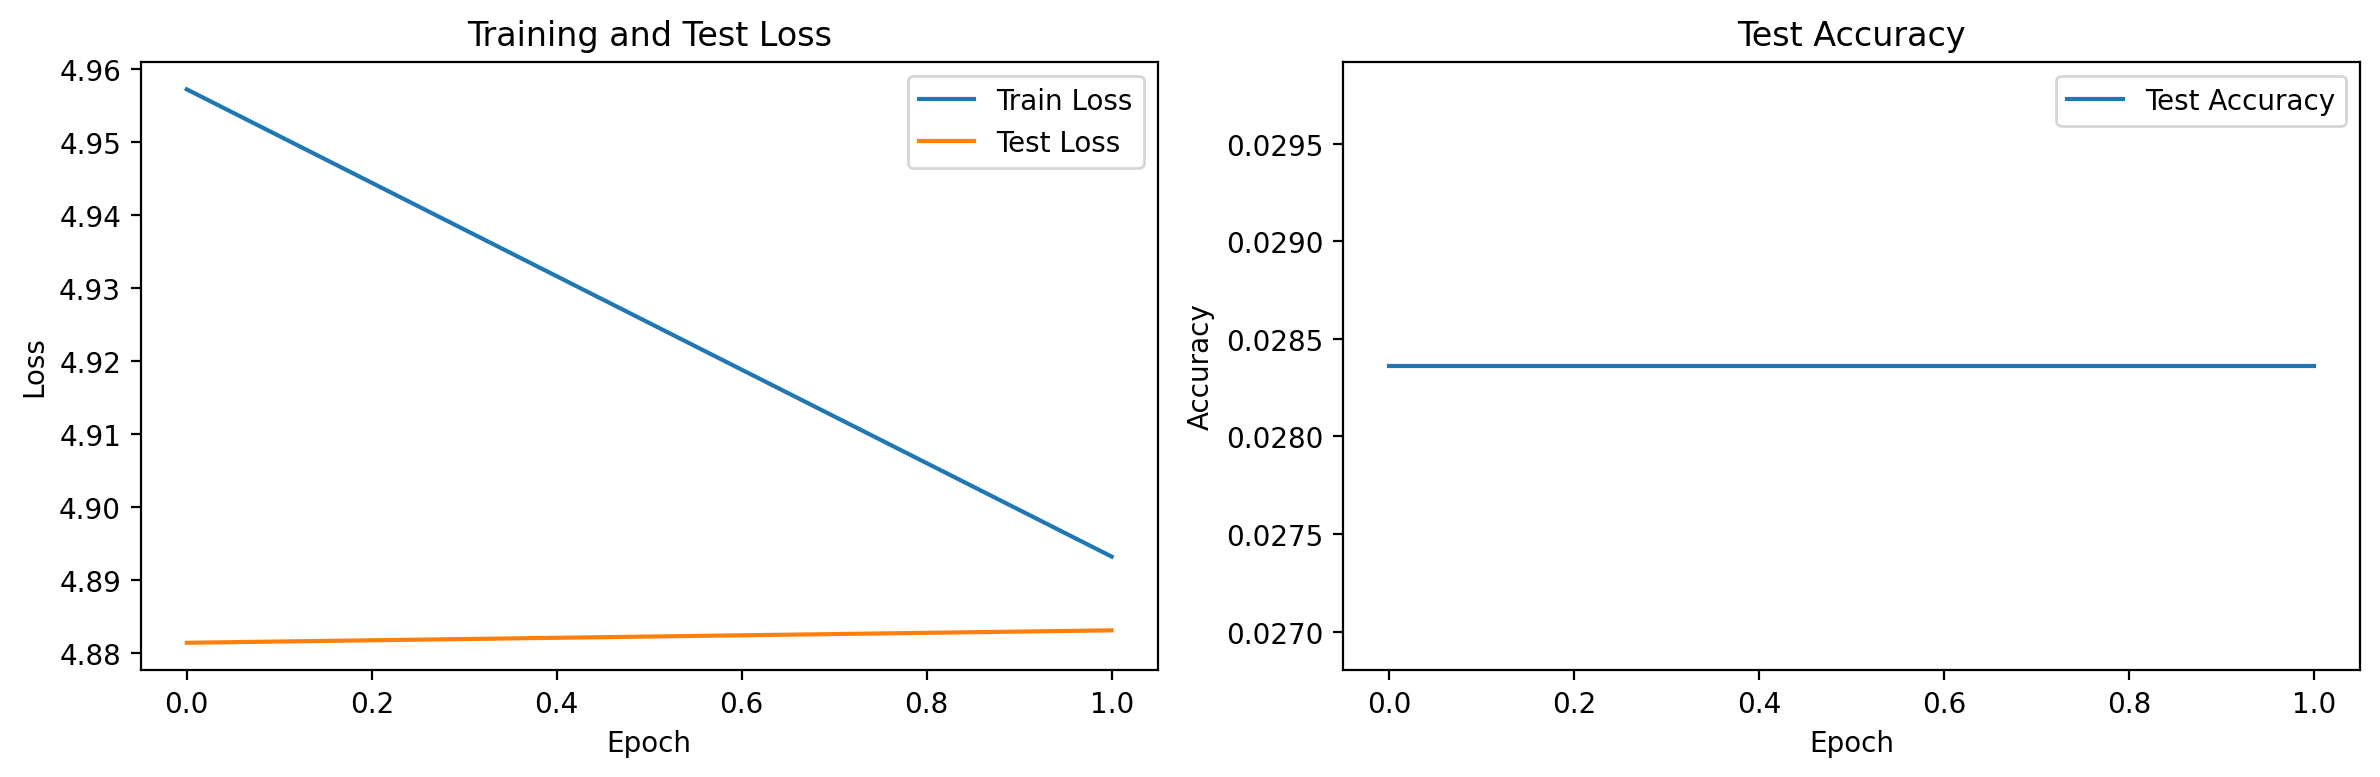

Epoch 2/100, Train Loss: 4.8933, Test Loss: 4.8832, Test Accuracy: 0.0284
Epoch 3/100, Train Loss: 4.8915, Test Loss: 4.8848, Test Accuracy: 0.0284
Epoch 4/100, Train Loss: 4.8910, Test Loss: 4.8803, Test Accuracy: 0.0284
Epoch 5/100, Train Loss: 4.8911, Test Loss: 4.8794, Test Accuracy: 0.0284
Epoch 6/100, Train Loss: 4.8898, Test Loss: 4.8772, Test Accuracy: 0.0284
Epoch 7/100, Train Loss: 4.7435, Test Loss: 4.6720, Test Accuracy: 0.0373
Epoch 8/100, Train Loss: 4.6487, Test Loss: 4.6278, Test Accuracy: 0.0397
Epoch 9/100, Train Loss: 4.6346, Test Loss: 4.6179, Test Accuracy: 0.0337
Epoch 10/100, Train Loss: 4.6205, Test Loss: 4.6092, Test Accuracy: 0.0400
Epoch 11/100, Train Loss: 4.6133, Test Loss: 4.6006, Test Accuracy: 0.0405


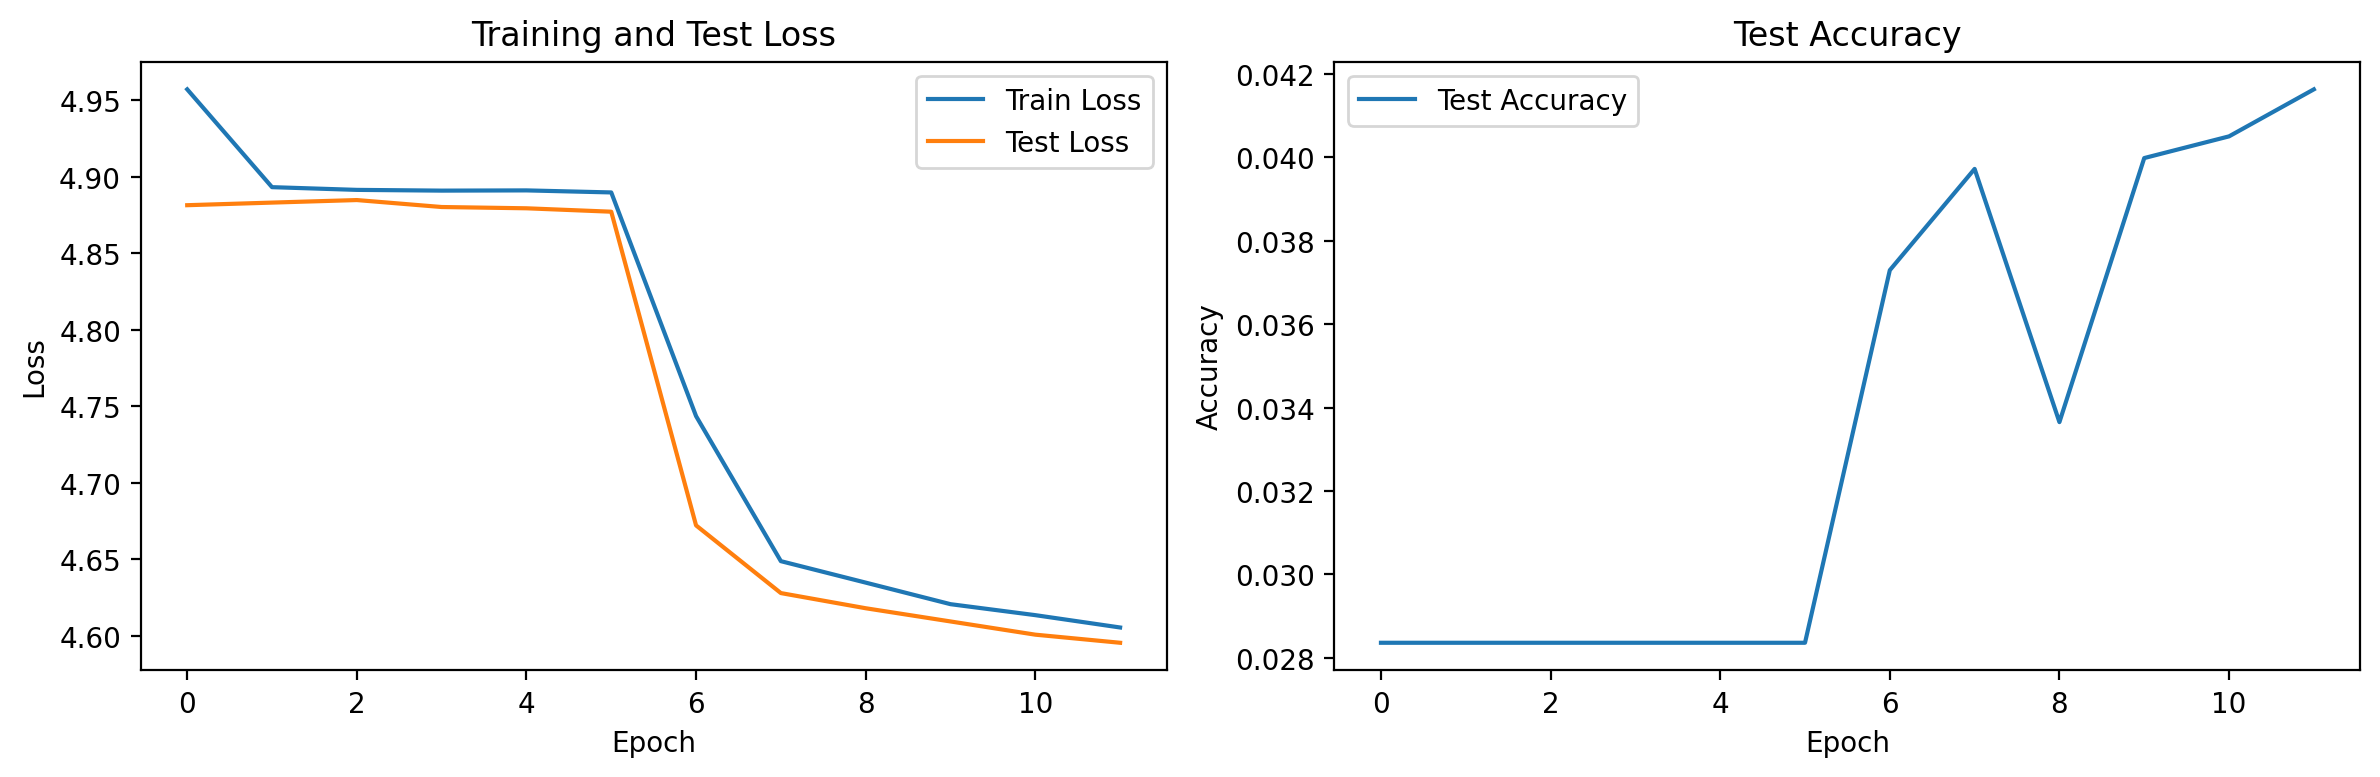

Epoch 12/100, Train Loss: 4.6053, Test Loss: 4.5953, Test Accuracy: 0.0416
Epoch 13/100, Train Loss: 4.5984, Test Loss: 4.5908, Test Accuracy: 0.0401
Epoch 14/100, Train Loss: 4.5885, Test Loss: 4.5854, Test Accuracy: 0.0397
Epoch 15/100, Train Loss: 4.5799, Test Loss: 4.6017, Test Accuracy: 0.0410
Epoch 16/100, Train Loss: 4.5709, Test Loss: 4.5758, Test Accuracy: 0.0408
Epoch 17/100, Train Loss: 4.5592, Test Loss: 4.5710, Test Accuracy: 0.0412
Epoch 18/100, Train Loss: 4.5488, Test Loss: 4.5550, Test Accuracy: 0.0420
Epoch 19/100, Train Loss: 4.5399, Test Loss: 4.5668, Test Accuracy: 0.0396
Epoch 20/100, Train Loss: 4.5305, Test Loss: 4.5486, Test Accuracy: 0.0431
Epoch 21/100, Train Loss: 4.5178, Test Loss: 4.5384, Test Accuracy: 0.0440


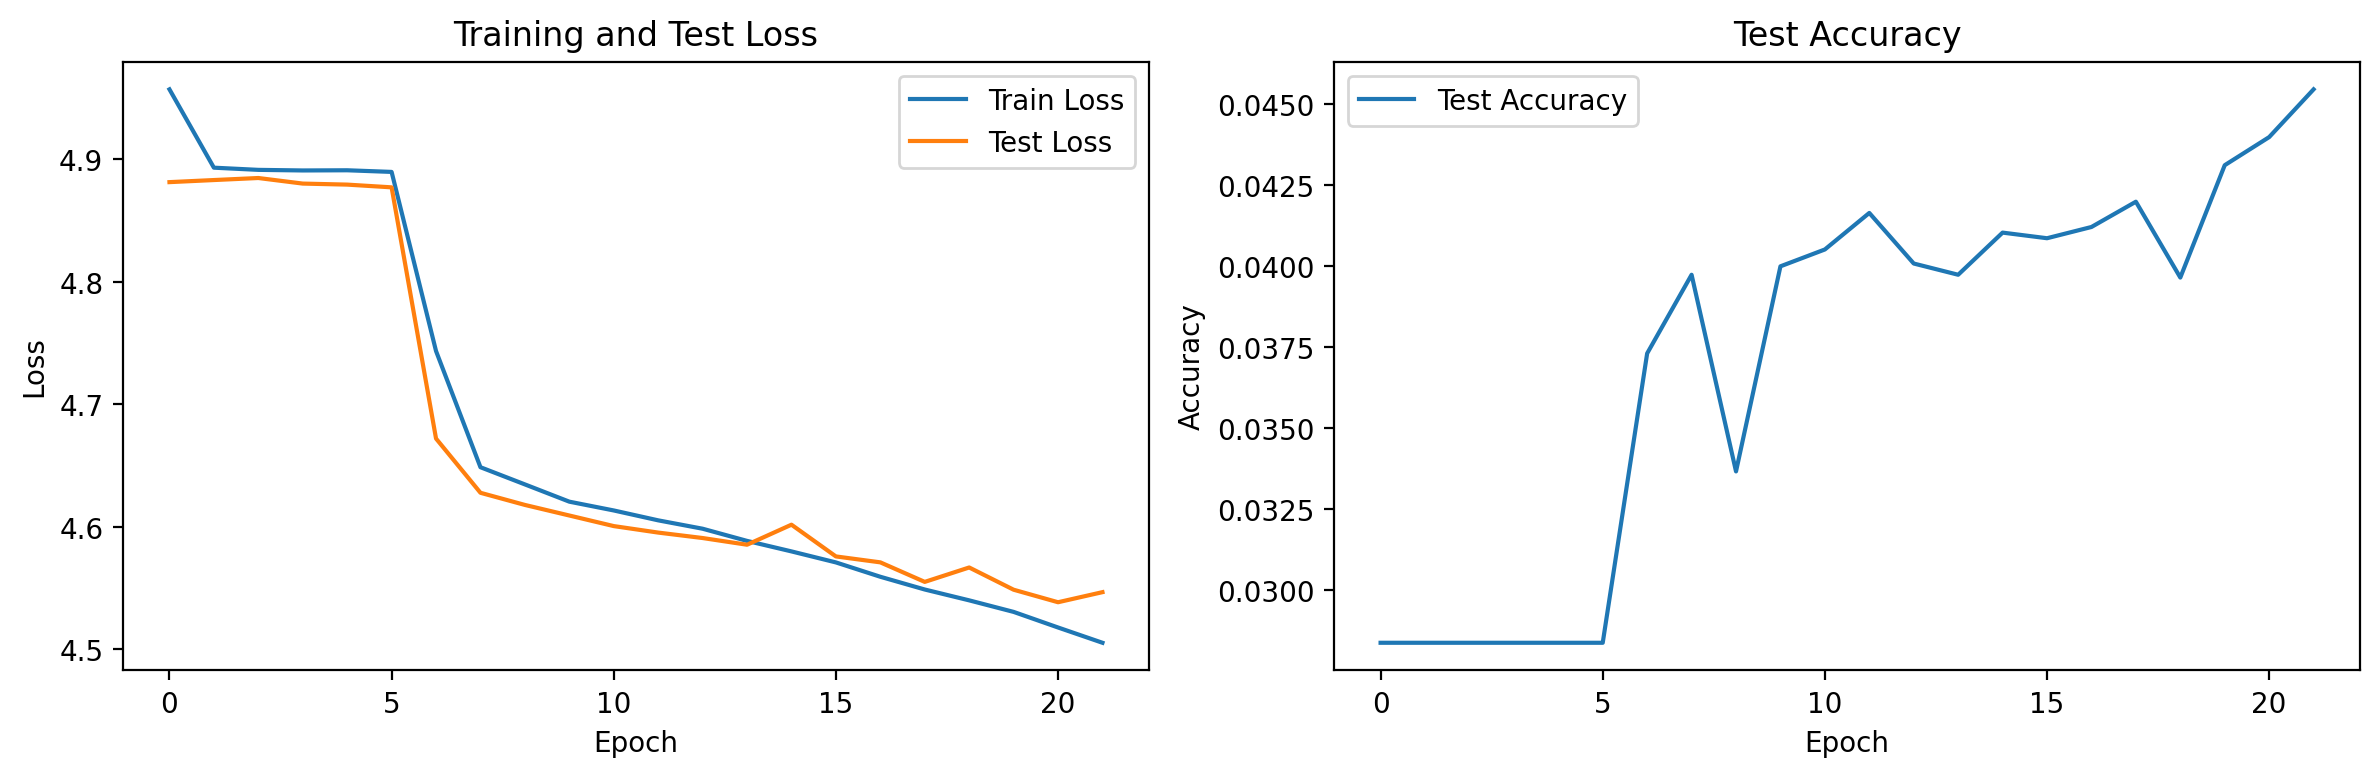

Epoch 22/100, Train Loss: 4.5053, Test Loss: 4.5466, Test Accuracy: 0.0454
Epoch 23/100, Train Loss: 4.4939, Test Loss: 4.5211, Test Accuracy: 0.0448
Epoch 24/100, Train Loss: 4.4849, Test Loss: 4.5295, Test Accuracy: 0.0435
Epoch 25/100, Train Loss: 4.4707, Test Loss: 4.5047, Test Accuracy: 0.0467
Epoch 26/100, Train Loss: 4.4575, Test Loss: 4.4981, Test Accuracy: 0.0489
Epoch 27/100, Train Loss: 4.4459, Test Loss: 4.4910, Test Accuracy: 0.0493
Epoch 28/100, Train Loss: 4.4289, Test Loss: 4.4931, Test Accuracy: 0.0499
Epoch 29/100, Train Loss: 4.4143, Test Loss: 4.4718, Test Accuracy: 0.0526
Epoch 30/100, Train Loss: 4.3998, Test Loss: 4.4686, Test Accuracy: 0.0535
Epoch 31/100, Train Loss: 4.3819, Test Loss: 4.4690, Test Accuracy: 0.0526


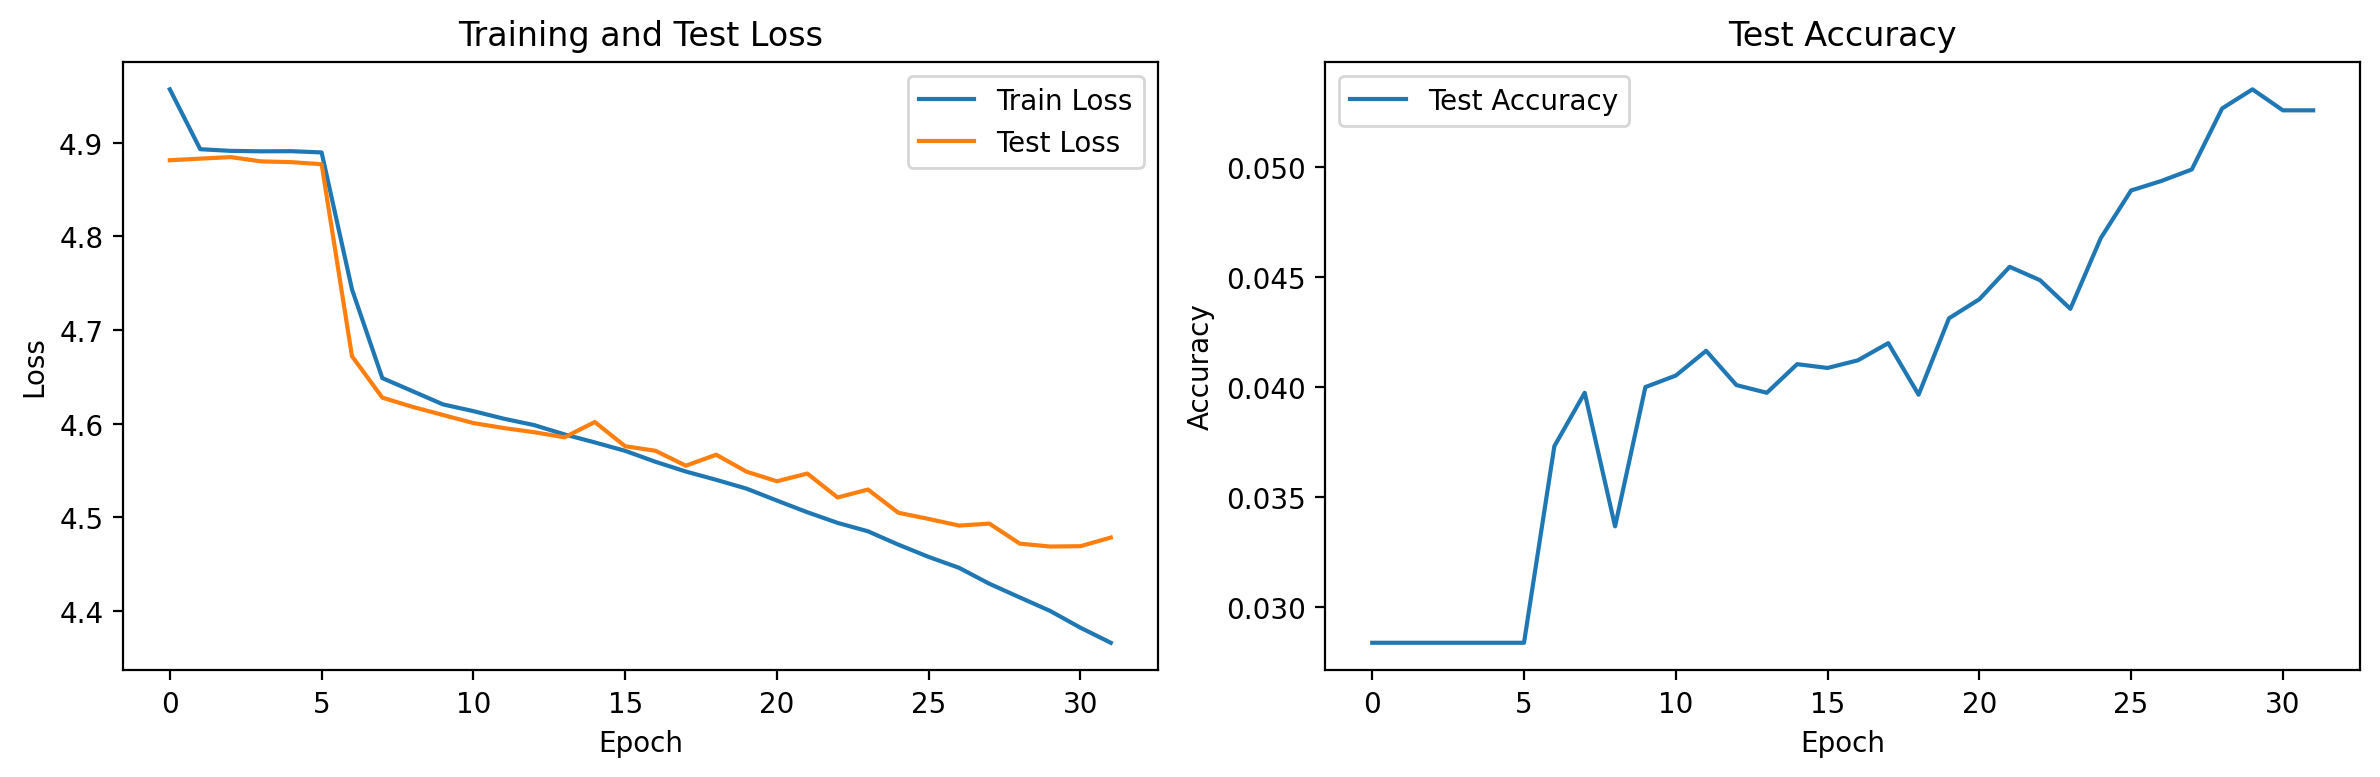

Epoch 32/100, Train Loss: 4.3658, Test Loss: 4.4782, Test Accuracy: 0.0526
Epoch 33/100, Train Loss: 4.3490, Test Loss: 4.4525, Test Accuracy: 0.0536
Epoch 34/100, Train Loss: 4.3278, Test Loss: 4.4320, Test Accuracy: 0.0586
Epoch 35/100, Train Loss: 4.3082, Test Loss: 4.4296, Test Accuracy: 0.0601
Epoch 36/100, Train Loss: 4.2905, Test Loss: 4.4173, Test Accuracy: 0.0638
Epoch 37/100, Train Loss: 4.2661, Test Loss: 4.4021, Test Accuracy: 0.0637
Epoch 38/100, Train Loss: 4.2452, Test Loss: 4.3974, Test Accuracy: 0.0653
Epoch 39/100, Train Loss: 4.2243, Test Loss: 4.3901, Test Accuracy: 0.0663
Epoch 40/100, Train Loss: 4.2014, Test Loss: 4.3764, Test Accuracy: 0.0685
Epoch 41/100, Train Loss: 4.1791, Test Loss: 4.3839, Test Accuracy: 0.0656


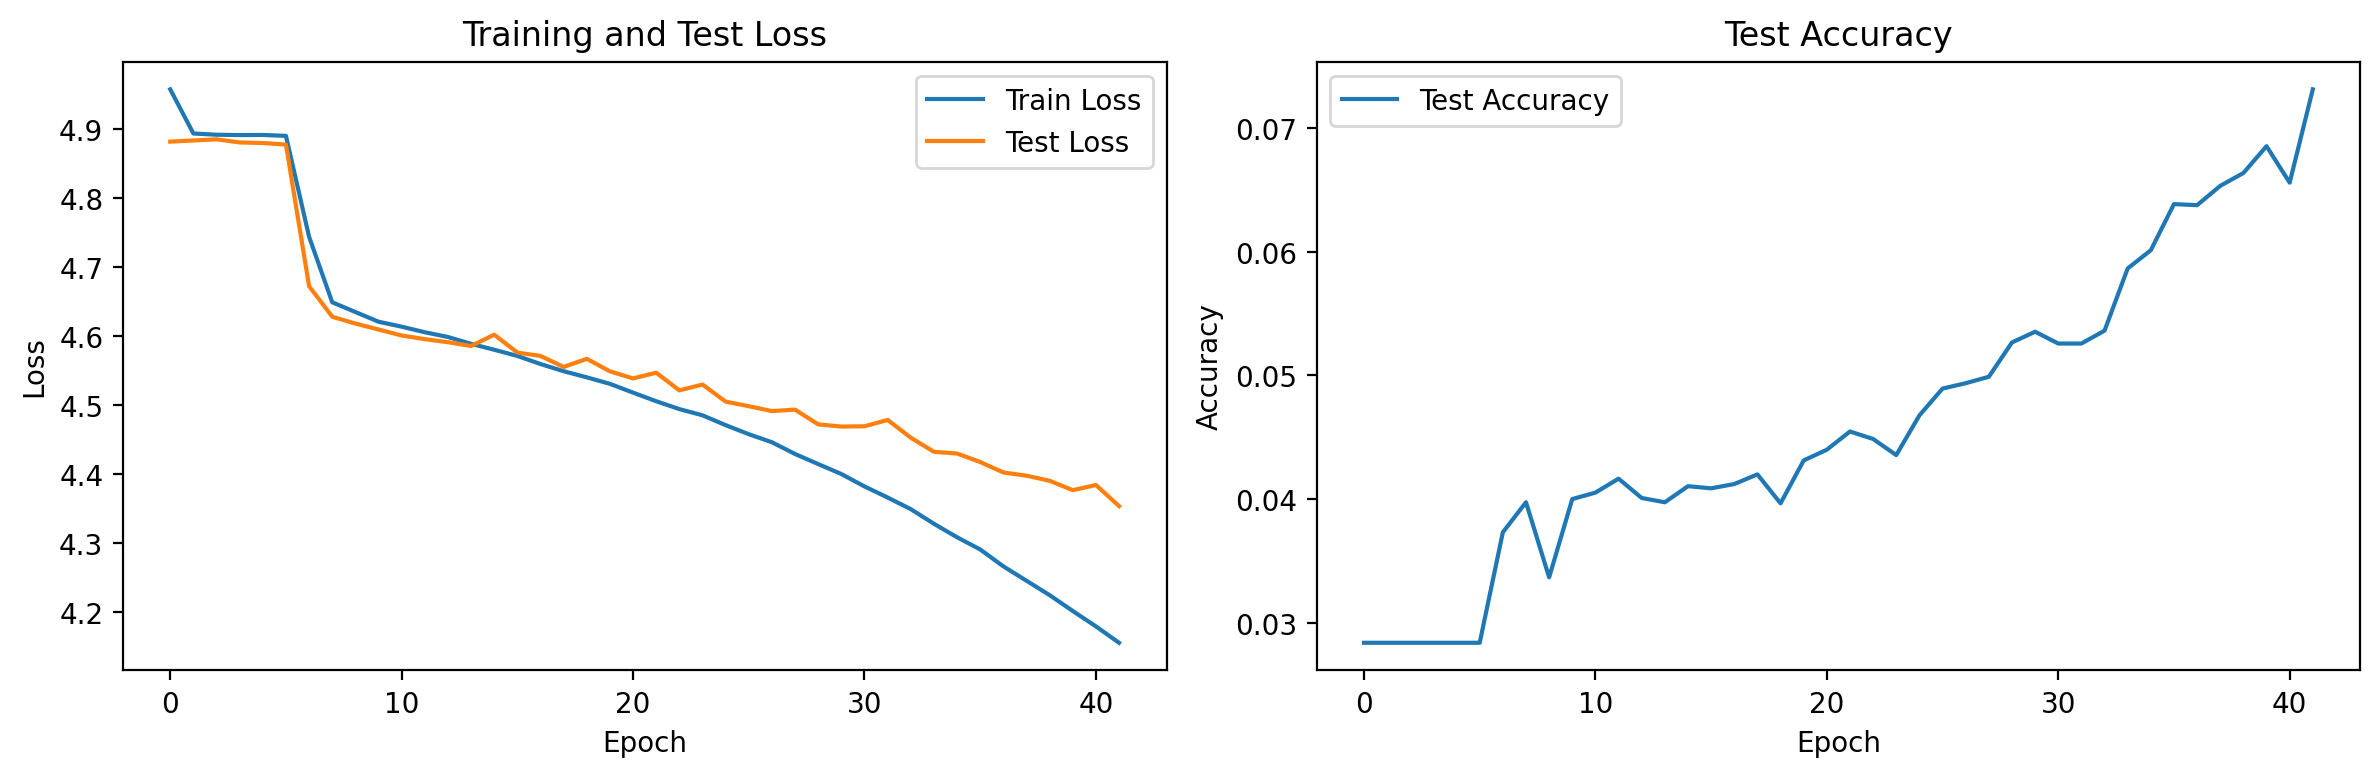

Epoch 42/100, Train Loss: 4.1553, Test Loss: 4.3534, Test Accuracy: 0.0731
Epoch 43/100, Train Loss: 4.1310, Test Loss: 4.3391, Test Accuracy: 0.0742
Epoch 44/100, Train Loss: 4.1062, Test Loss: 4.3331, Test Accuracy: 0.0743
Epoch 45/100, Train Loss: 4.0789, Test Loss: 4.3298, Test Accuracy: 0.0743
Epoch 46/100, Train Loss: 4.0532, Test Loss: 4.3170, Test Accuracy: 0.0801
Epoch 47/100, Train Loss: 4.0284, Test Loss: 4.3037, Test Accuracy: 0.0811
Epoch 48/100, Train Loss: 4.0007, Test Loss: 4.2991, Test Accuracy: 0.0833
Epoch 49/100, Train Loss: 3.9768, Test Loss: 4.2911, Test Accuracy: 0.0808
Epoch 50/100, Train Loss: 3.9507, Test Loss: 4.2854, Test Accuracy: 0.0854
Epoch 51/100, Train Loss: 3.9185, Test Loss: 4.2723, Test Accuracy: 0.0854


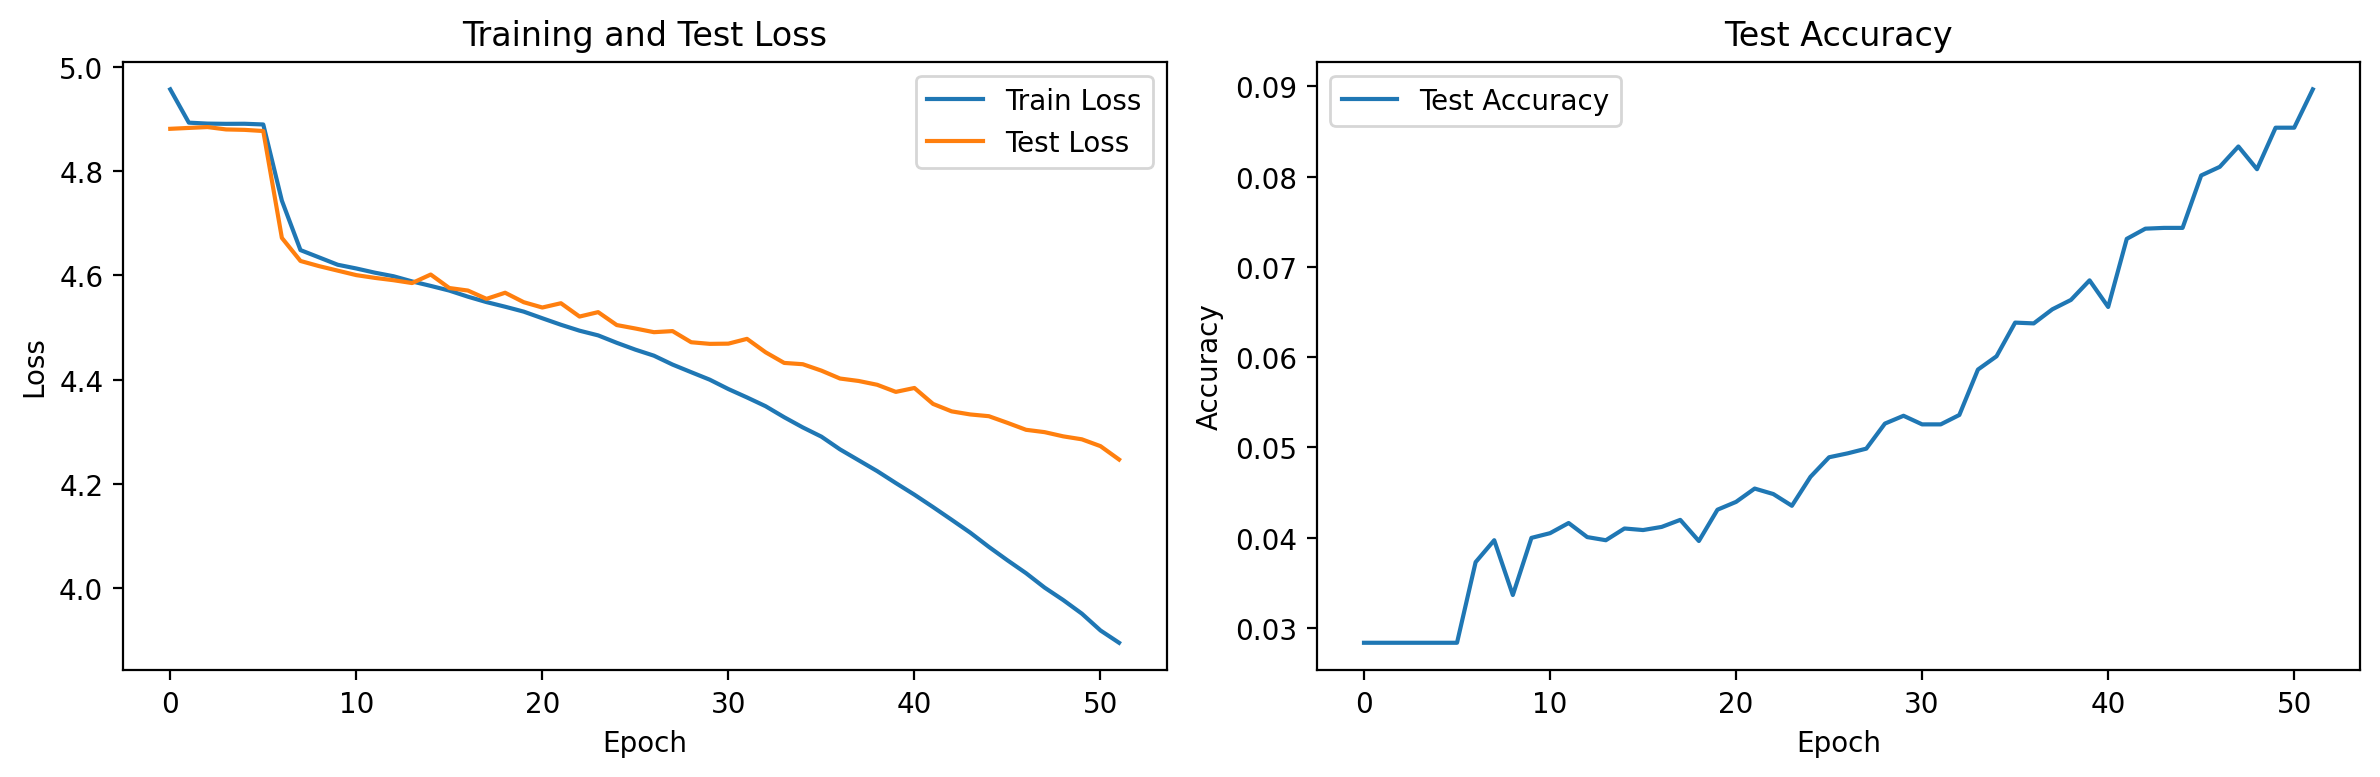

Epoch 52/100, Train Loss: 3.8948, Test Loss: 4.2466, Test Accuracy: 0.0897
Epoch 53/100, Train Loss: 3.8688, Test Loss: 4.2400, Test Accuracy: 0.0903
Epoch 54/100, Train Loss: 3.8412, Test Loss: 4.2347, Test Accuracy: 0.0921
Epoch 55/100, Train Loss: 3.8143, Test Loss: 4.2332, Test Accuracy: 0.0918
Epoch 56/100, Train Loss: 3.7843, Test Loss: 4.2378, Test Accuracy: 0.0927
Epoch 57/100, Train Loss: 3.7610, Test Loss: 4.2063, Test Accuracy: 0.0974
Epoch 58/100, Train Loss: 3.7332, Test Loss: 4.2146, Test Accuracy: 0.0984
Epoch 59/100, Train Loss: 3.7078, Test Loss: 4.2142, Test Accuracy: 0.0993
Epoch 60/100, Train Loss: 3.6804, Test Loss: 4.1838, Test Accuracy: 0.1023
Epoch 61/100, Train Loss: 3.6590, Test Loss: 4.1858, Test Accuracy: 0.1025


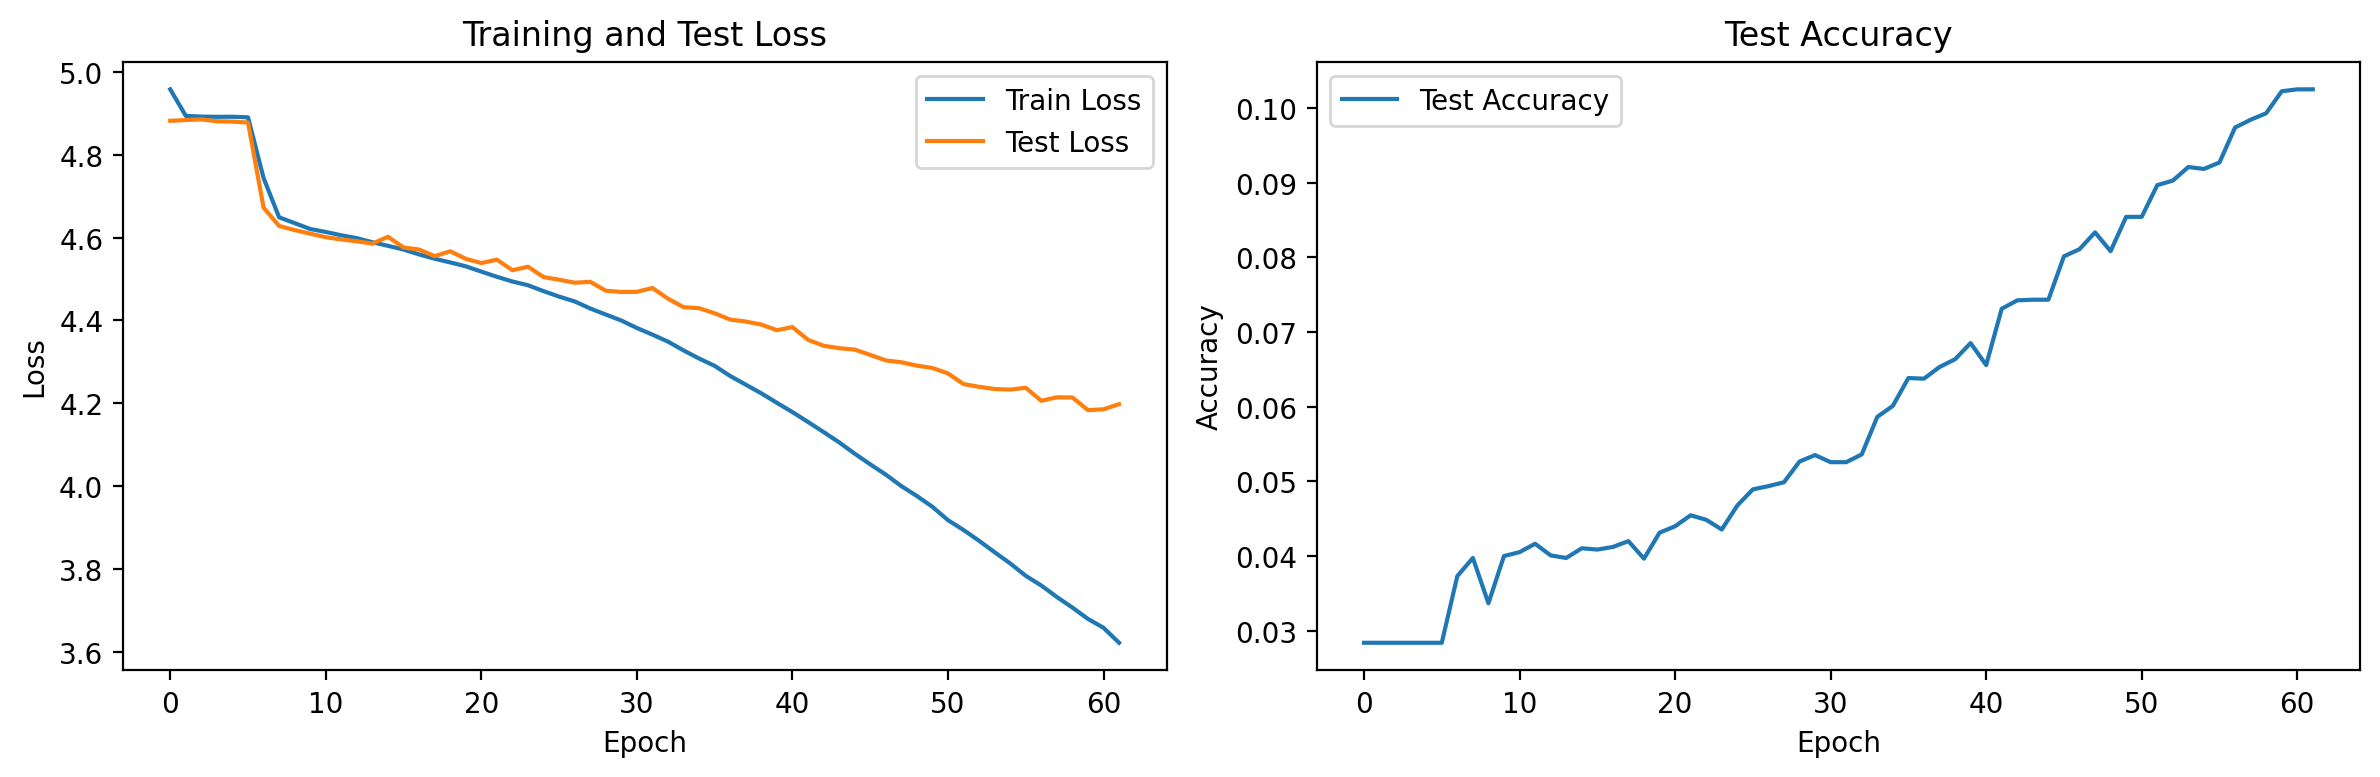

Epoch 62/100, Train Loss: 3.6229, Test Loss: 4.1981, Test Accuracy: 0.1025
Epoch 63/100, Train Loss: 3.5896, Test Loss: 4.1699, Test Accuracy: 0.1078
Epoch 64/100, Train Loss: 3.5634, Test Loss: 4.1742, Test Accuracy: 0.1095
Epoch 65/100, Train Loss: 3.5393, Test Loss: 4.1712, Test Accuracy: 0.1121
Epoch 66/100, Train Loss: 3.5068, Test Loss: 4.1477, Test Accuracy: 0.1127
Epoch 67/100, Train Loss: 3.4790, Test Loss: 4.1592, Test Accuracy: 0.1129
Epoch 68/100, Train Loss: 3.4502, Test Loss: 4.1427, Test Accuracy: 0.1134
Epoch 69/100, Train Loss: 3.4213, Test Loss: 4.1354, Test Accuracy: 0.1180
Epoch 70/100, Train Loss: 3.3981, Test Loss: 4.1487, Test Accuracy: 0.1180
Epoch 71/100, Train Loss: 3.3658, Test Loss: 4.1359, Test Accuracy: 0.1198


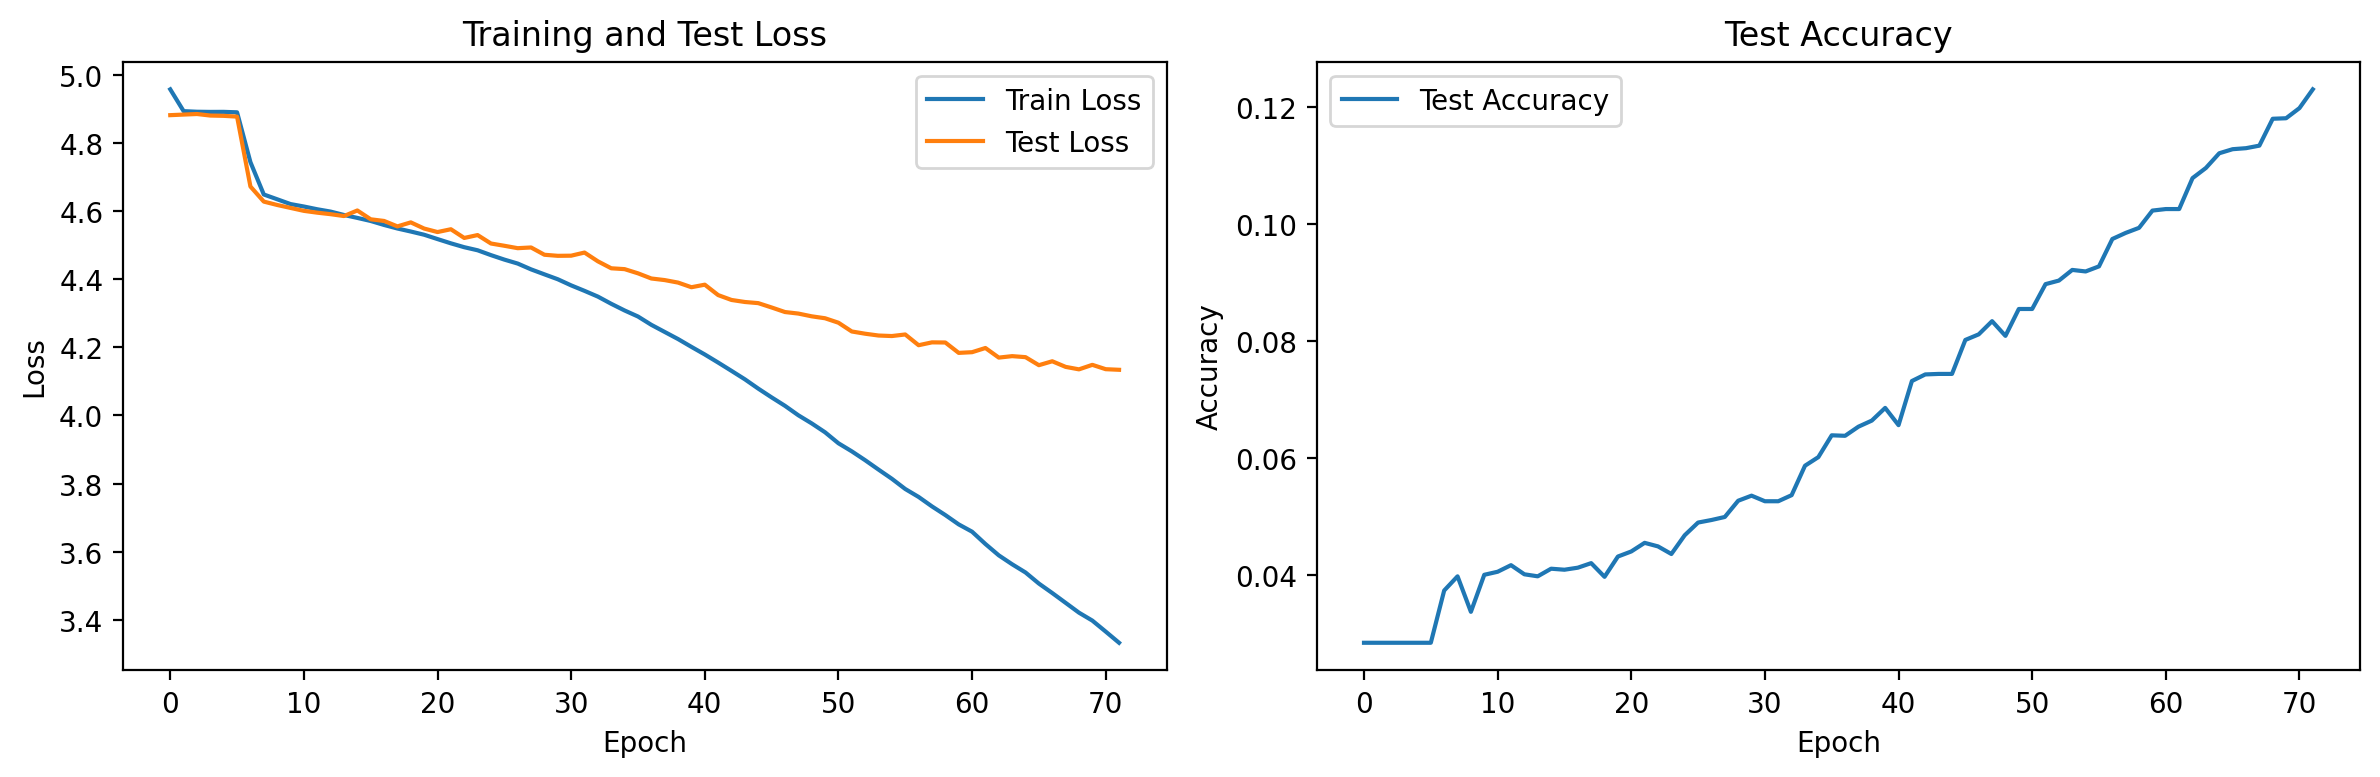

Epoch 72/100, Train Loss: 3.3330, Test Loss: 4.1341, Test Accuracy: 0.1230
Epoch 73/100, Train Loss: 3.3097, Test Loss: 4.1182, Test Accuracy: 0.1250
Epoch 74/100, Train Loss: 3.2758, Test Loss: 4.1235, Test Accuracy: 0.1277
Epoch 75/100, Train Loss: 3.2463, Test Loss: 4.1231, Test Accuracy: 0.1309
Epoch 76/100, Train Loss: 3.2181, Test Loss: 4.1240, Test Accuracy: 0.1286
Epoch 77/100, Train Loss: 3.1879, Test Loss: 4.1033, Test Accuracy: 0.1339
Epoch 78/100, Train Loss: 3.1608, Test Loss: 4.1254, Test Accuracy: 0.1297
Epoch 79/100, Train Loss: 3.1329, Test Loss: 4.1231, Test Accuracy: 0.1373
Epoch 80/100, Train Loss: 3.0933, Test Loss: 4.1095, Test Accuracy: 0.1351
Epoch 81/100, Train Loss: 3.0639, Test Loss: 4.1159, Test Accuracy: 0.1379


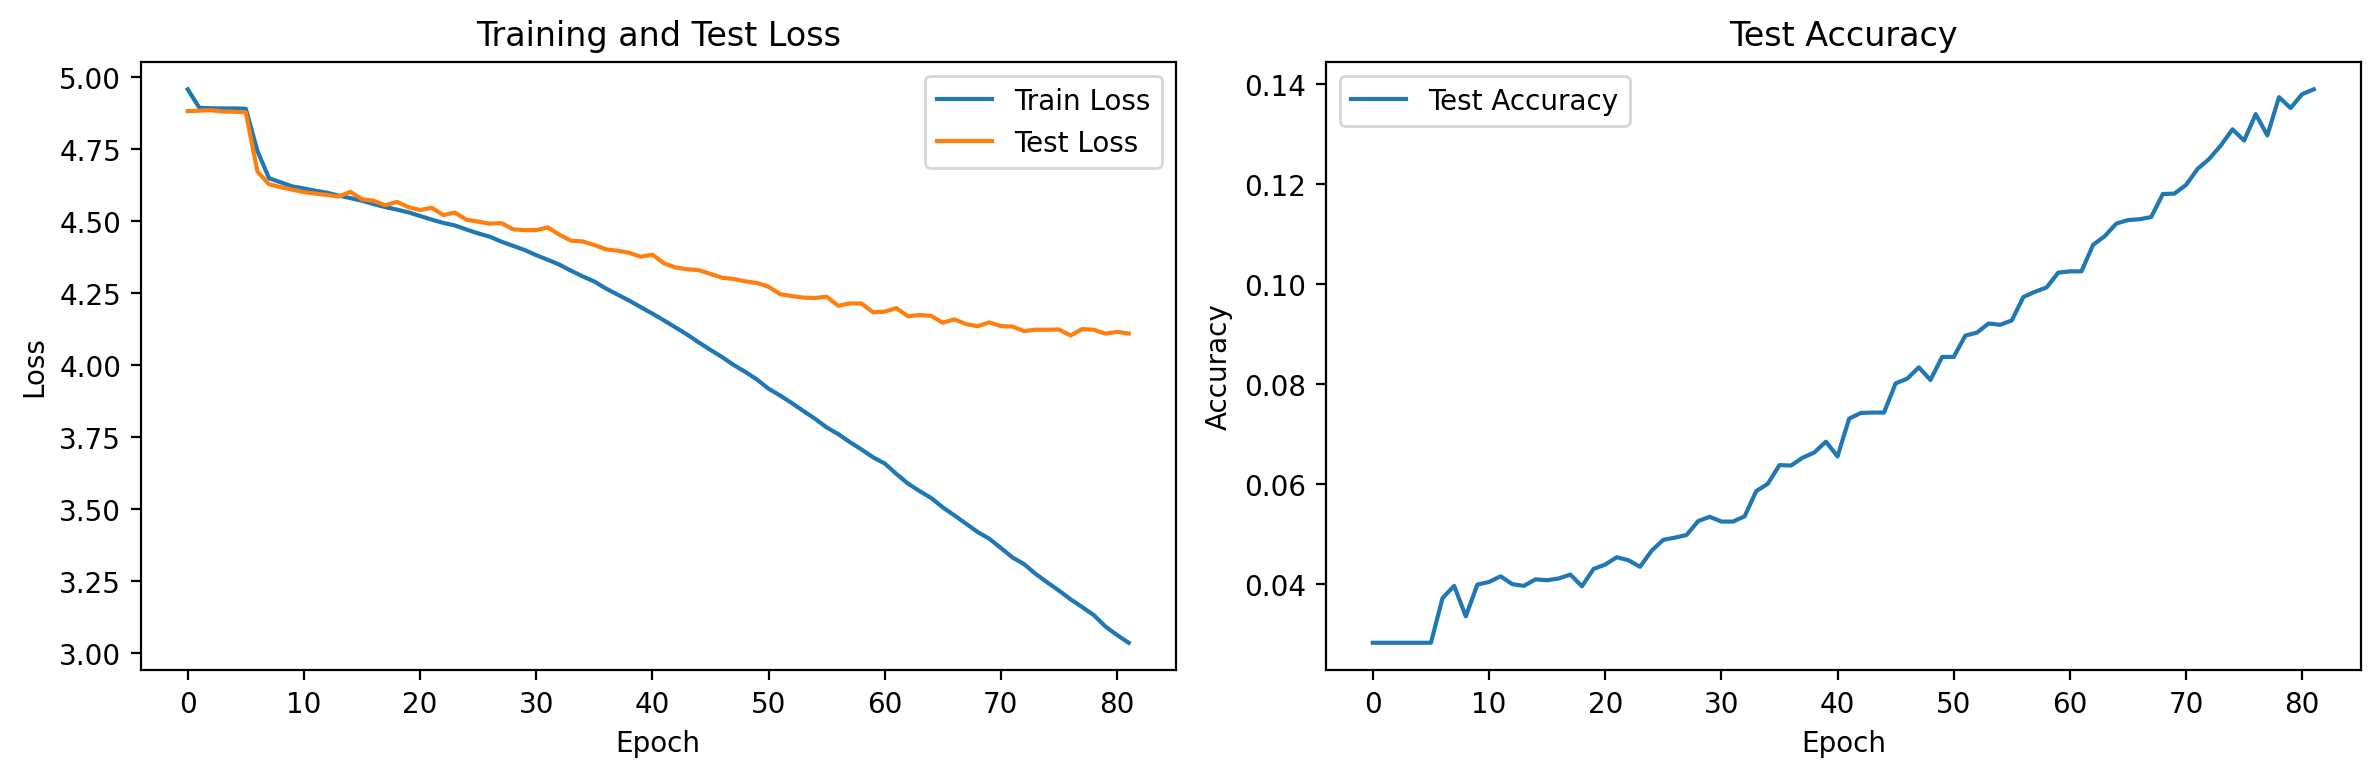

Epoch 82/100, Train Loss: 3.0371, Test Loss: 4.1099, Test Accuracy: 0.1389
Epoch 83/100, Train Loss: 3.0064, Test Loss: 4.1085, Test Accuracy: 0.1407
Epoch 84/100, Train Loss: 2.9739, Test Loss: 4.1039, Test Accuracy: 0.1419
Epoch 85/100, Train Loss: 2.9492, Test Loss: 4.1398, Test Accuracy: 0.1415
Epoch 86/100, Train Loss: 2.9146, Test Loss: 4.0970, Test Accuracy: 0.1462
Epoch 87/100, Train Loss: 2.8852, Test Loss: 4.1149, Test Accuracy: 0.1467
Epoch 88/100, Train Loss: 2.8555, Test Loss: 4.1410, Test Accuracy: 0.1410
Epoch 89/100, Train Loss: 2.8250, Test Loss: 4.1111, Test Accuracy: 0.1508
Epoch 90/100, Train Loss: 2.7923, Test Loss: 4.1146, Test Accuracy: 0.1522
Epoch 91/100, Train Loss: 2.7650, Test Loss: 4.1180, Test Accuracy: 0.1545


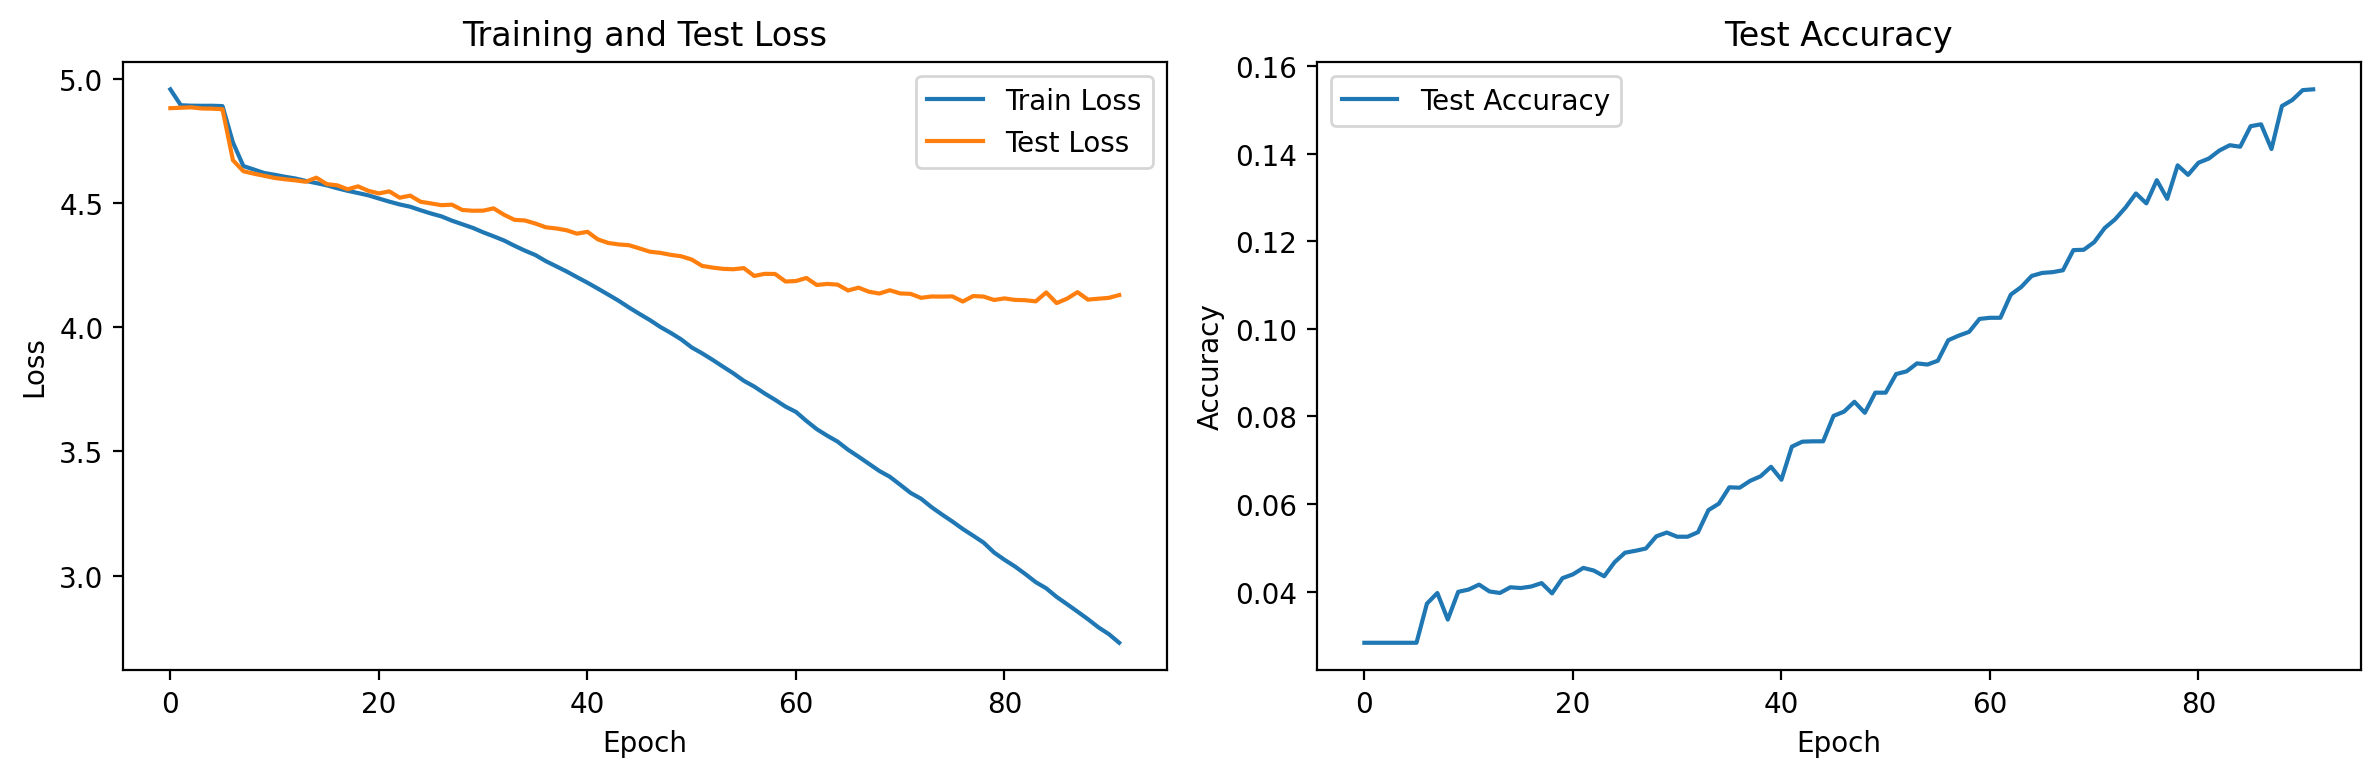

Epoch 92/100, Train Loss: 2.7300, Test Loss: 4.1293, Test Accuracy: 0.1546
Epoch 93/100, Train Loss: 2.7028, Test Loss: 4.1361, Test Accuracy: 0.1538
Epoch 94/100, Train Loss: 2.6722, Test Loss: 4.1332, Test Accuracy: 0.1582
Epoch 95/100, Train Loss: 2.6454, Test Loss: 4.1671, Test Accuracy: 0.1492
Epoch 96/100, Train Loss: 2.6076, Test Loss: 4.1355, Test Accuracy: 0.1625
Epoch 97/100, Train Loss: 2.5750, Test Loss: 4.1426, Test Accuracy: 0.1597
Epoch 98/100, Train Loss: 2.5503, Test Loss: 4.1431, Test Accuracy: 0.1626
Epoch 99/100, Train Loss: 2.5158, Test Loss: 4.1797, Test Accuracy: 0.1605
Epoch 100/100, Train Loss: 2.4878, Test Loss: 4.1656, Test Accuracy: 0.1709


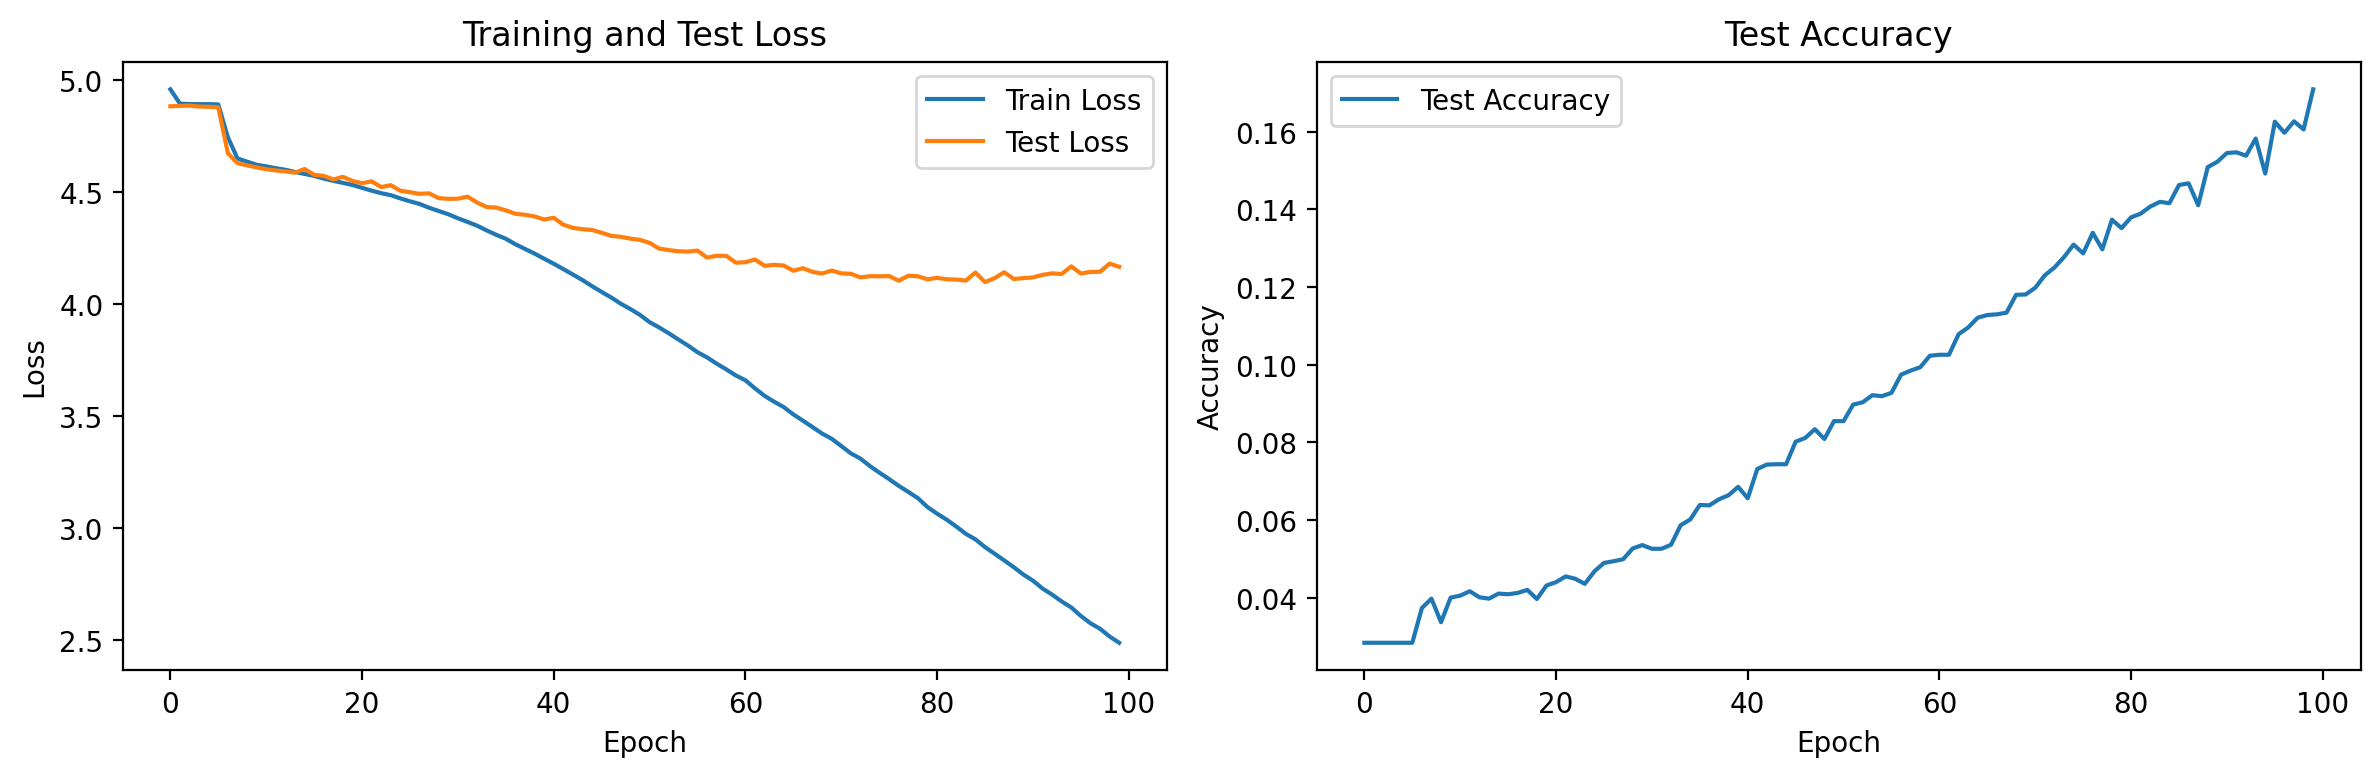

Model saved as 'music_generator_model.pth'
Generating sample music...
Sample of generated notes:
['0', '6', '10', '8', 'E-3', '0.4.7', '3', '7.0', '0', '0']
Generated music saved to 'generated_music.txt'


In [ ]:

# Fix nn.LSTM to support return_sequences parameter
# fix_lstm_module()


# Split data into train and test sets
train_loader, test_loader = pretrain_dataset(
    network_input,
    network_output,
    test_size=0.2,
    batch_size=64
)

# Get parameters
sequence_length = network_input.shape[1]
n_vocab = network_output.shape[1]

# Initialize model with architecture from the image
model = MusicLSTM(
    input_size=1,       # Single feature (note index)
    output_size=n_vocab # Size of output (vocabulary size)
)

# Print model summary to confirm architecture
print("Model Architecture:")
print(model)

# Calculate total parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

# Choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Choose loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Train model
print("Starting training...")
model, history = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    num_epochs=100,
    device=device
)

# Plot training history
plot_training_history(history)

# Save model
torch.save(model.state_dict(), 'music_generator_model.pth')
print("Model saved as 'music_generator_model.pth'")

# Generate sample music
print("Generating sample music...")
# Get a random seed sequence from the test set
seed_sequence = network_input[0]
seed_sequence = seed_sequence.reshape((sequence_length, 1))

generated_notes = generate_music(
    model,
    seed_sequence,
    int_to_note,
    sequence_length,
    n_vocab,
    num_notes=100
)

print("Sample of generated notes:")
print(generated_notes[:10])

# Save generated notes to a file
with open('generated_music.txt', 'w') as f:
    for note in generated_notes:
        f.write(f"{note}\n")


print("Generated music saved to 'generated_music.txt'")

# return model, history, generated_notes


Epoch 1/100, Train Loss: 2.4525, Test Loss: 4.1839, Test Accuracy: 0.1641


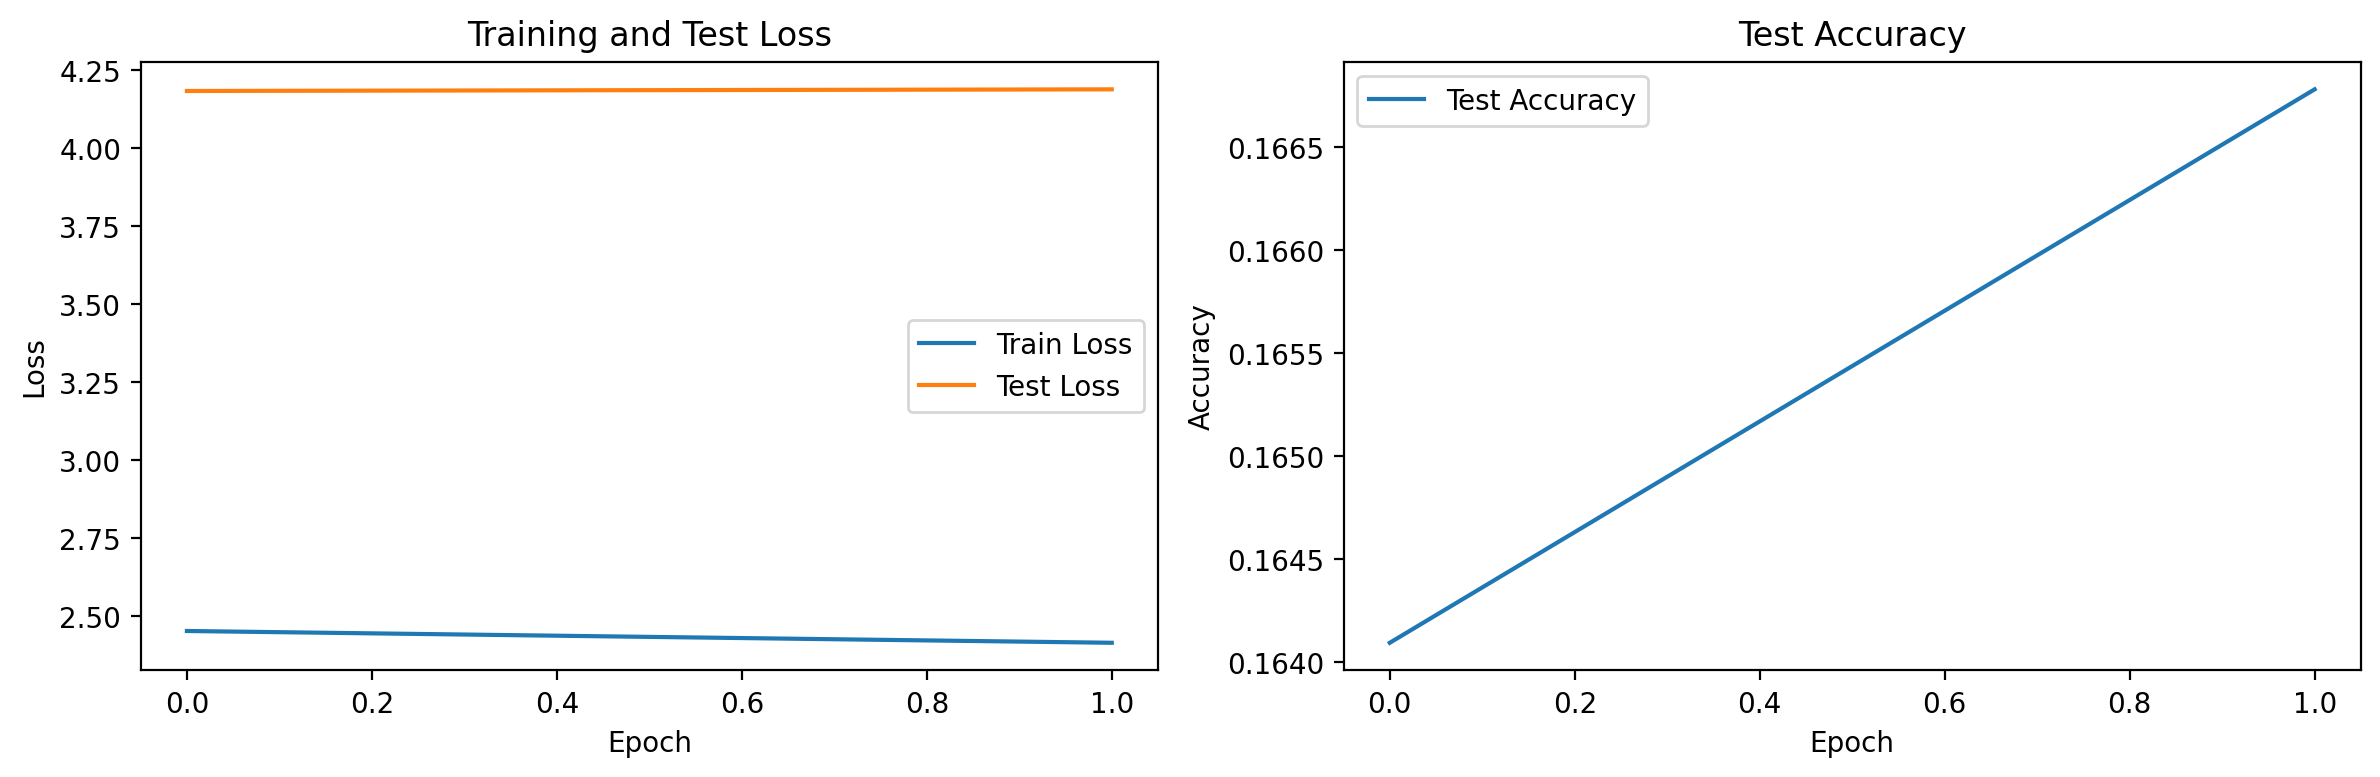

Epoch 2/100, Train Loss: 2.4148, Test Loss: 4.1892, Test Accuracy: 0.1668
Epoch 3/100, Train Loss: 2.3870, Test Loss: 4.1681, Test Accuracy: 0.1756
Epoch 4/100, Train Loss: 2.3590, Test Loss: 4.1966, Test Accuracy: 0.1735
Epoch 5/100, Train Loss: 2.3247, Test Loss: 4.1813, Test Accuracy: 0.1765
Epoch 6/100, Train Loss: 2.2991, Test Loss: 4.2107, Test Accuracy: 0.1749
Epoch 7/100, Train Loss: 2.2638, Test Loss: 4.2987, Test Accuracy: 0.1642
Epoch 8/100, Train Loss: 2.2320, Test Loss: 4.2222, Test Accuracy: 0.1790
Epoch 9/100, Train Loss: 2.2010, Test Loss: 4.2503, Test Accuracy: 0.1814
Epoch 10/100, Train Loss: 2.1648, Test Loss: 4.2460, Test Accuracy: 0.1814
Epoch 11/100, Train Loss: 2.1307, Test Loss: 4.2599, Test Accuracy: 0.1822


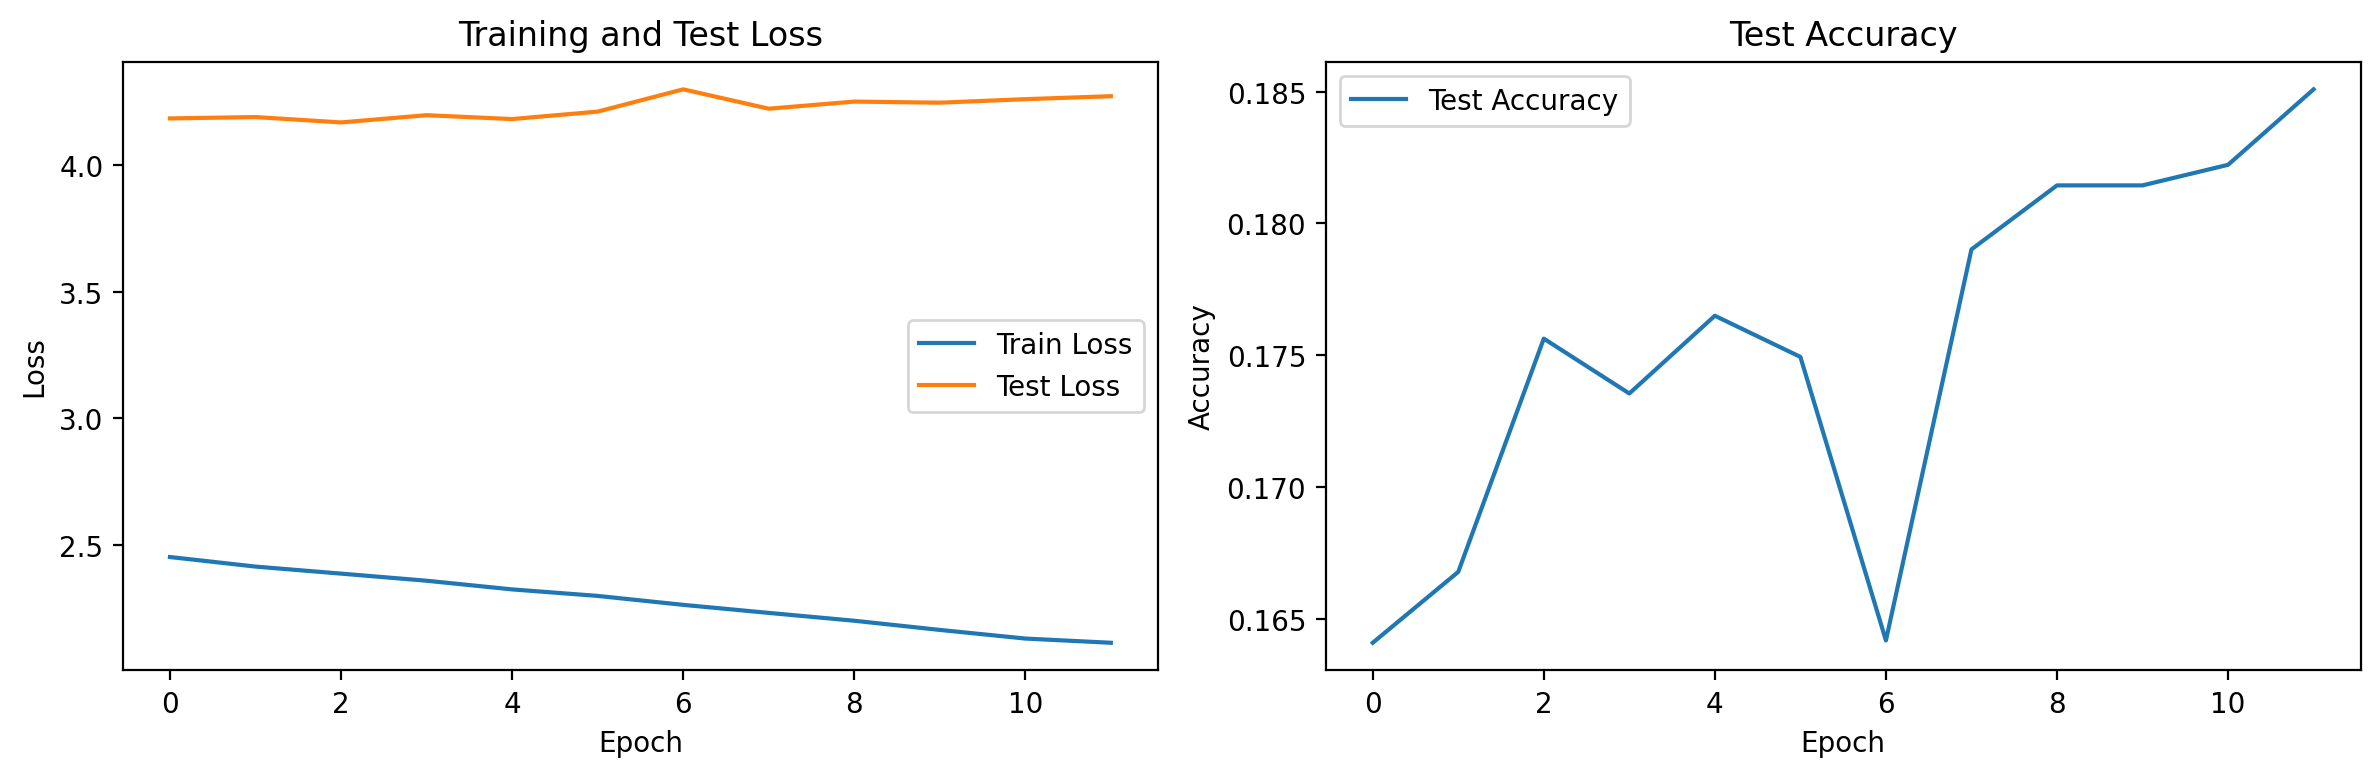

Epoch 12/100, Train Loss: 2.1141, Test Loss: 4.2716, Test Accuracy: 0.1851
Epoch 13/100, Train Loss: 2.0780, Test Loss: 4.2873, Test Accuracy: 0.1848
Epoch 14/100, Train Loss: 2.0456, Test Loss: 4.2863, Test Accuracy: 0.1856
Epoch 15/100, Train Loss: 2.0093, Test Loss: 4.3032, Test Accuracy: 0.1892
Epoch 16/100, Train Loss: 1.9840, Test Loss: 4.3229, Test Accuracy: 0.1885
Epoch 17/100, Train Loss: 1.9476, Test Loss: 4.3191, Test Accuracy: 0.1944
Epoch 18/100, Train Loss: 1.9220, Test Loss: 4.3514, Test Accuracy: 0.1915
Epoch 19/100, Train Loss: 1.8899, Test Loss: 4.3642, Test Accuracy: 0.1962
Epoch 20/100, Train Loss: 1.8603, Test Loss: 4.3939, Test Accuracy: 0.1991
Epoch 21/100, Train Loss: 1.8280, Test Loss: 4.4081, Test Accuracy: 0.1955


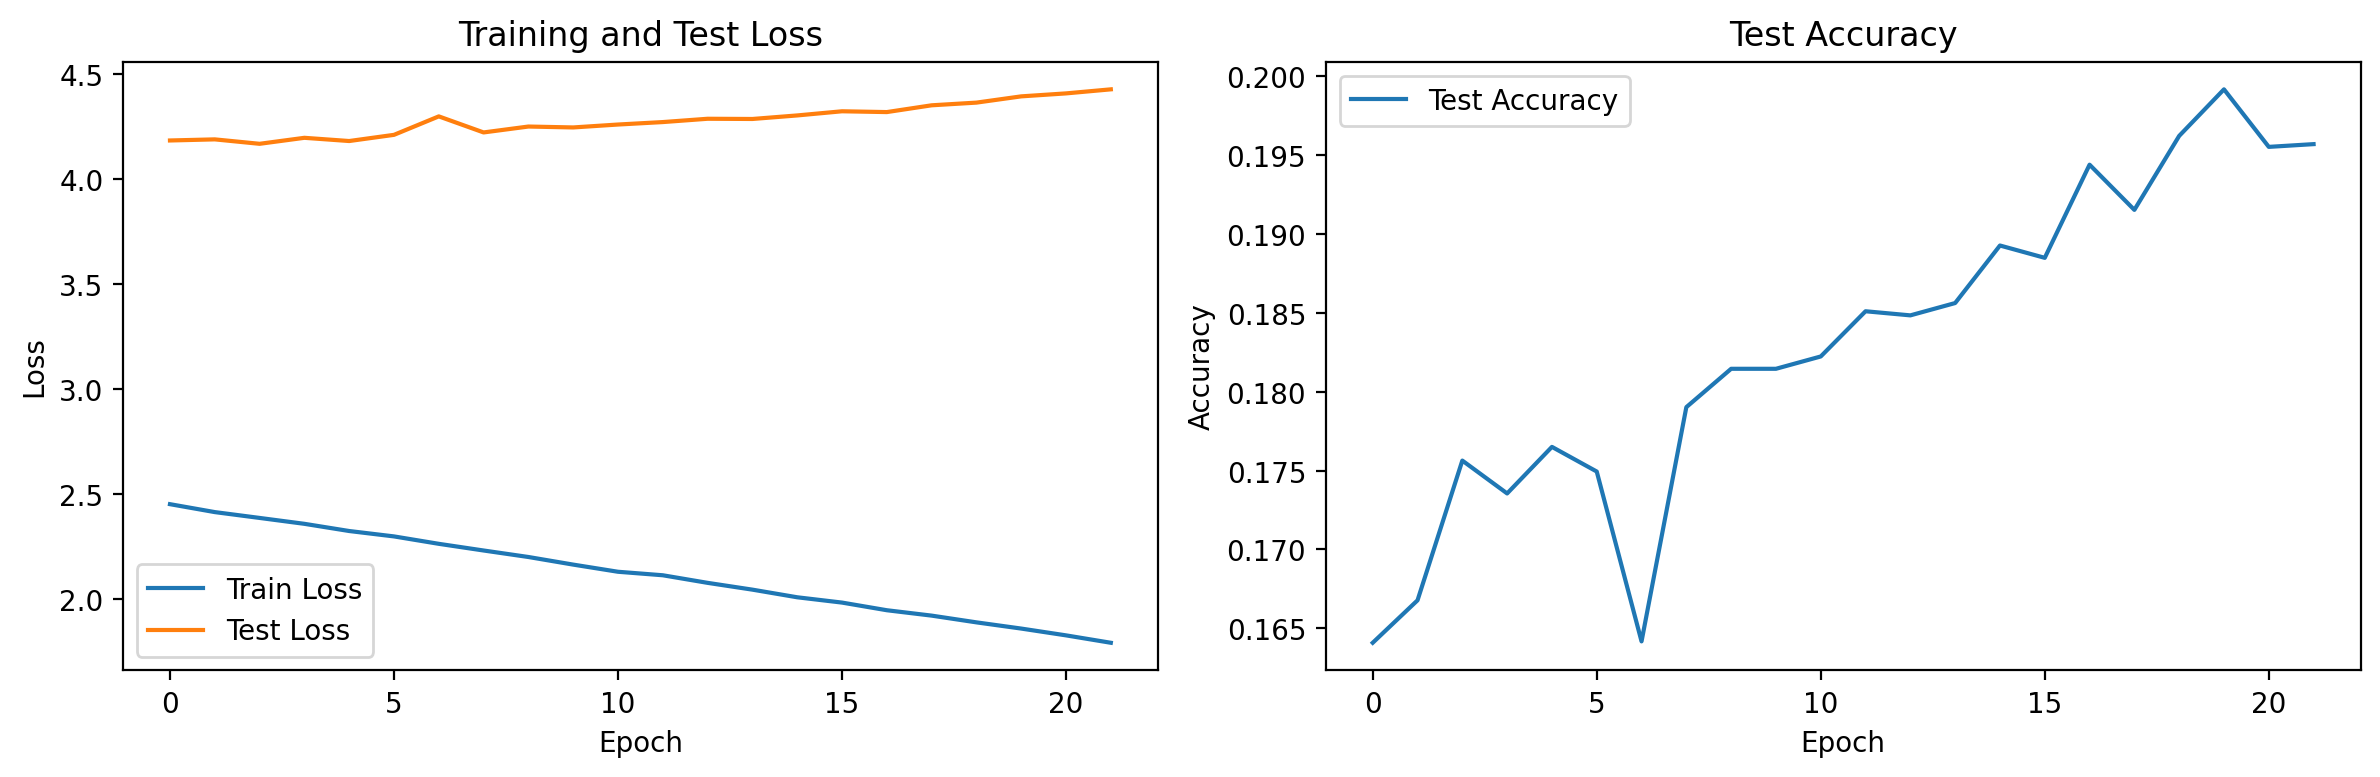

Epoch 22/100, Train Loss: 1.7927, Test Loss: 4.4274, Test Accuracy: 0.1957
Epoch 23/100, Train Loss: 1.7674, Test Loss: 4.4361, Test Accuracy: 0.1990
Epoch 24/100, Train Loss: 1.7333, Test Loss: 4.4433, Test Accuracy: 0.1990
Epoch 25/100, Train Loss: 1.7158, Test Loss: 4.4917, Test Accuracy: 0.1992
Epoch 26/100, Train Loss: 1.6817, Test Loss: 4.4654, Test Accuracy: 0.2017
Epoch 27/100, Train Loss: 1.6423, Test Loss: 4.4844, Test Accuracy: 0.1991
Epoch 28/100, Train Loss: 1.6197, Test Loss: 4.5382, Test Accuracy: 0.2060
Epoch 29/100, Train Loss: 1.5899, Test Loss: 4.5529, Test Accuracy: 0.2057
Epoch 30/100, Train Loss: 1.5483, Test Loss: 4.5751, Test Accuracy: 0.2085
Epoch 31/100, Train Loss: 1.5229, Test Loss: 4.5769, Test Accuracy: 0.2123


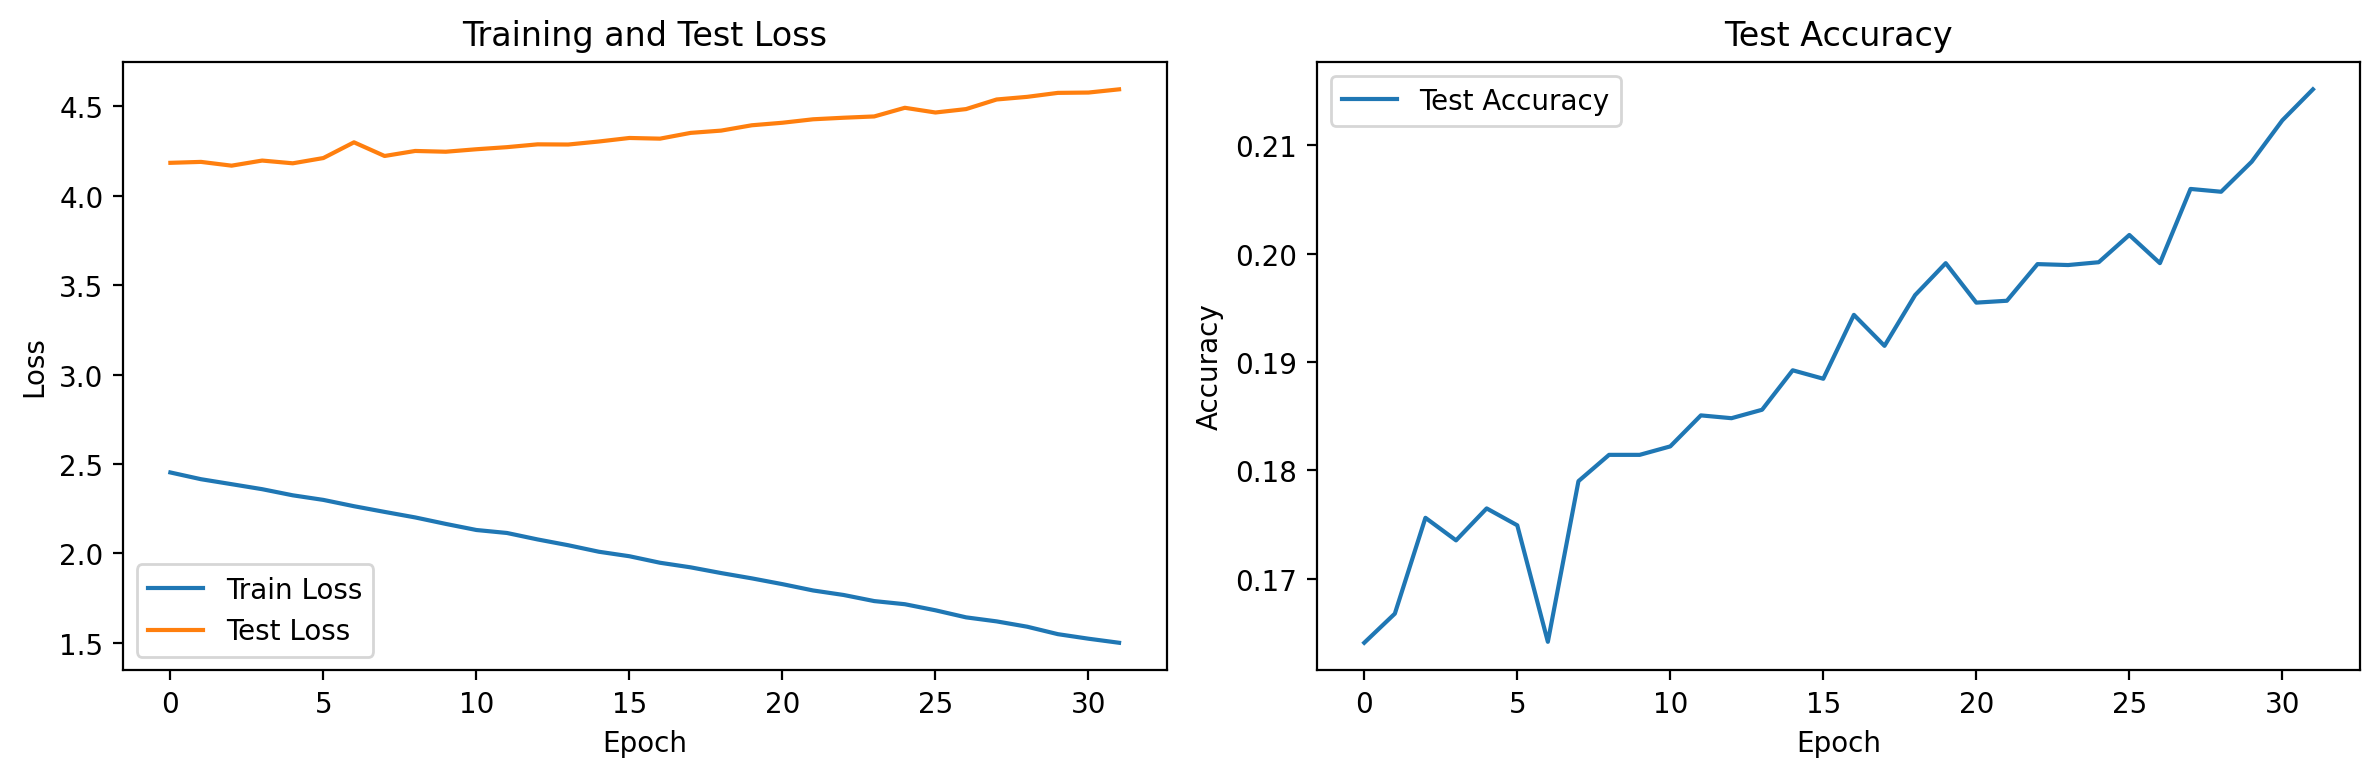

Epoch 32/100, Train Loss: 1.5001, Test Loss: 4.5949, Test Accuracy: 0.2152
Epoch 33/100, Train Loss: 1.4744, Test Loss: 4.6242, Test Accuracy: 0.2130
Epoch 34/100, Train Loss: 1.4403, Test Loss: 4.6525, Test Accuracy: 0.2140
Epoch 35/100, Train Loss: 1.4092, Test Loss: 4.6476, Test Accuracy: 0.2179
Epoch 36/100, Train Loss: 1.3903, Test Loss: 4.7388, Test Accuracy: 0.2147
Epoch 37/100, Train Loss: 1.3619, Test Loss: 4.7415, Test Accuracy: 0.2160
Epoch 38/100, Train Loss: 1.3348, Test Loss: 4.7297, Test Accuracy: 0.2207
Epoch 39/100, Train Loss: 1.2969, Test Loss: 4.7879, Test Accuracy: 0.2268
Epoch 40/100, Train Loss: 1.2735, Test Loss: 4.8119, Test Accuracy: 0.2215
Epoch 41/100, Train Loss: 1.2503, Test Loss: 4.8078, Test Accuracy: 0.2242


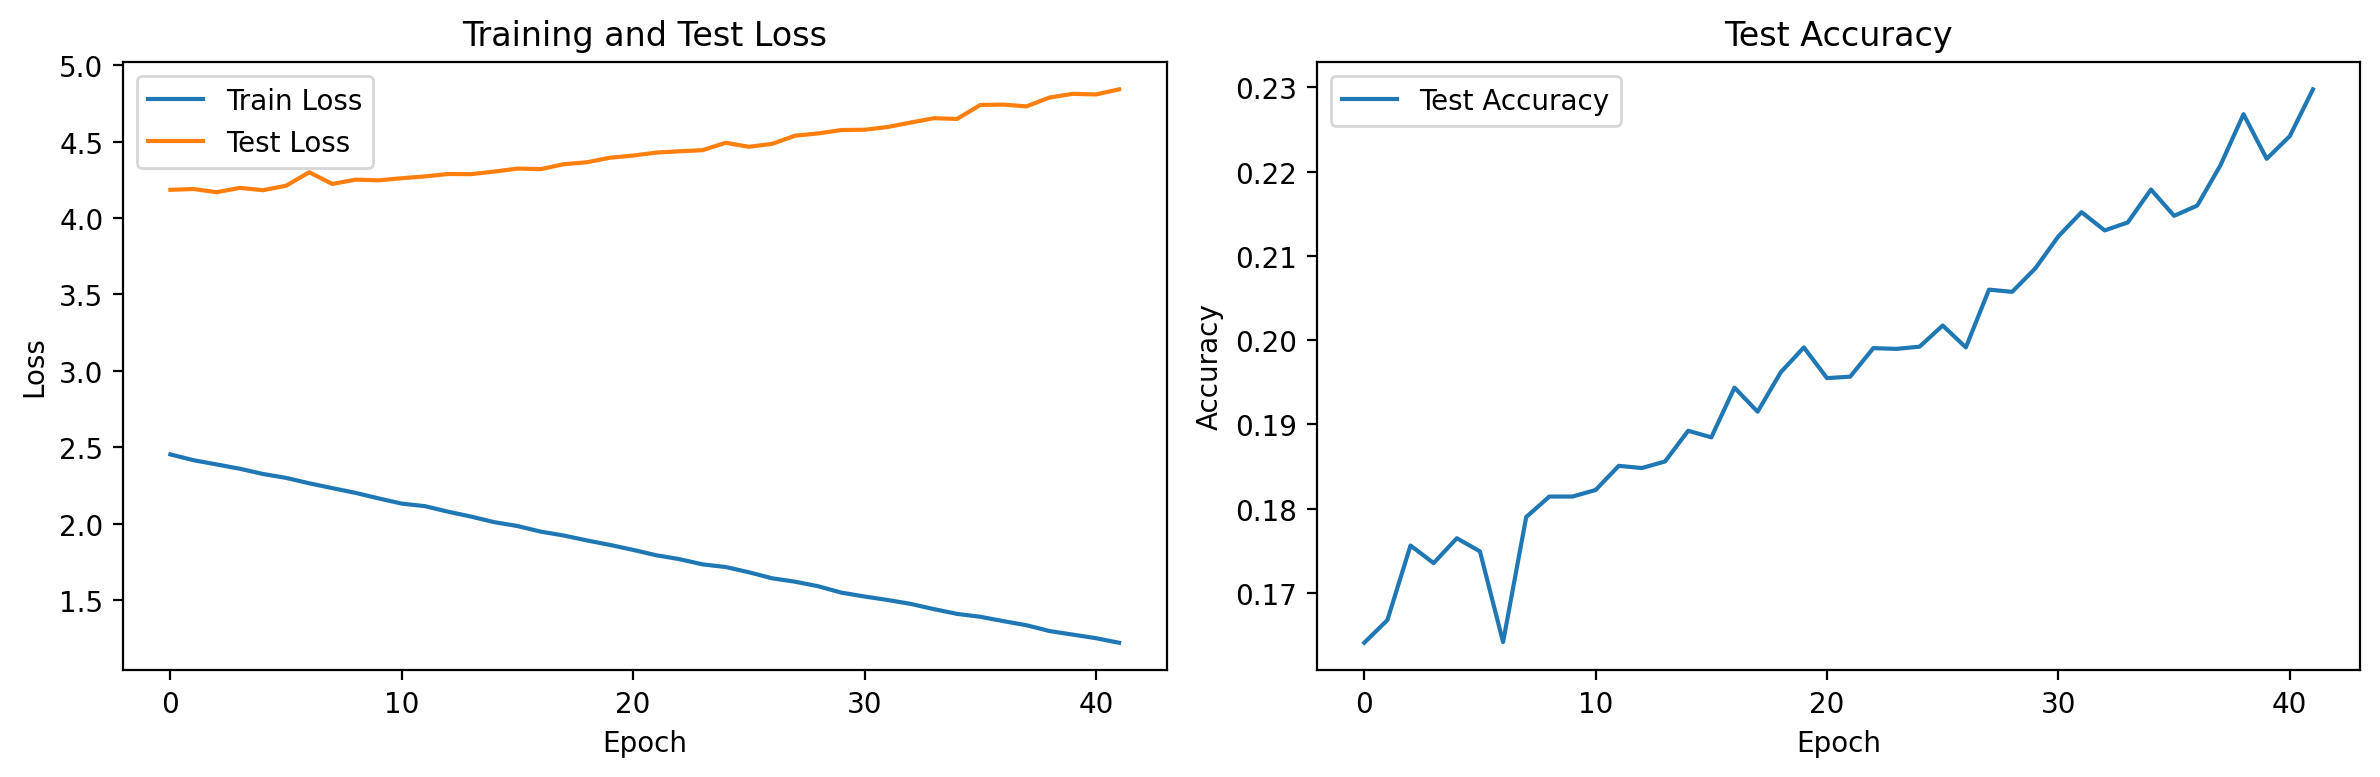

Epoch 42/100, Train Loss: 1.2202, Test Loss: 4.8413, Test Accuracy: 0.2297
Epoch 43/100, Train Loss: 1.1898, Test Loss: 4.8850, Test Accuracy: 0.2340
Epoch 44/100, Train Loss: 1.1655, Test Loss: 4.8963, Test Accuracy: 0.2309
Epoch 45/100, Train Loss: 1.1655, Test Loss: 4.9133, Test Accuracy: 0.2318
Epoch 46/100, Train Loss: 1.1177, Test Loss: 4.9315, Test Accuracy: 0.2271
Epoch 47/100, Train Loss: 1.0866, Test Loss: 4.9700, Test Accuracy: 0.2359
Epoch 48/100, Train Loss: 1.0710, Test Loss: 5.0066, Test Accuracy: 0.2356
Epoch 49/100, Train Loss: 1.0405, Test Loss: 5.0731, Test Accuracy: 0.2395
Epoch 50/100, Train Loss: 1.0080, Test Loss: 5.0908, Test Accuracy: 0.2333
Epoch 51/100, Train Loss: 1.0109, Test Loss: 5.0884, Test Accuracy: 0.2421


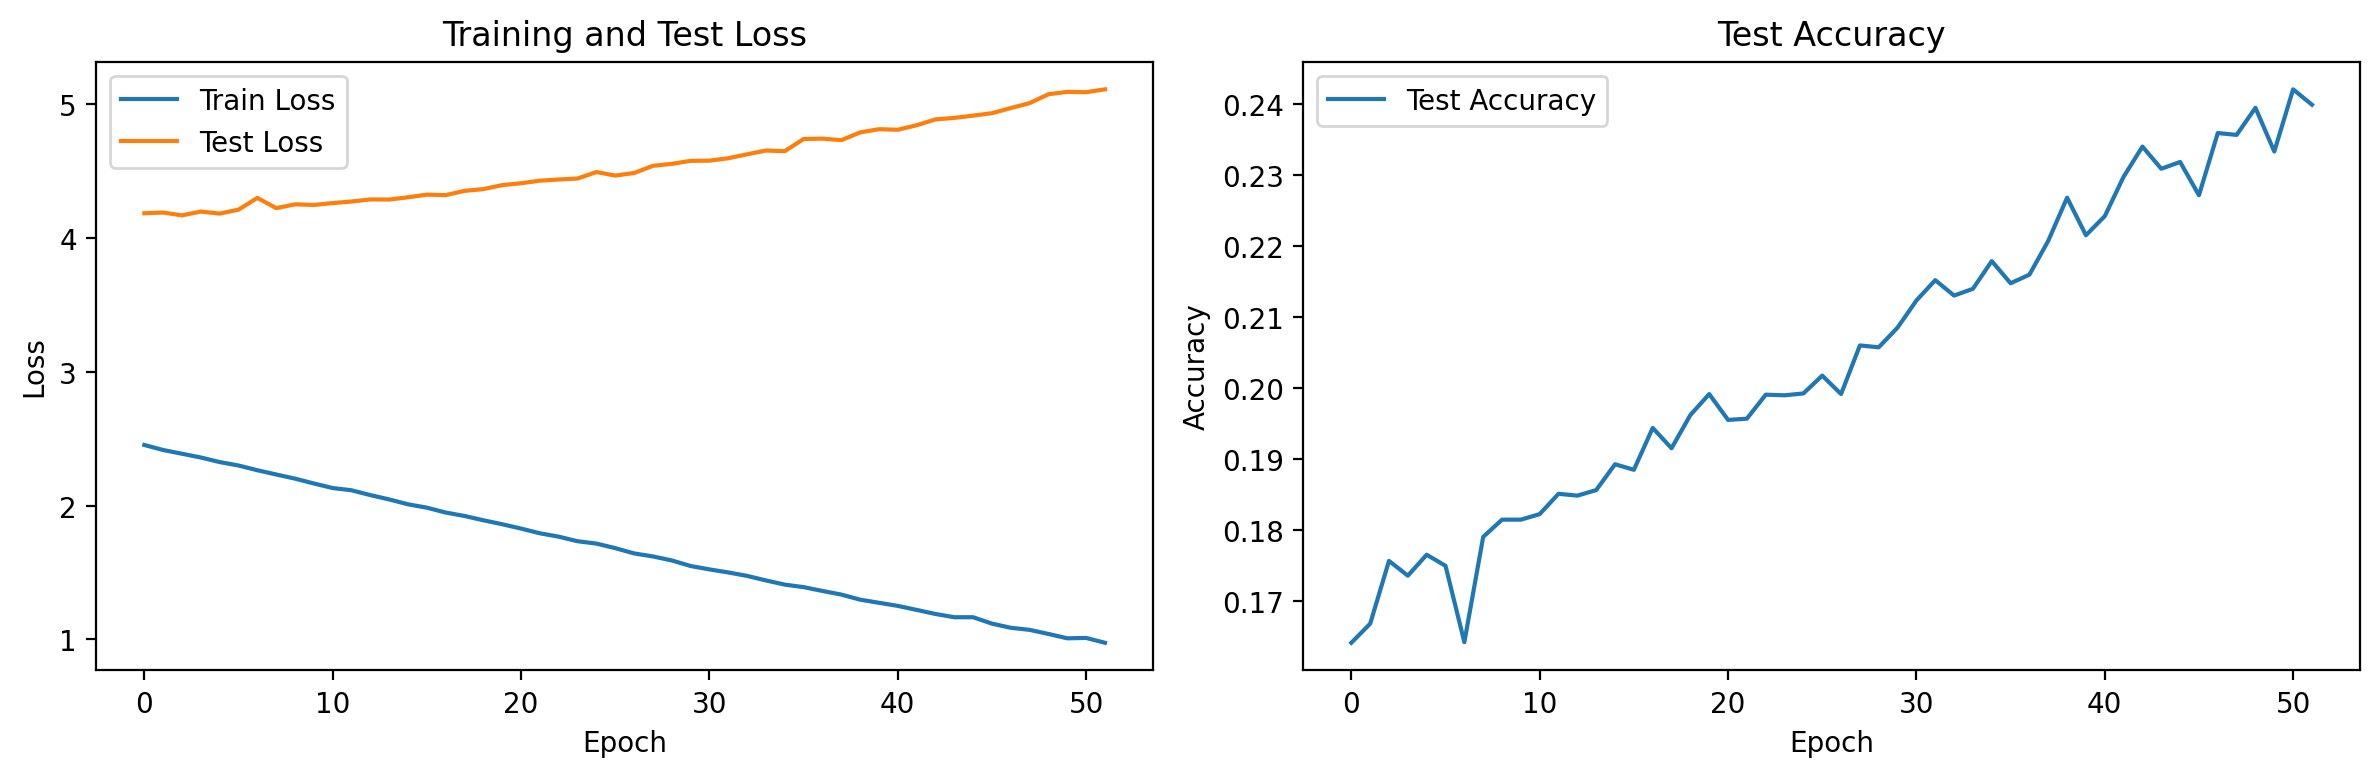

Epoch 52/100, Train Loss: 0.9746, Test Loss: 5.1097, Test Accuracy: 0.2399
Epoch 53/100, Train Loss: 0.9452, Test Loss: 5.1684, Test Accuracy: 0.2438
Epoch 54/100, Train Loss: 0.9180, Test Loss: 5.2232, Test Accuracy: 0.2358
Epoch 55/100, Train Loss: 0.9108, Test Loss: 5.2274, Test Accuracy: 0.2474
Epoch 56/100, Train Loss: 0.8806, Test Loss: 5.2691, Test Accuracy: 0.2490
Epoch 57/100, Train Loss: 0.8545, Test Loss: 5.3579, Test Accuracy: 0.2461
Epoch 58/100, Train Loss: 0.8513, Test Loss: 5.3832, Test Accuracy: 0.2477
Epoch 59/100, Train Loss: 0.8069, Test Loss: 5.3641, Test Accuracy: 0.2552
Epoch 60/100, Train Loss: 0.7911, Test Loss: 5.3834, Test Accuracy: 0.2513
Epoch 61/100, Train Loss: 0.7903, Test Loss: 5.4648, Test Accuracy: 0.2535


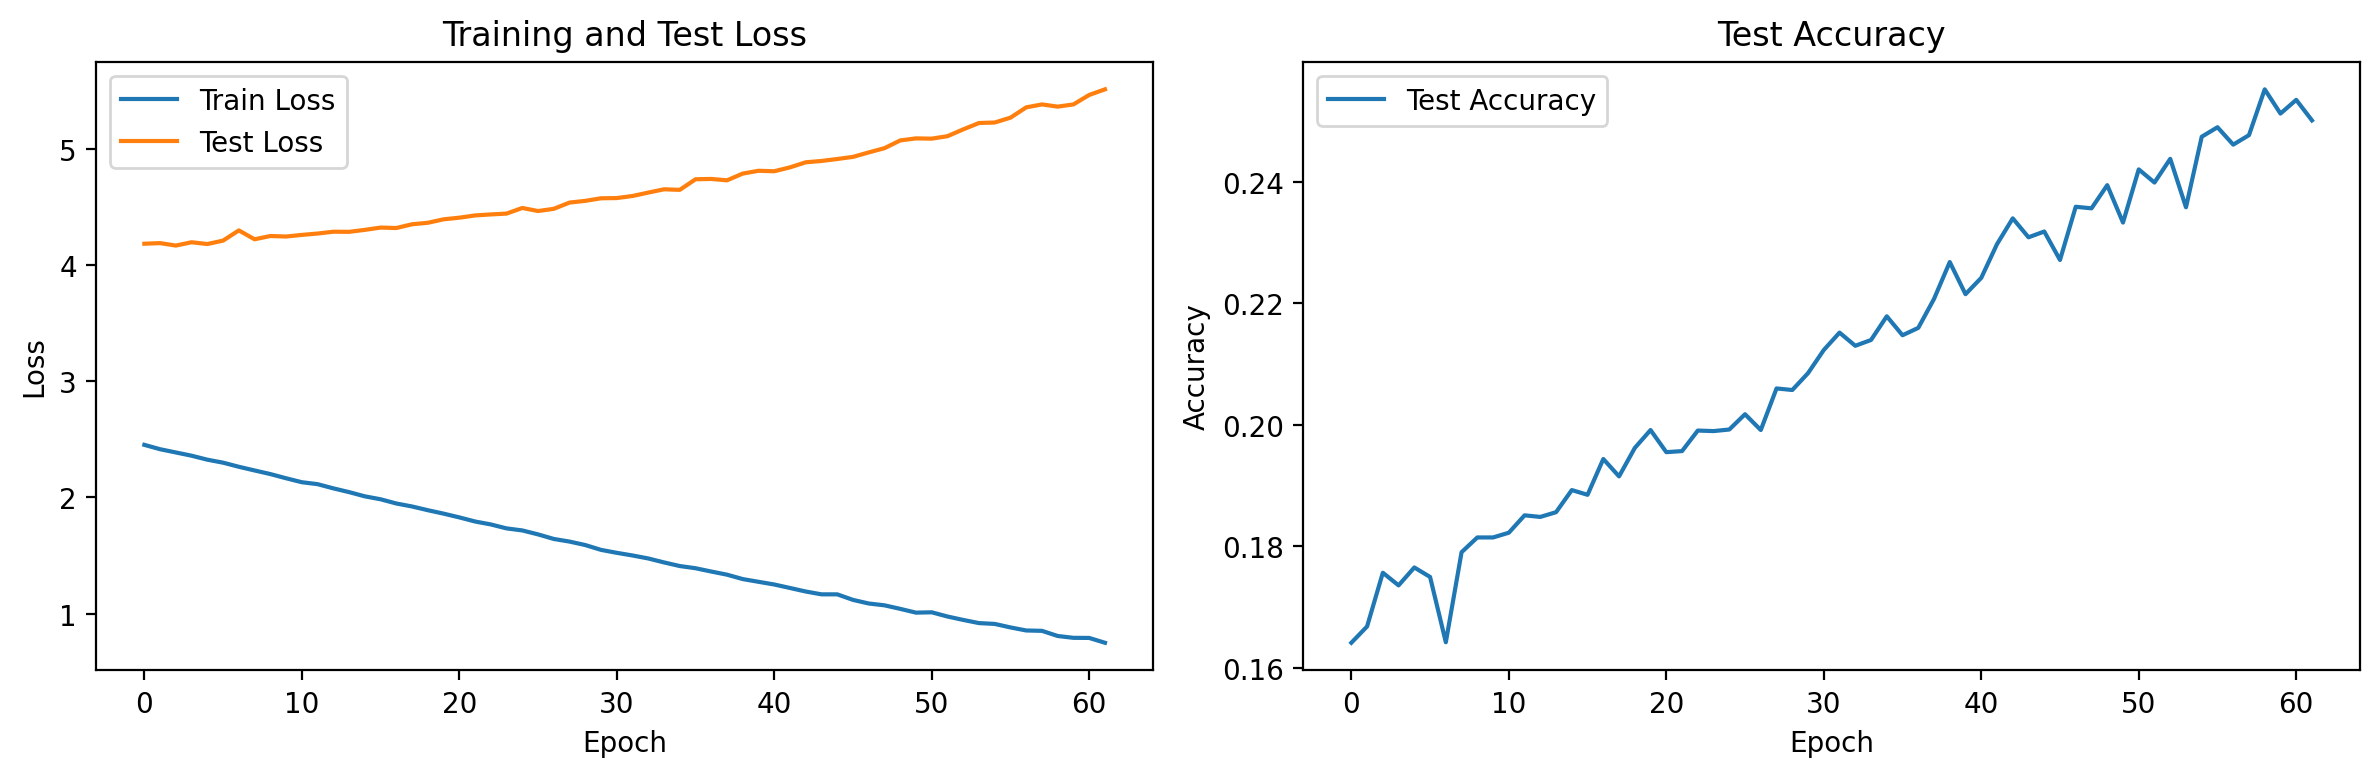

Epoch 62/100, Train Loss: 0.7486, Test Loss: 5.5130, Test Accuracy: 0.2501
Epoch 63/100, Train Loss: 0.7416, Test Loss: 5.4812, Test Accuracy: 0.2536
Epoch 64/100, Train Loss: 0.7172, Test Loss: 5.5311, Test Accuracy: 0.2585
Epoch 65/100, Train Loss: 0.6967, Test Loss: 5.6009, Test Accuracy: 0.2574
Epoch 66/100, Train Loss: 0.6689, Test Loss: 5.6443, Test Accuracy: 0.2593
Epoch 67/100, Train Loss: 0.6697, Test Loss: 5.7098, Test Accuracy: 0.2551
Epoch 68/100, Train Loss: 0.6466, Test Loss: 5.6641, Test Accuracy: 0.2634
Epoch 69/100, Train Loss: 0.6276, Test Loss: 5.6702, Test Accuracy: 0.2619
Epoch 70/100, Train Loss: 0.6132, Test Loss: 5.7731, Test Accuracy: 0.2612
Epoch 71/100, Train Loss: 0.6044, Test Loss: 5.7834, Test Accuracy: 0.2539


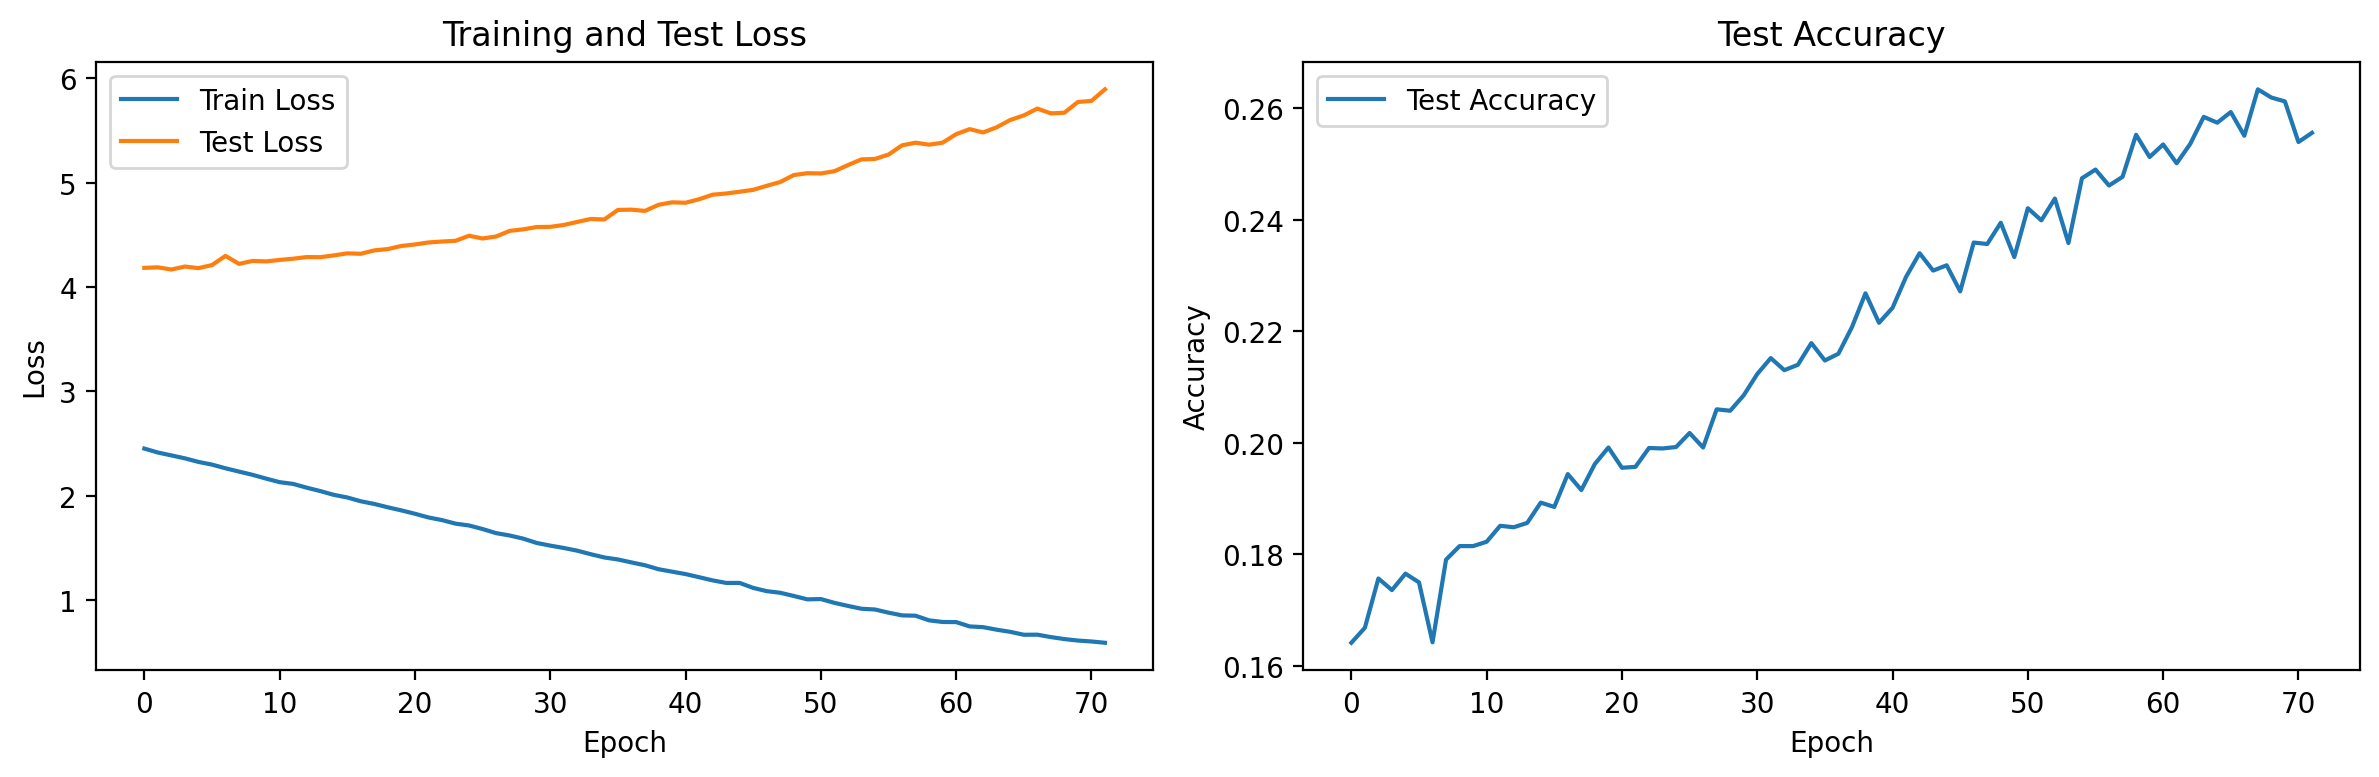

Epoch 72/100, Train Loss: 0.5920, Test Loss: 5.8944, Test Accuracy: 0.2556
Epoch 73/100, Train Loss: 0.5591, Test Loss: 5.9162, Test Accuracy: 0.2604
Epoch 74/100, Train Loss: 0.5555, Test Loss: 5.9362, Test Accuracy: 0.2615
Epoch 75/100, Train Loss: 0.5421, Test Loss: 5.9589, Test Accuracy: 0.2651
Epoch 76/100, Train Loss: 0.5189, Test Loss: 6.0447, Test Accuracy: 0.2596
Epoch 77/100, Train Loss: 0.5144, Test Loss: 6.0621, Test Accuracy: 0.2640
Epoch 78/100, Train Loss: 0.4965, Test Loss: 6.0571, Test Accuracy: 0.2663
Epoch 79/100, Train Loss: 0.4933, Test Loss: 6.1998, Test Accuracy: 0.2589
Epoch 80/100, Train Loss: 0.4623, Test Loss: 6.1186, Test Accuracy: 0.2625
Epoch 81/100, Train Loss: 0.4734, Test Loss: 6.1702, Test Accuracy: 0.2683


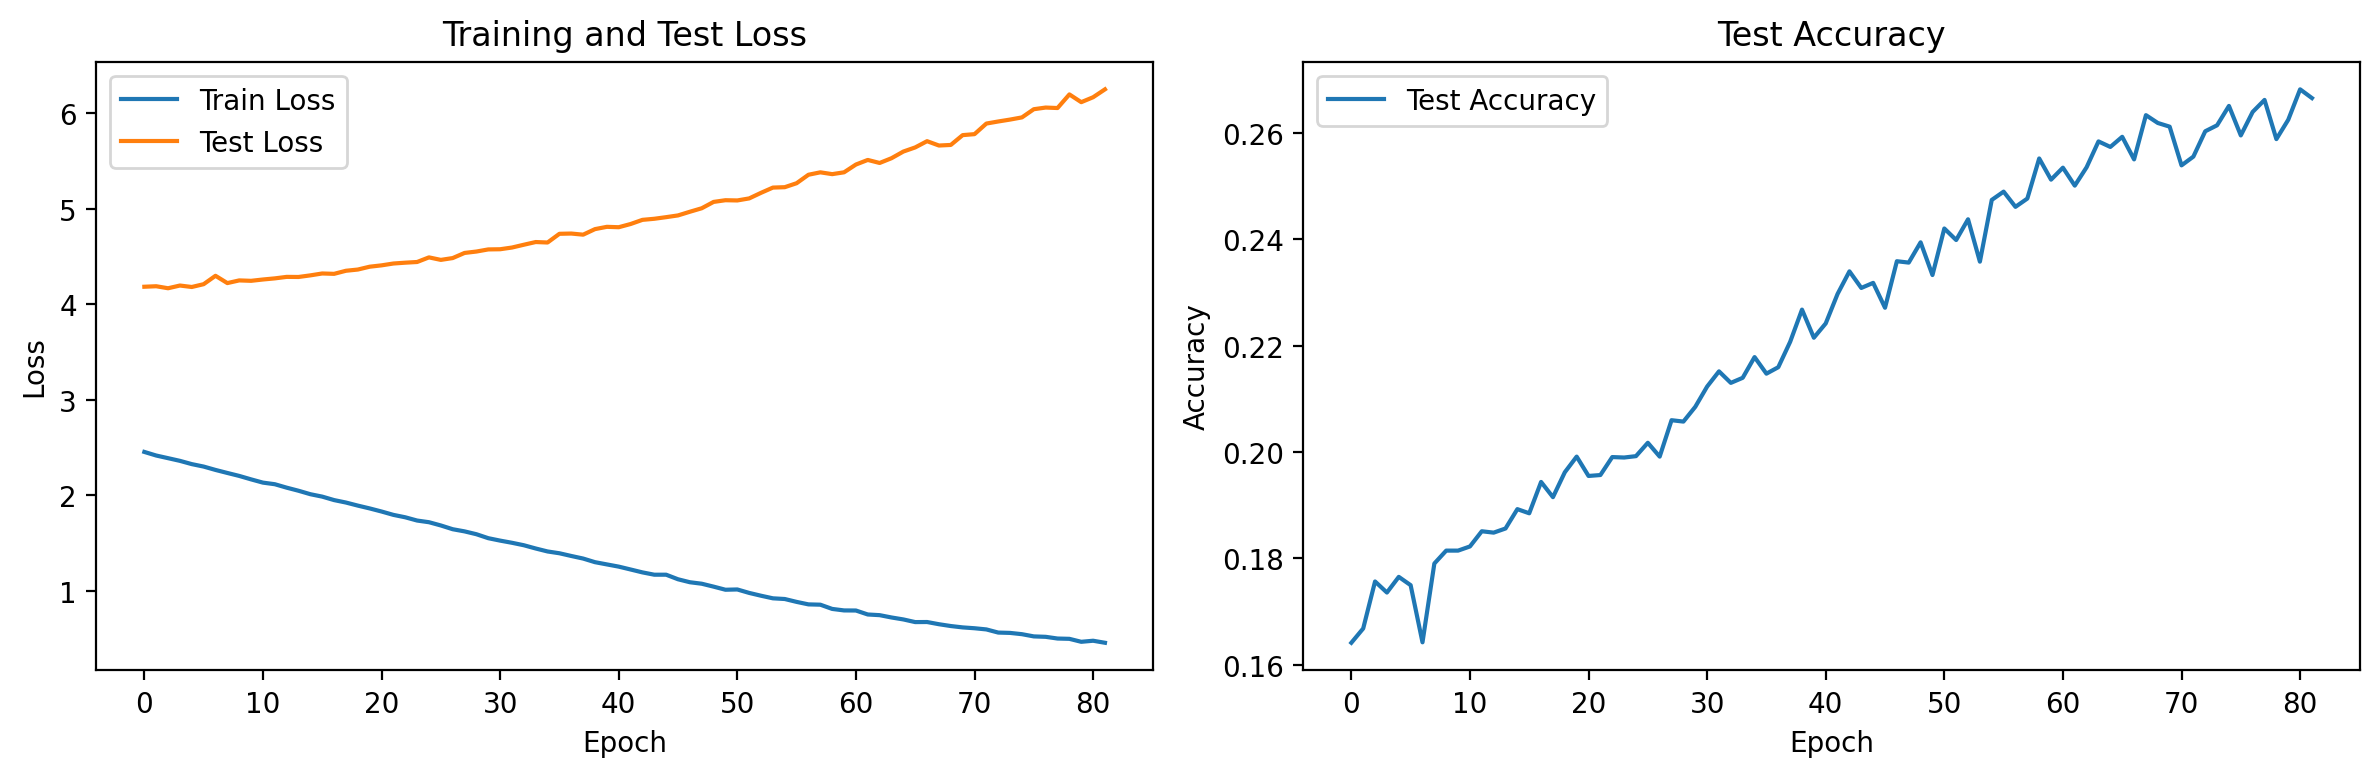

Epoch 82/100, Train Loss: 0.4521, Test Loss: 6.2531, Test Accuracy: 0.2666
Epoch 83/100, Train Loss: 0.4452, Test Loss: 6.2555, Test Accuracy: 0.2675
Epoch 84/100, Train Loss: 0.4469, Test Loss: 6.3169, Test Accuracy: 0.2734
Epoch 85/100, Train Loss: 0.4009, Test Loss: 6.3745, Test Accuracy: 0.2748
Epoch 86/100, Train Loss: 0.4319, Test Loss: 6.3457, Test Accuracy: 0.2709
Epoch 87/100, Train Loss: 0.3985, Test Loss: 6.3982, Test Accuracy: 0.2681
Epoch 88/100, Train Loss: 0.3928, Test Loss: 6.5229, Test Accuracy: 0.2658
Epoch 89/100, Train Loss: 0.3724, Test Loss: 6.4249, Test Accuracy: 0.2733
Epoch 90/100, Train Loss: 0.3630, Test Loss: 6.5621, Test Accuracy: 0.2690
Epoch 91/100, Train Loss: 0.3662, Test Loss: 6.5590, Test Accuracy: 0.2709


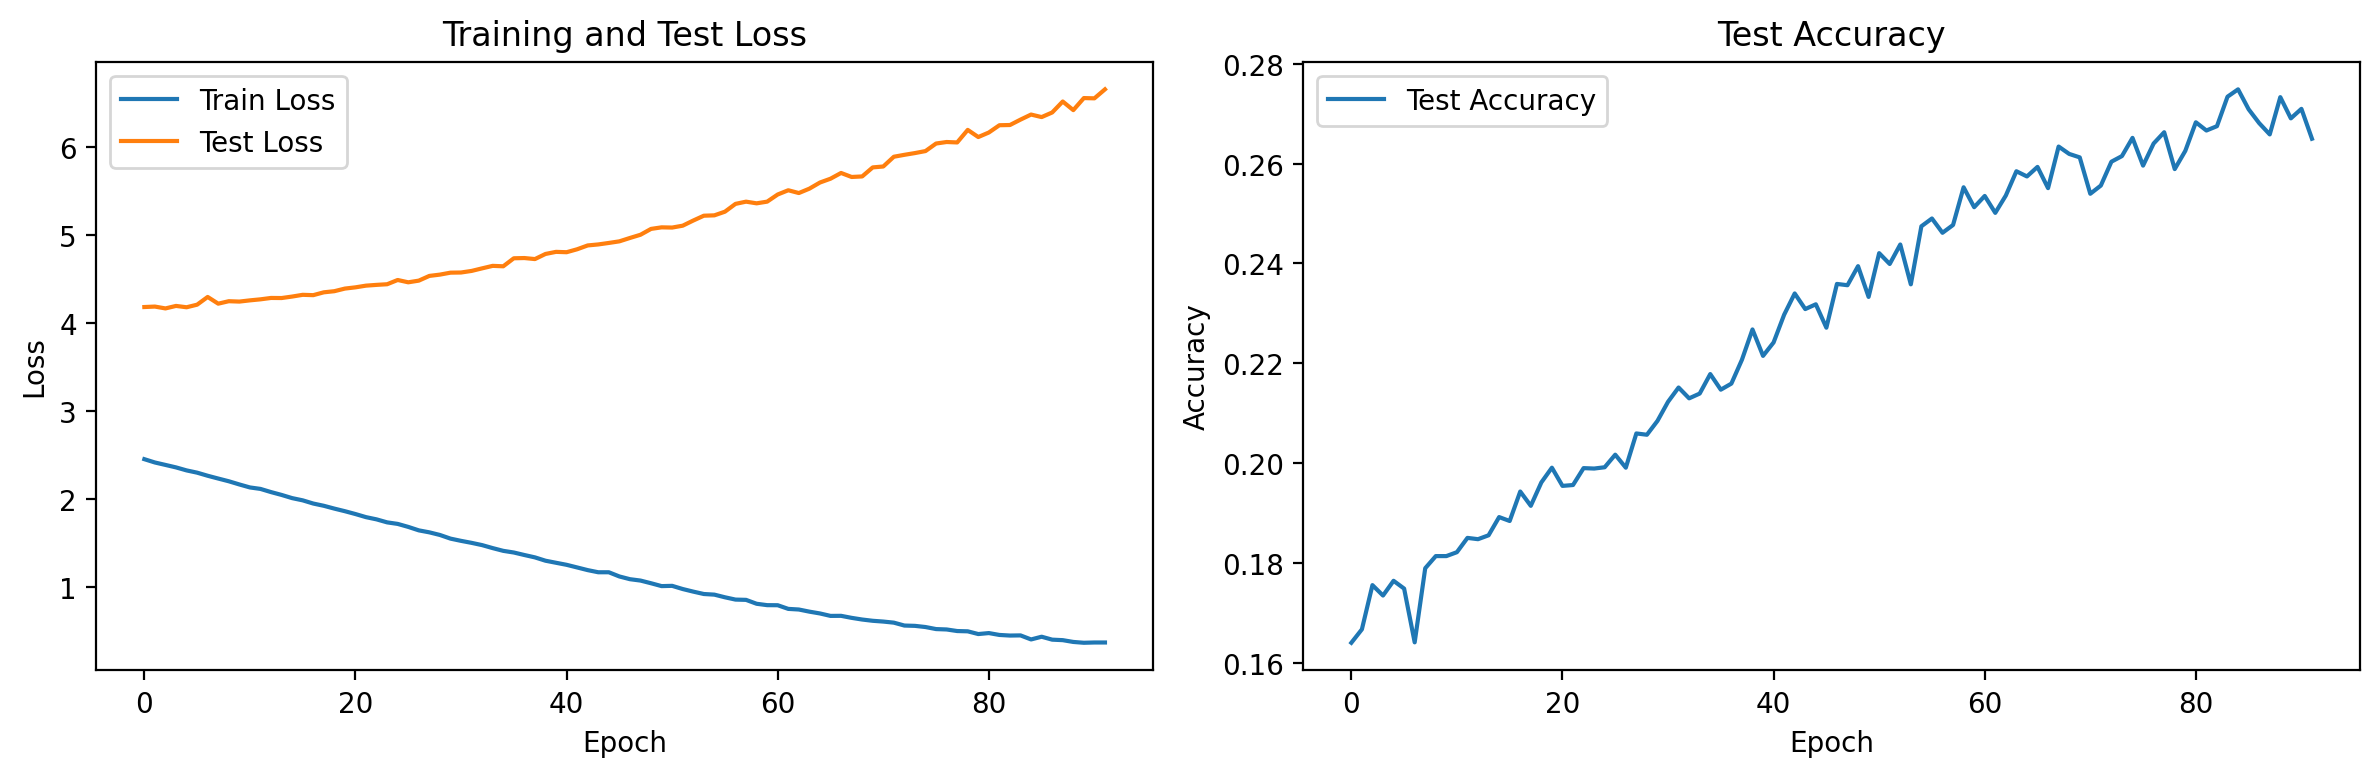

Epoch 92/100, Train Loss: 0.3662, Test Loss: 6.6615, Test Accuracy: 0.2650
Epoch 93/100, Train Loss: 0.3844, Test Loss: 6.5989, Test Accuracy: 0.2742
Epoch 94/100, Train Loss: 0.3463, Test Loss: 6.6427, Test Accuracy: 0.2759
Epoch 95/100, Train Loss: 0.3013, Test Loss: 6.7032, Test Accuracy: 0.2785
Epoch 96/100, Train Loss: 0.3549, Test Loss: 6.7269, Test Accuracy: 0.2761
Epoch 97/100, Train Loss: 0.3159, Test Loss: 6.8213, Test Accuracy: 0.2742
Epoch 98/100, Train Loss: 0.3194, Test Loss: 6.8235, Test Accuracy: 0.2747
Epoch 99/100, Train Loss: 0.3080, Test Loss: 6.8029, Test Accuracy: 0.2742
Epoch 100/100, Train Loss: 0.3054, Test Loss: 6.8965, Test Accuracy: 0.2740


In [ ]:
#train model for another 100 epoch
model, history = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    num_epochs=100,
    device=device
)
torch.save(model.state_dict(), 'music_generator_model2.pth')


In [ ]:
from music21 import stream, note, chord

def notes_to_midi(generated_notes_path, output_midi_path="generated_music.mid"):
    # Read generated notes
    with open(generated_notes_path, "r") as f:
        generated_notes = [line.strip() for line in f if line.strip()]

    output_stream = stream.Stream()

    for element in generated_notes:
        # If it looks like a chord (contains a '.')
        if '.' in element or element.isdigit():
            notes_in_chord = element.split('.')
            # Convert each note number to int if possible, else to pitch
            try:
                chord_notes = [int(n) for n in notes_in_chord]
                new_chord = chord.Chord(chord_notes)
            except ValueError:
                # If not all are integers (e.g., chord like "C4.E4.G4"), treat as pitches
                new_chord = chord.Chord(notes_in_chord)
            output_stream.append(new_chord)
        else:
            # It's a single note
            output_stream.append(note.Note(element))

    # Write to MIDI file
    output_stream.write("midi", fp=output_midi_path)
    print(f"MIDI file has been saved as '{output_midi_path}'")

# Usage


In [ ]:
notes_to_midi("generated_music.txt", "generated_music.mid")

In [ ]:
!apt-get install -y fluidsynth
!pip install -q midi2audio

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fluid-soundfont-gm libevdev2 libfluidsynth3 libgudev-1.0-0 libinput-bin
  libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a libqt5dbus5
  libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libwacom-bin
  libwacom-common libwacom9 libxcb-icccm4 libxcb-image0 libxcb-keysyms1
  libxcb-render-util0 libxcb-util1 libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1
  libxkbcommon-x11-0 qsynth qt5-gtk-platformtheme qttranslations5-l10n
  timgm6mb-soundfont
Suggested packages:
  fluid-soundfont-gs qt5-image-formats-plugins qtwayland5 jackd
The following NEW packages will be installed:
  fluid-soundfont-gm fluidsynth libevdev2 libfluidsynth3 libgudev-1.0-0
  libinput-bin libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libwacom-bin
  libwacom-common libwacom9 libx

In [ ]:
from midi2audio import FluidSynth

def midi_to_wav(midi_path, wav_path):
    # You can specify soundfont with FluidSynth(sound_font='path_to_soundfont.sf2')
    fs = FluidSynth()  # Uses default soundfont
    fs.midi_to_audio(midi_path, wav_path)
    print(f"WAV file has been saved as '{wav_path}'")

# Usage


In [ ]:
midi_to_wav("generated_music.mid", "generated_music.wav")

# try this on mortzard

In [ ]:
class DropOutMusicLSTM(nn.Module):
    """
    LSTM model for music generation with Dropout for regularization
    """
    def __init__(self, input_size, output_size, dropout_prob=0.3):
        super().__init__()

        # First LSTM layer with 512 units
        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=512,
            batch_first=True
        )
        self.dropout1 = nn.Dropout(p=dropout_prob)  # Dropout after the first LSTM layer

        # Second LSTM layer with 256 units
        self.lstm2 = nn.LSTM(
            input_size=512,
            hidden_size=256,
            batch_first=True
        )
        self.dropout2 = nn.Dropout(p=dropout_prob)  # Dropout after the second LSTM layer

        # First Dense layer with 256 units
        self.dense1 = nn.Linear(256, 256)
        self.dropout3 = nn.Dropout(p=dropout_prob)  # Dropout after the first dense layer

        # Second Dense layer with output_size units
        self.dense2 = nn.Linear(256, output_size)

    def forward(self, x):
        # First LSTM layer
        lstm1_out, _ = self.lstm1(x)
        lstm1_out = self.dropout1(lstm1_out)  # Apply dropout

        # Second LSTM layer
        lstm2_out, _ = self.lstm2(lstm1_out)
        lstm2_out = self.dropout2(lstm2_out)  # Apply dropout
        lstm2_out = lstm2_out[:, -1, :]  # Take only the last time step

        # First Dense layer with ReLU activation
        dense1_out = F.relu(self.dense1(lstm2_out))
        dense1_out = self.dropout3(dense1_out)  # Apply dropout

        # Second Dense layer (softmax will be applied in loss function or during prediction)
        output = self.dense2(dense1_out)

        return output

In [ ]:
!unzip mozart.zip -d mozart

Archive:  mozart.zip
  inflating: mozart/mz_333_2.mid     
  inflating: mozart/mz_330_2.mid     
  inflating: mozart/mz_330_3.mid     
  inflating: mozart/mz_333_1.mid     
  inflating: mozart/mz_330_1.mid     
  inflating: mozart/mz_333_3.mid     
  inflating: mozart/mz_331_1.mid     
  inflating: mozart/mz_331_2.mid     
  inflating: mozart/mz_331_3.mid     
  inflating: mozart/mz_332_1.mid     
  inflating: mozart/mz_332_2.mid     
  inflating: mozart/mz_332_3.mid     
  inflating: mozart/mz_311_1.mid     
  inflating: mozart/mz_311_2.mid     
  inflating: mozart/mz_311_3.mid     
  inflating: mozart/mz_545_3.mid     
  inflating: mozart/mz_545_1.mid     
  inflating: mozart/mz_545_2.mid     
  inflating: mozart/mz_570_1.mid     
  inflating: mozart/mz_570_2.mid     
  inflating: mozart/mz_570_3.mid     



Extracting notes from MIDI files:
Extracting notes from: ./mozart/mz_570_1.mid


/usr/local/lib/python3.11/dist-packages/music21/midi/translate.py:874: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=5, channel=None, data=b'Copyright \xa9 2006 by Bernd Krueger'>; getting generic Instrument
  warnings.warn(


  - mz_570_1.mid: Extracted 3840 notes/chords
Extracting notes from: ./mozart/mz_570_2.mid
  - mz_570_2.mid: Extracted 1569 notes/chords
Extracting notes from: ./mozart/mz_330_3.mid


/usr/local/lib/python3.11/dist-packages/music21/midi/translate.py:874: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=5, channel=None, data=b'Copyright \xa9 1997 by Bernd Kr\xfcger'>; getting generic Instrument
  warnings.warn(


  - mz_330_3.mid: Extracted 3498 notes/chords
Extracting notes from: ./mozart/mz_332_3.mid


/usr/local/lib/python3.11/dist-packages/music21/midi/translate.py:874: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=5, channel=None, data=b'Copyright \xa9 2006 by Bernd Kr\xfcger'>; getting generic Instrument
  warnings.warn(


  - mz_332_3.mid: Extracted 5240 notes/chords
Extracting notes from: ./mozart/mz_332_2.mid
  - mz_332_2.mid: Extracted 1131 notes/chords
Extracting notes from: ./mozart/mz_545_1.mid
  - mz_545_1.mid: Extracted 2428 notes/chords
Extracting notes from: ./mozart/mz_331_2.mid


/usr/local/lib/python3.11/dist-packages/music21/midi/translate.py:874: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=5, channel=None, data=b'Copyright \xa9 2005 by Bernd Kr\xfcger'>; getting generic Instrument
  warnings.warn(


  - mz_331_2.mid: Extracted 2245 notes/chords
Extracting notes from: ./mozart/mz_570_3.mid
  - mz_570_3.mid: Extracted 1684 notes/chords
Extracting notes from: ./mozart/mz_331_1.mid
  - mz_331_1.mid: Extracted 4532 notes/chords
Extracting notes from: ./mozart/mz_333_2.mid
  - mz_333_2.mid: Extracted 2139 notes/chords
Extracting notes from: ./mozart/mz_330_1.mid
  - mz_330_1.mid: Extracted 3448 notes/chords
Extracting notes from: ./mozart/mz_331_3.mid
  - mz_331_3.mid: Extracted 2043 notes/chords
Extracting notes from: ./mozart/mz_333_3.mid
  - mz_333_3.mid: Extracted 2692 notes/chords
Extracting notes from: ./mozart/mz_545_3.mid
  - mz_545_3.mid: Extracted 784 notes/chords
Extracting notes from: ./mozart/mz_311_1.mid
  - mz_311_1.mid: Extracted 2601 notes/chords
Extracting notes from: ./mozart/mz_333_1.mid
  - mz_333_1.mid: Extracted 5236 notes/chords
Extracting notes from: ./mozart/mz_311_3.mid
  - mz_311_3.mid: Extracted 2856 notes/chords
Extracting notes from: ./mozart/mz_545_2.mid


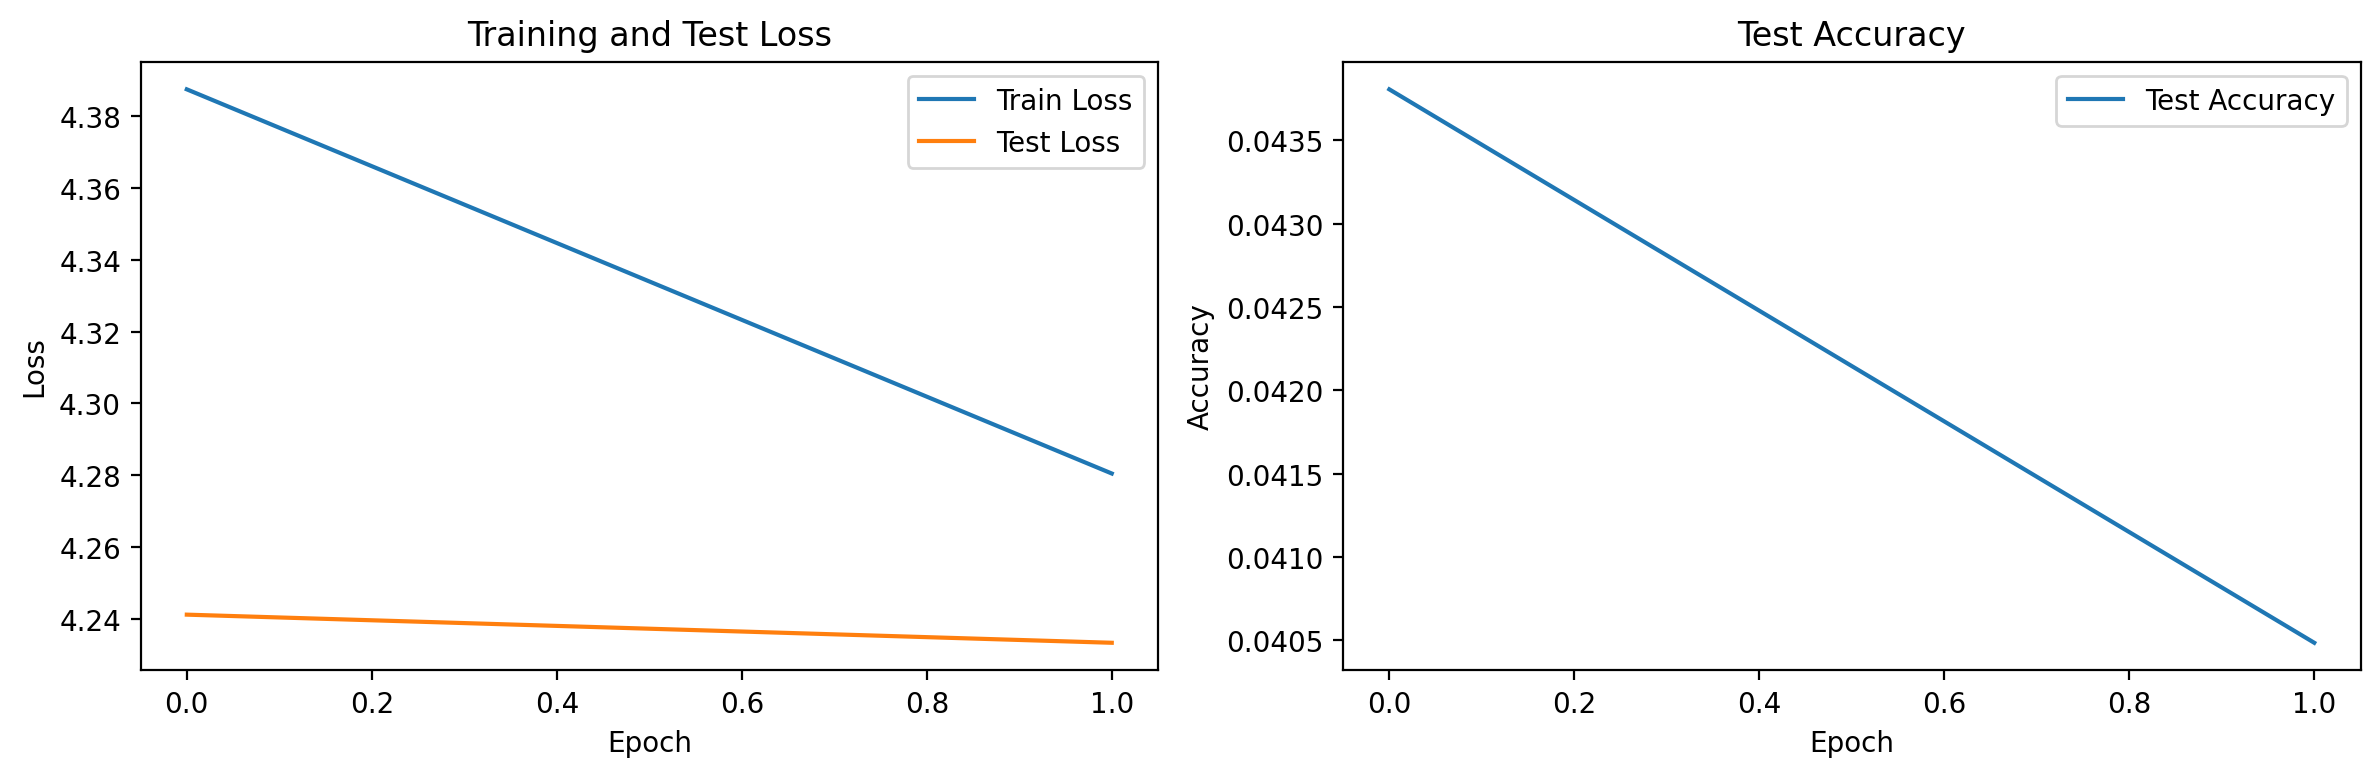

Epoch 2/100, Train Loss: 4.2805, Test Loss: 4.2334, Test Accuracy: 0.0405
Epoch 3/100, Train Loss: 4.2704, Test Loss: 4.2351, Test Accuracy: 0.0391
Epoch 4/100, Train Loss: 4.2536, Test Loss: 4.1911, Test Accuracy: 0.0438
Epoch 5/100, Train Loss: 4.2022, Test Loss: 4.1618, Test Accuracy: 0.0438
Epoch 6/100, Train Loss: 4.1702, Test Loss: 4.1434, Test Accuracy: 0.0448
Epoch 7/100, Train Loss: 4.1531, Test Loss: 4.1311, Test Accuracy: 0.0437
Epoch 8/100, Train Loss: 4.1437, Test Loss: 4.1257, Test Accuracy: 0.0476
Epoch 9/100, Train Loss: 4.1374, Test Loss: 4.1230, Test Accuracy: 0.0489
Epoch 10/100, Train Loss: 4.1314, Test Loss: 4.1201, Test Accuracy: 0.0487
Epoch 11/100, Train Loss: 4.1240, Test Loss: 4.1131, Test Accuracy: 0.0478


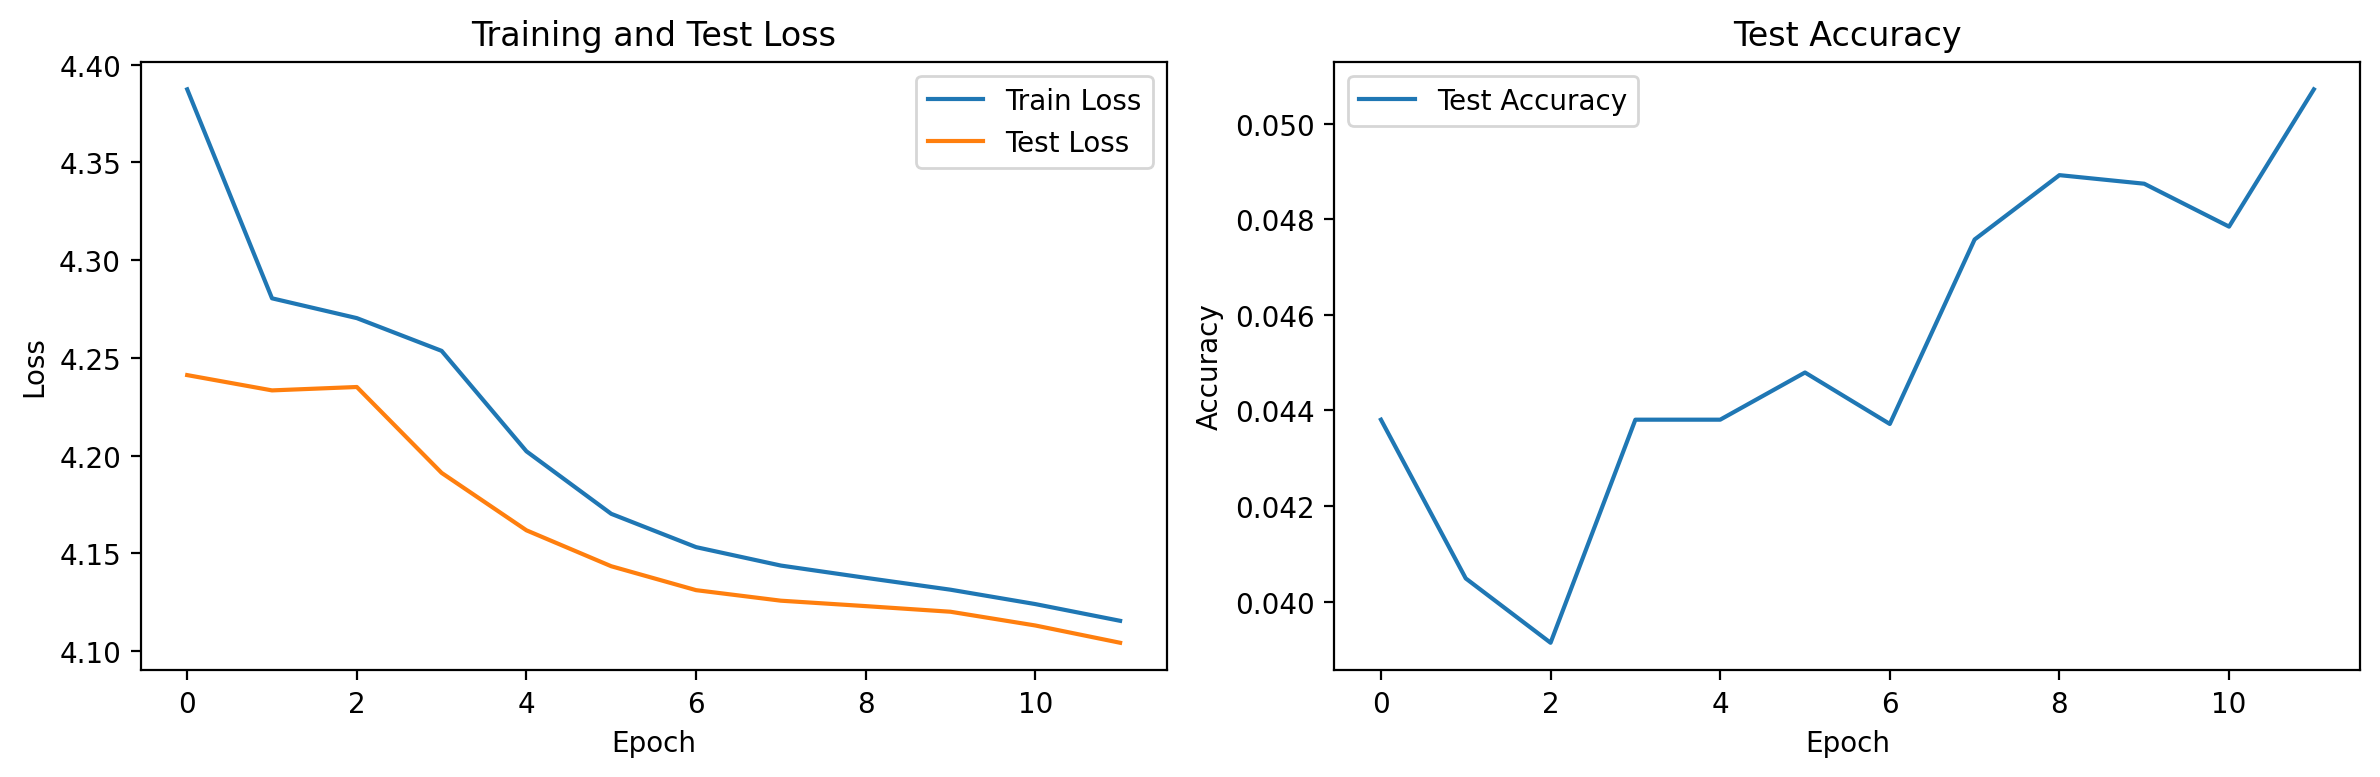

Epoch 12/100, Train Loss: 4.1154, Test Loss: 4.1042, Test Accuracy: 0.0507
Epoch 13/100, Train Loss: 4.1084, Test Loss: 4.1103, Test Accuracy: 0.0532
Epoch 14/100, Train Loss: 4.0978, Test Loss: 4.0918, Test Accuracy: 0.0557
Epoch 15/100, Train Loss: 4.0876, Test Loss: 4.0779, Test Accuracy: 0.0533
Epoch 16/100, Train Loss: 4.0775, Test Loss: 4.0779, Test Accuracy: 0.0581
Epoch 17/100, Train Loss: 4.0700, Test Loss: 4.0656, Test Accuracy: 0.0550
Epoch 18/100, Train Loss: 4.0617, Test Loss: 4.0646, Test Accuracy: 0.0602
Epoch 19/100, Train Loss: 4.0518, Test Loss: 4.0503, Test Accuracy: 0.0572
Epoch 20/100, Train Loss: 4.0451, Test Loss: 4.0386, Test Accuracy: 0.0603
Epoch 21/100, Train Loss: 4.0353, Test Loss: 4.0328, Test Accuracy: 0.0628


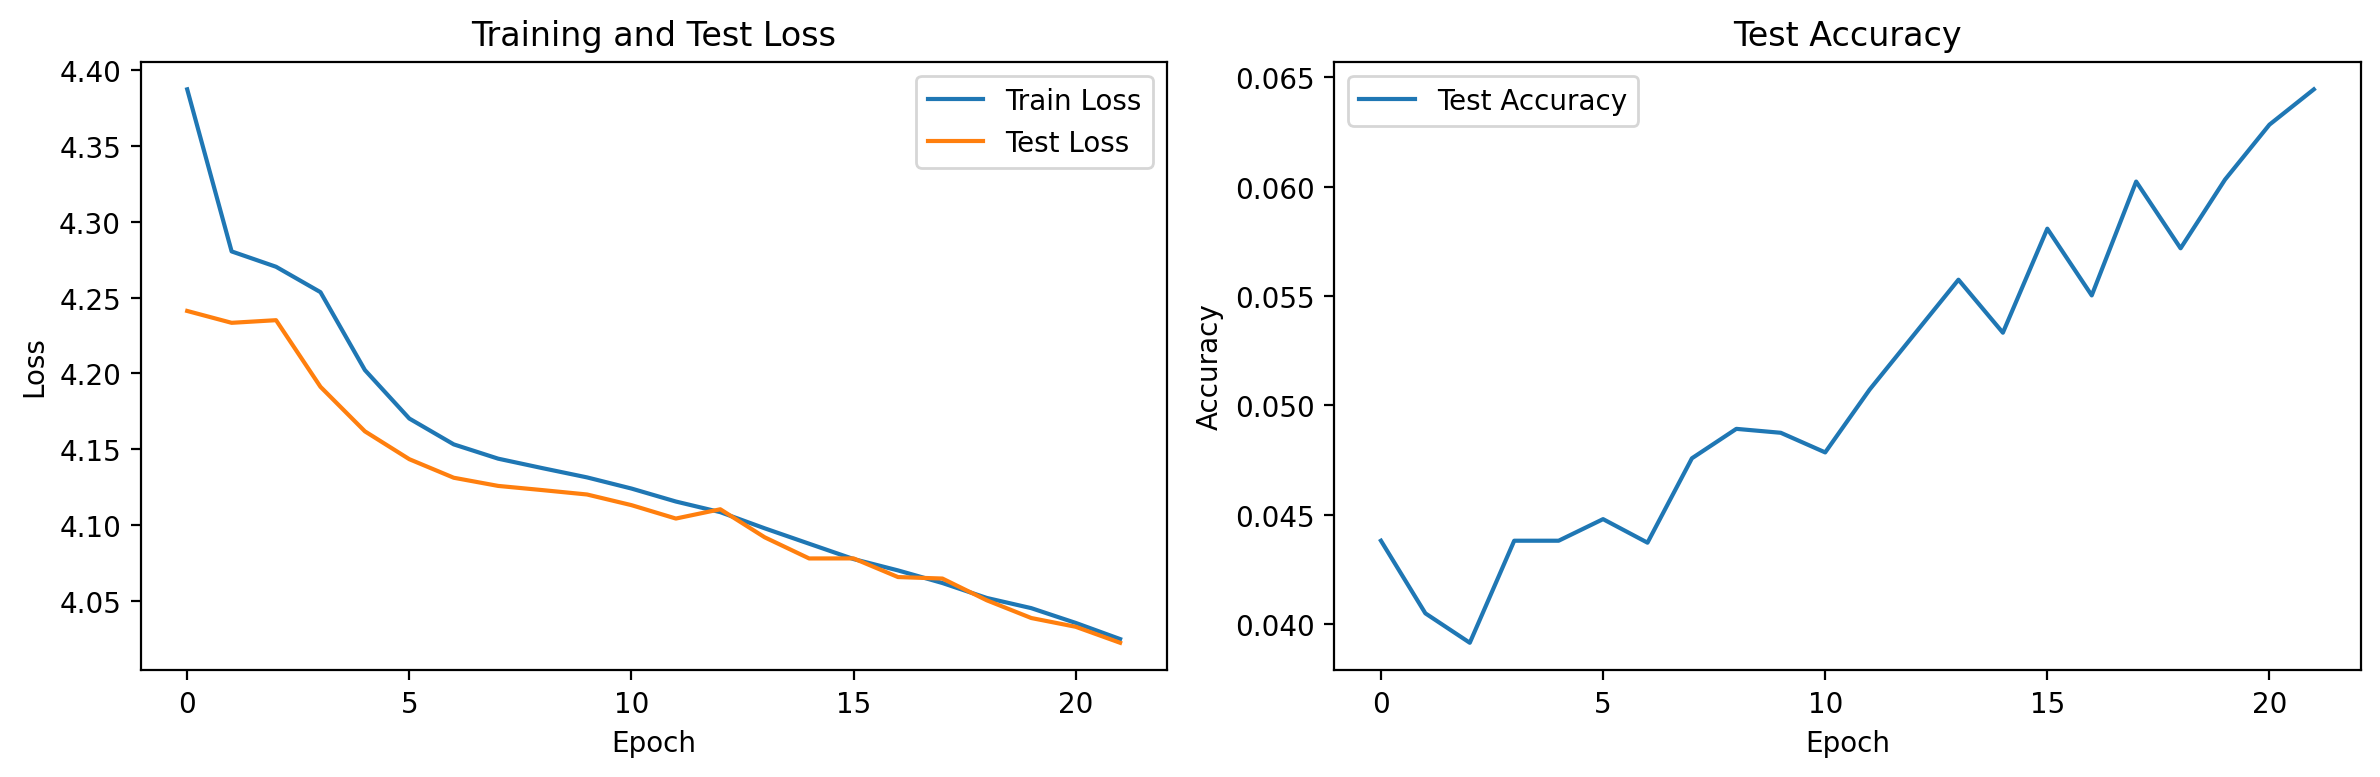

Epoch 22/100, Train Loss: 4.0247, Test Loss: 4.0222, Test Accuracy: 0.0645
Epoch 23/100, Train Loss: 4.0133, Test Loss: 4.0114, Test Accuracy: 0.0671
Epoch 24/100, Train Loss: 4.0026, Test Loss: 4.0084, Test Accuracy: 0.0647
Epoch 25/100, Train Loss: 3.9928, Test Loss: 4.0058, Test Accuracy: 0.0636
Epoch 26/100, Train Loss: 3.9792, Test Loss: 3.9840, Test Accuracy: 0.0677
Epoch 27/100, Train Loss: 3.9648, Test Loss: 3.9721, Test Accuracy: 0.0697
Epoch 28/100, Train Loss: 3.9530, Test Loss: 3.9710, Test Accuracy: 0.0700
Epoch 29/100, Train Loss: 3.9404, Test Loss: 3.9492, Test Accuracy: 0.0727
Epoch 30/100, Train Loss: 3.9256, Test Loss: 3.9543, Test Accuracy: 0.0708
Epoch 31/100, Train Loss: 3.9142, Test Loss: 3.9308, Test Accuracy: 0.0731


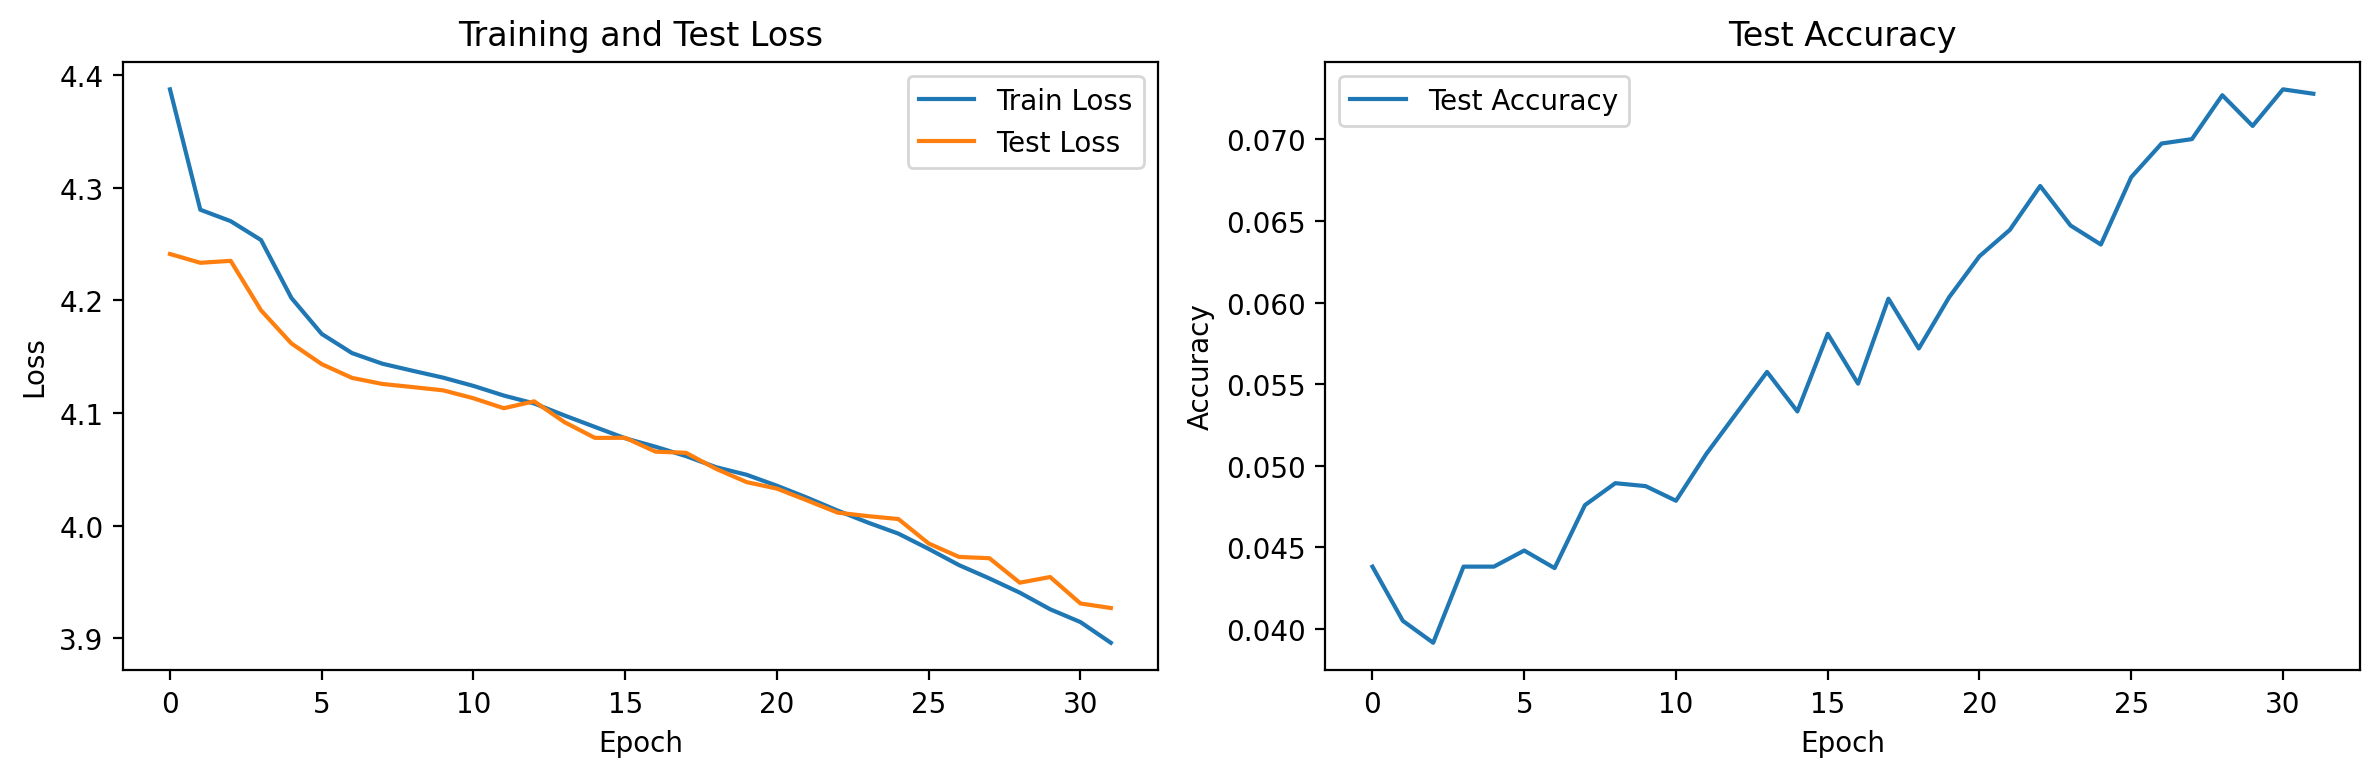

Epoch 32/100, Train Loss: 3.8959, Test Loss: 3.9267, Test Accuracy: 0.0728
Epoch 33/100, Train Loss: 3.8778, Test Loss: 3.9000, Test Accuracy: 0.0757
Epoch 34/100, Train Loss: 3.8610, Test Loss: 3.9005, Test Accuracy: 0.0783
Epoch 35/100, Train Loss: 3.8475, Test Loss: 3.8967, Test Accuracy: 0.0760
Epoch 36/100, Train Loss: 3.8275, Test Loss: 3.8693, Test Accuracy: 0.0812
Epoch 37/100, Train Loss: 3.8136, Test Loss: 3.8476, Test Accuracy: 0.0871
Epoch 38/100, Train Loss: 3.7936, Test Loss: 3.8280, Test Accuracy: 0.0882
Epoch 39/100, Train Loss: 3.7759, Test Loss: 3.8221, Test Accuracy: 0.0903
Epoch 40/100, Train Loss: 3.7571, Test Loss: 3.8001, Test Accuracy: 0.0944
Epoch 41/100, Train Loss: 3.7370, Test Loss: 3.7925, Test Accuracy: 0.0916


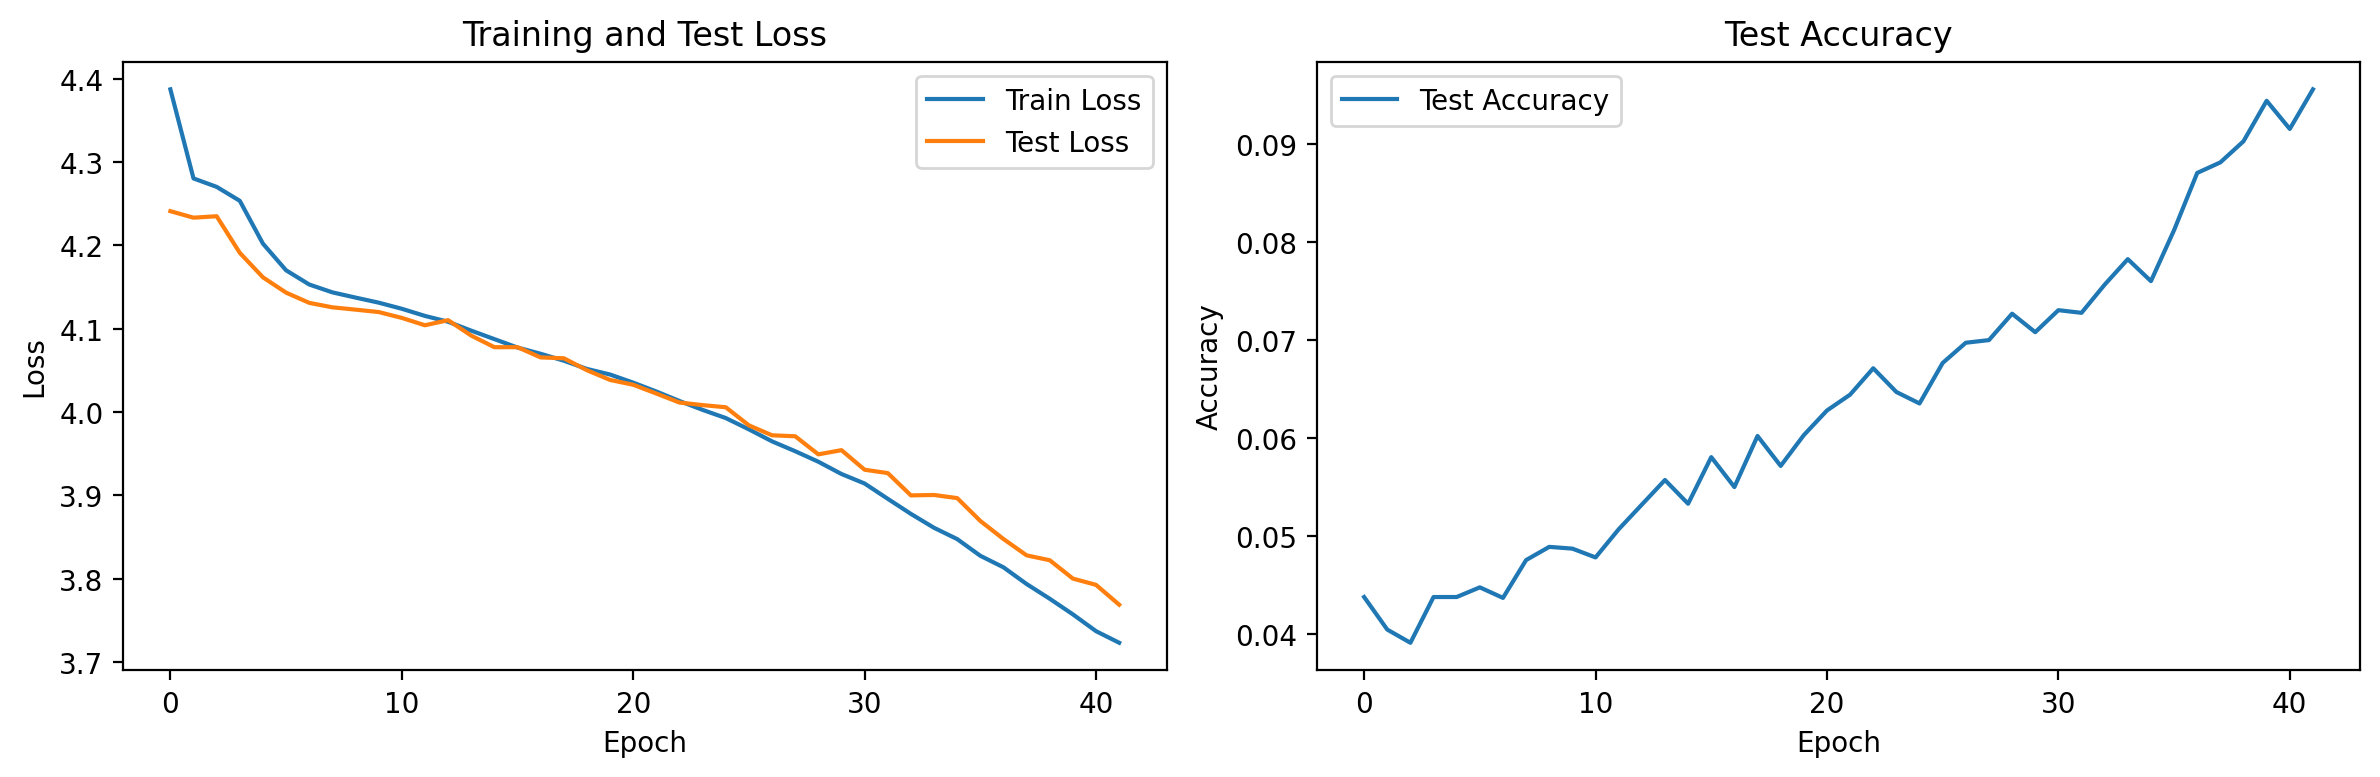

Epoch 42/100, Train Loss: 3.7230, Test Loss: 3.7687, Test Accuracy: 0.0956
Epoch 43/100, Train Loss: 3.6999, Test Loss: 3.7593, Test Accuracy: 0.0972
Epoch 44/100, Train Loss: 3.6832, Test Loss: 3.7386, Test Accuracy: 0.1004
Epoch 45/100, Train Loss: 3.6645, Test Loss: 3.7308, Test Accuracy: 0.0990
Epoch 46/100, Train Loss: 3.6431, Test Loss: 3.7151, Test Accuracy: 0.1031
Epoch 47/100, Train Loss: 3.6244, Test Loss: 3.7356, Test Accuracy: 0.0977
Epoch 48/100, Train Loss: 3.6096, Test Loss: 3.6852, Test Accuracy: 0.1063
Epoch 49/100, Train Loss: 3.5882, Test Loss: 3.6718, Test Accuracy: 0.1088
Epoch 50/100, Train Loss: 3.5681, Test Loss: 3.6685, Test Accuracy: 0.1106
Epoch 51/100, Train Loss: 3.5499, Test Loss: 3.6475, Test Accuracy: 0.1099


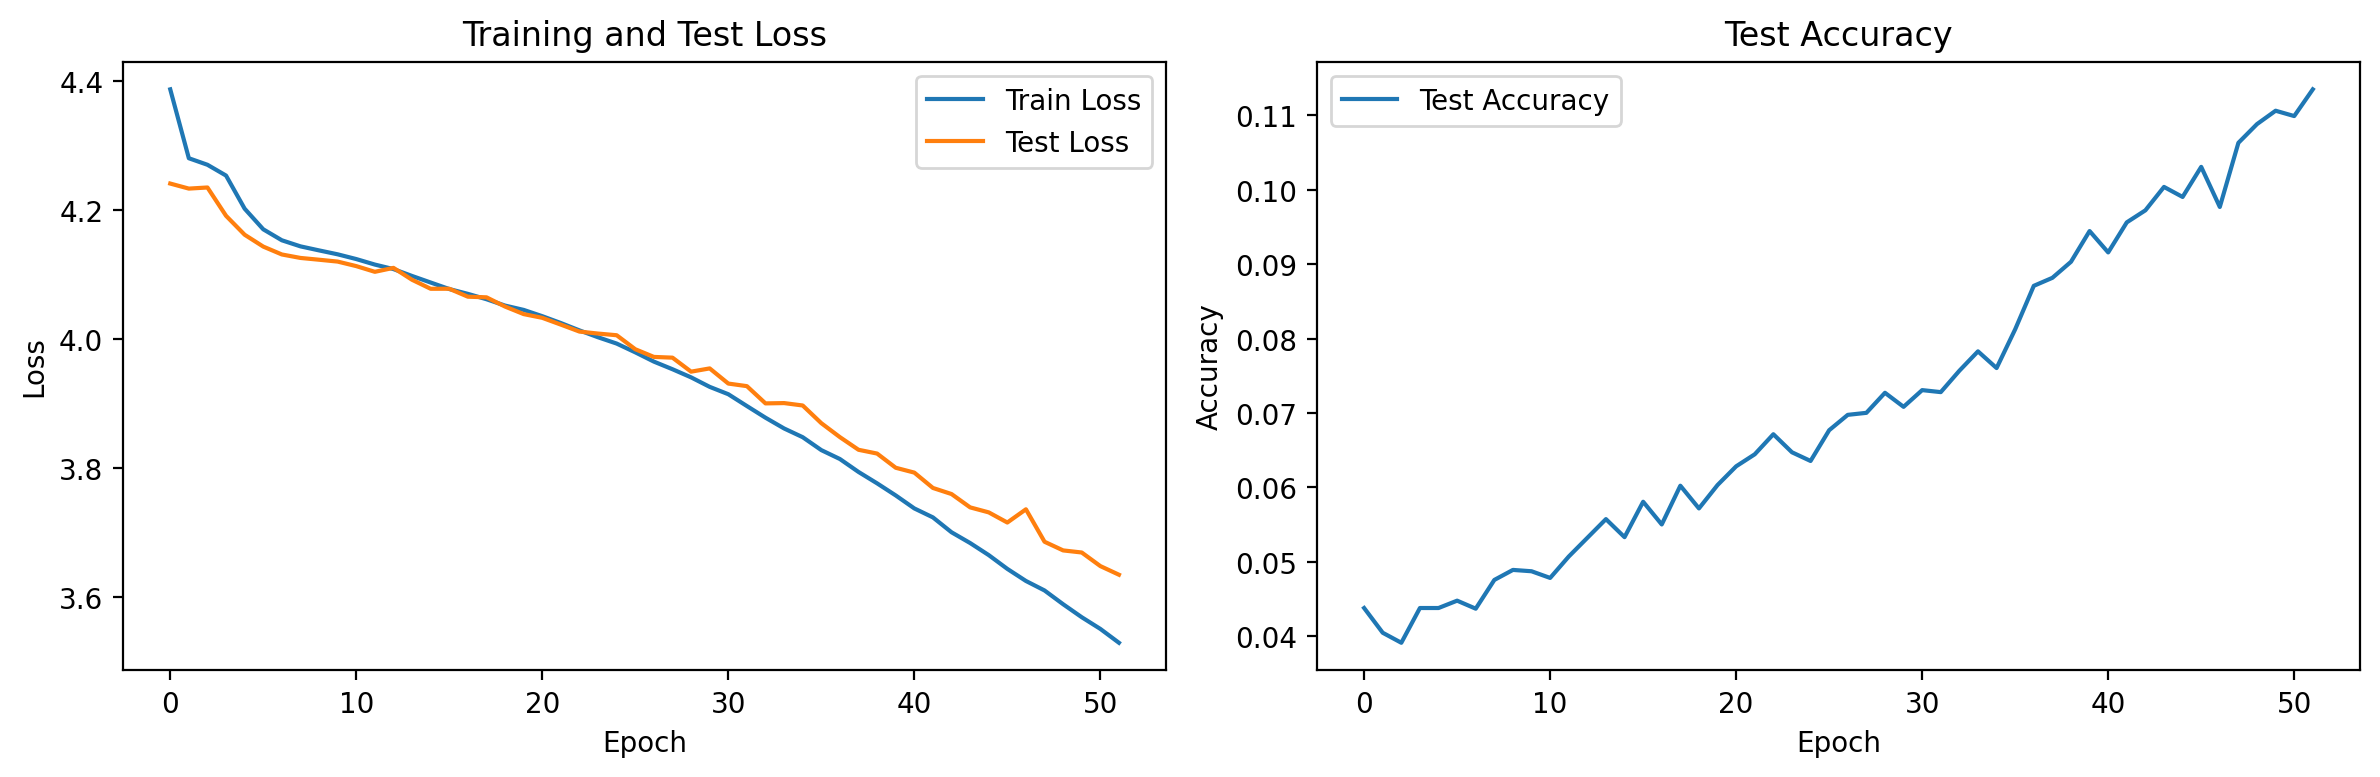

Epoch 52/100, Train Loss: 3.5284, Test Loss: 3.6341, Test Accuracy: 0.1135
Epoch 53/100, Train Loss: 3.5116, Test Loss: 3.6176, Test Accuracy: 0.1129
Epoch 54/100, Train Loss: 3.4993, Test Loss: 3.6136, Test Accuracy: 0.1163
Epoch 55/100, Train Loss: 3.4780, Test Loss: 3.5928, Test Accuracy: 0.1170
Epoch 56/100, Train Loss: 3.4602, Test Loss: 3.5939, Test Accuracy: 0.1199
Epoch 57/100, Train Loss: 3.4408, Test Loss: 3.5784, Test Accuracy: 0.1197
Epoch 58/100, Train Loss: 3.4200, Test Loss: 3.5613, Test Accuracy: 0.1234
Epoch 59/100, Train Loss: 3.4032, Test Loss: 3.5520, Test Accuracy: 0.1289
Epoch 60/100, Train Loss: 3.3909, Test Loss: 3.5405, Test Accuracy: 0.1276
Epoch 61/100, Train Loss: 3.3734, Test Loss: 3.5342, Test Accuracy: 0.1243


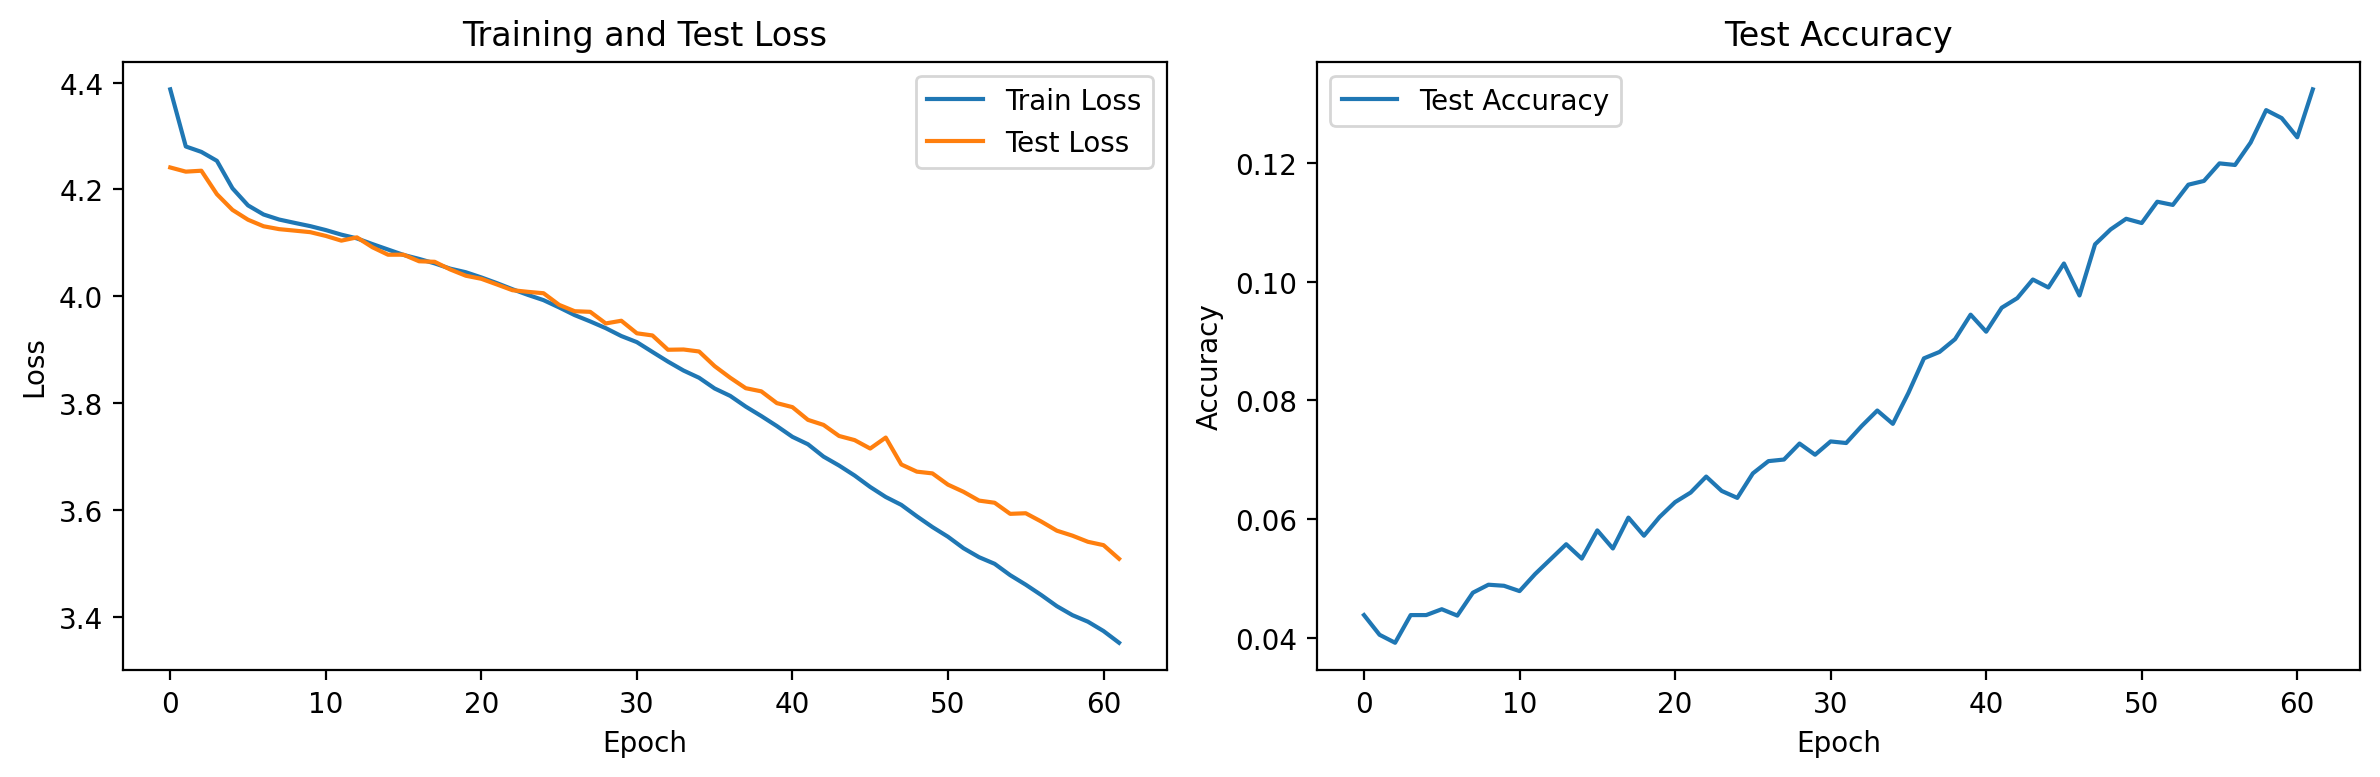

Epoch 62/100, Train Loss: 3.3515, Test Loss: 3.5087, Test Accuracy: 0.1324
Epoch 63/100, Train Loss: 3.3327, Test Loss: 3.5123, Test Accuracy: 0.1309
Epoch 64/100, Train Loss: 3.3244, Test Loss: 3.5010, Test Accuracy: 0.1336
Epoch 65/100, Train Loss: 3.2996, Test Loss: 3.4902, Test Accuracy: 0.1376
Epoch 66/100, Train Loss: 3.2793, Test Loss: 3.4801, Test Accuracy: 0.1324
Epoch 67/100, Train Loss: 3.2659, Test Loss: 3.4631, Test Accuracy: 0.1396
Epoch 68/100, Train Loss: 3.2516, Test Loss: 3.4587, Test Accuracy: 0.1393
Epoch 69/100, Train Loss: 3.2327, Test Loss: 3.4450, Test Accuracy: 0.1390
Epoch 70/100, Train Loss: 3.2218, Test Loss: 3.4590, Test Accuracy: 0.1375
Epoch 71/100, Train Loss: 3.2024, Test Loss: 3.4201, Test Accuracy: 0.1431


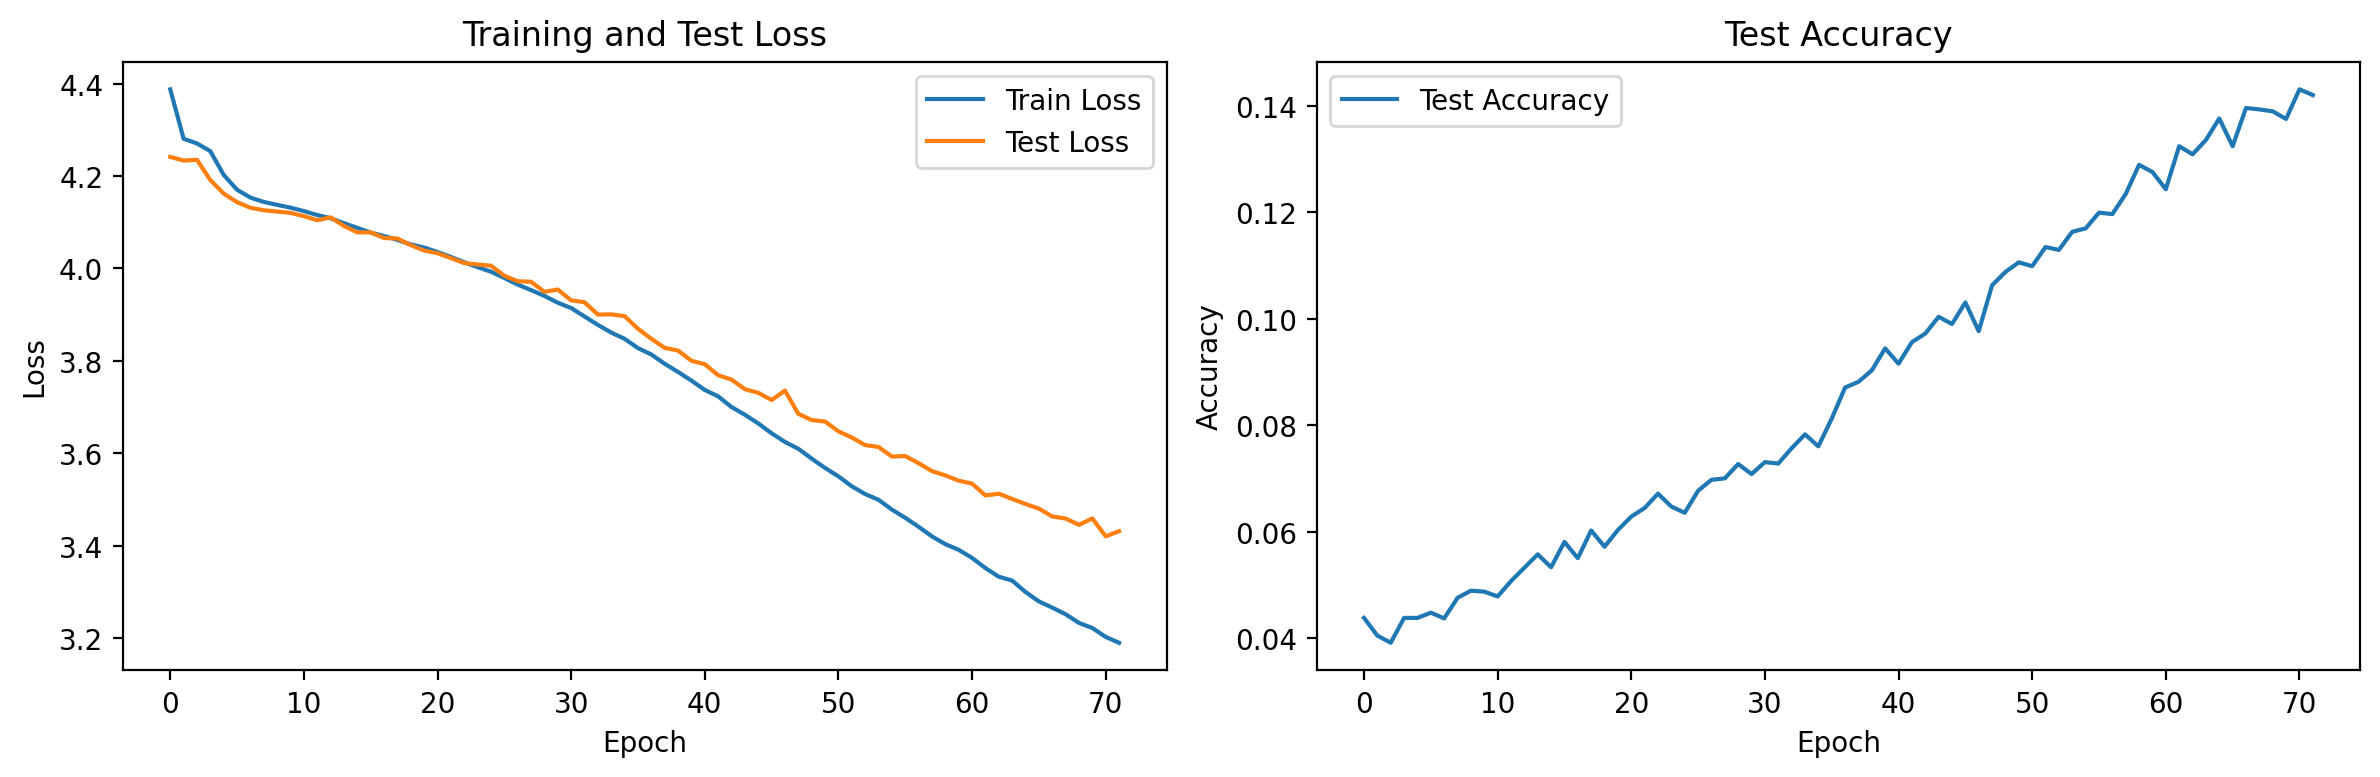

Epoch 72/100, Train Loss: 3.1898, Test Loss: 3.4313, Test Accuracy: 0.1420
Epoch 73/100, Train Loss: 3.1712, Test Loss: 3.3991, Test Accuracy: 0.1489
Epoch 74/100, Train Loss: 3.1528, Test Loss: 3.4006, Test Accuracy: 0.1457
Epoch 75/100, Train Loss: 3.1345, Test Loss: 3.3770, Test Accuracy: 0.1509
Epoch 76/100, Train Loss: 3.1234, Test Loss: 3.3867, Test Accuracy: 0.1512
Epoch 77/100, Train Loss: 3.1054, Test Loss: 3.3901, Test Accuracy: 0.1491
Epoch 78/100, Train Loss: 3.0968, Test Loss: 3.3647, Test Accuracy: 0.1569
Epoch 79/100, Train Loss: 3.0736, Test Loss: 3.3529, Test Accuracy: 0.1533
Epoch 80/100, Train Loss: 3.0671, Test Loss: 3.3436, Test Accuracy: 0.1597
Epoch 81/100, Train Loss: 3.0523, Test Loss: 3.3359, Test Accuracy: 0.1572


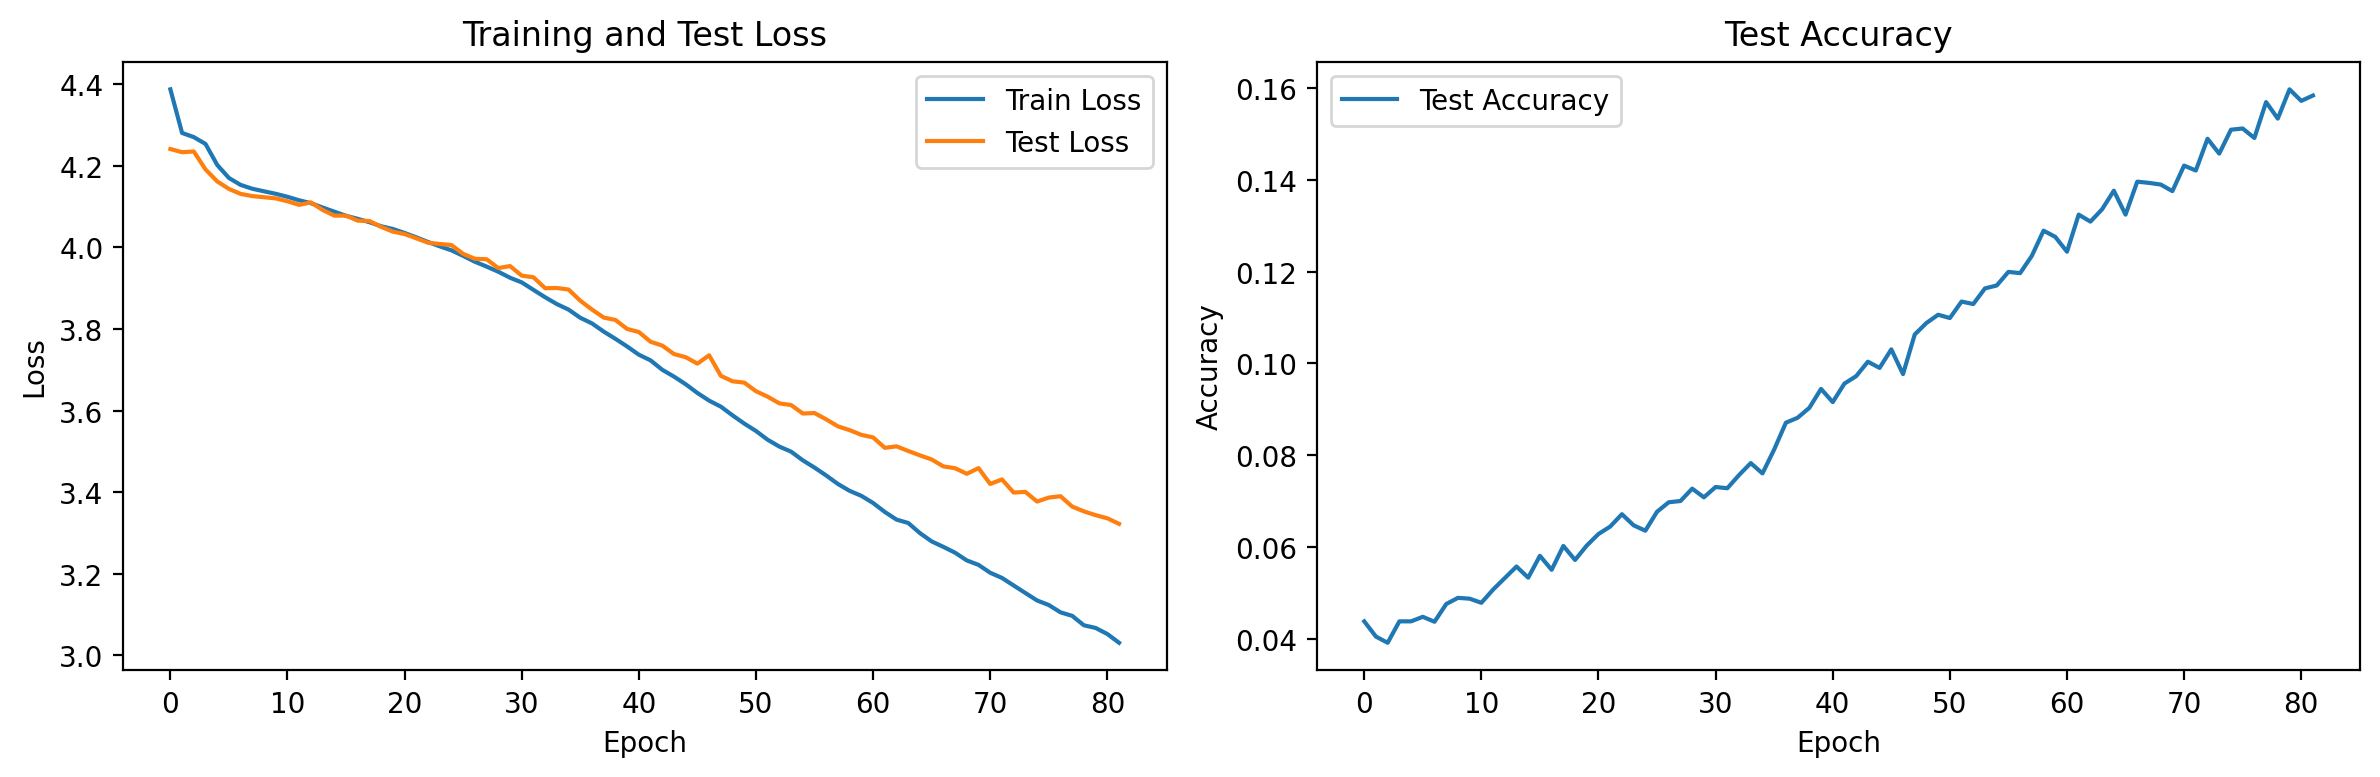

Epoch 82/100, Train Loss: 3.0308, Test Loss: 3.3223, Test Accuracy: 0.1583
Epoch 83/100, Train Loss: 3.0201, Test Loss: 3.3233, Test Accuracy: 0.1583
Epoch 84/100, Train Loss: 3.0049, Test Loss: 3.3225, Test Accuracy: 0.1601
Epoch 85/100, Train Loss: 2.9849, Test Loss: 3.3063, Test Accuracy: 0.1606
Epoch 86/100, Train Loss: 2.9723, Test Loss: 3.3038, Test Accuracy: 0.1614
Epoch 87/100, Train Loss: 2.9679, Test Loss: 3.2860, Test Accuracy: 0.1670
Epoch 88/100, Train Loss: 2.9496, Test Loss: 3.2986, Test Accuracy: 0.1637
Epoch 89/100, Train Loss: 2.9311, Test Loss: 3.2772, Test Accuracy: 0.1696
Epoch 90/100, Train Loss: 2.9290, Test Loss: 3.2631, Test Accuracy: 0.1730
Epoch 91/100, Train Loss: 2.9062, Test Loss: 3.2624, Test Accuracy: 0.1715


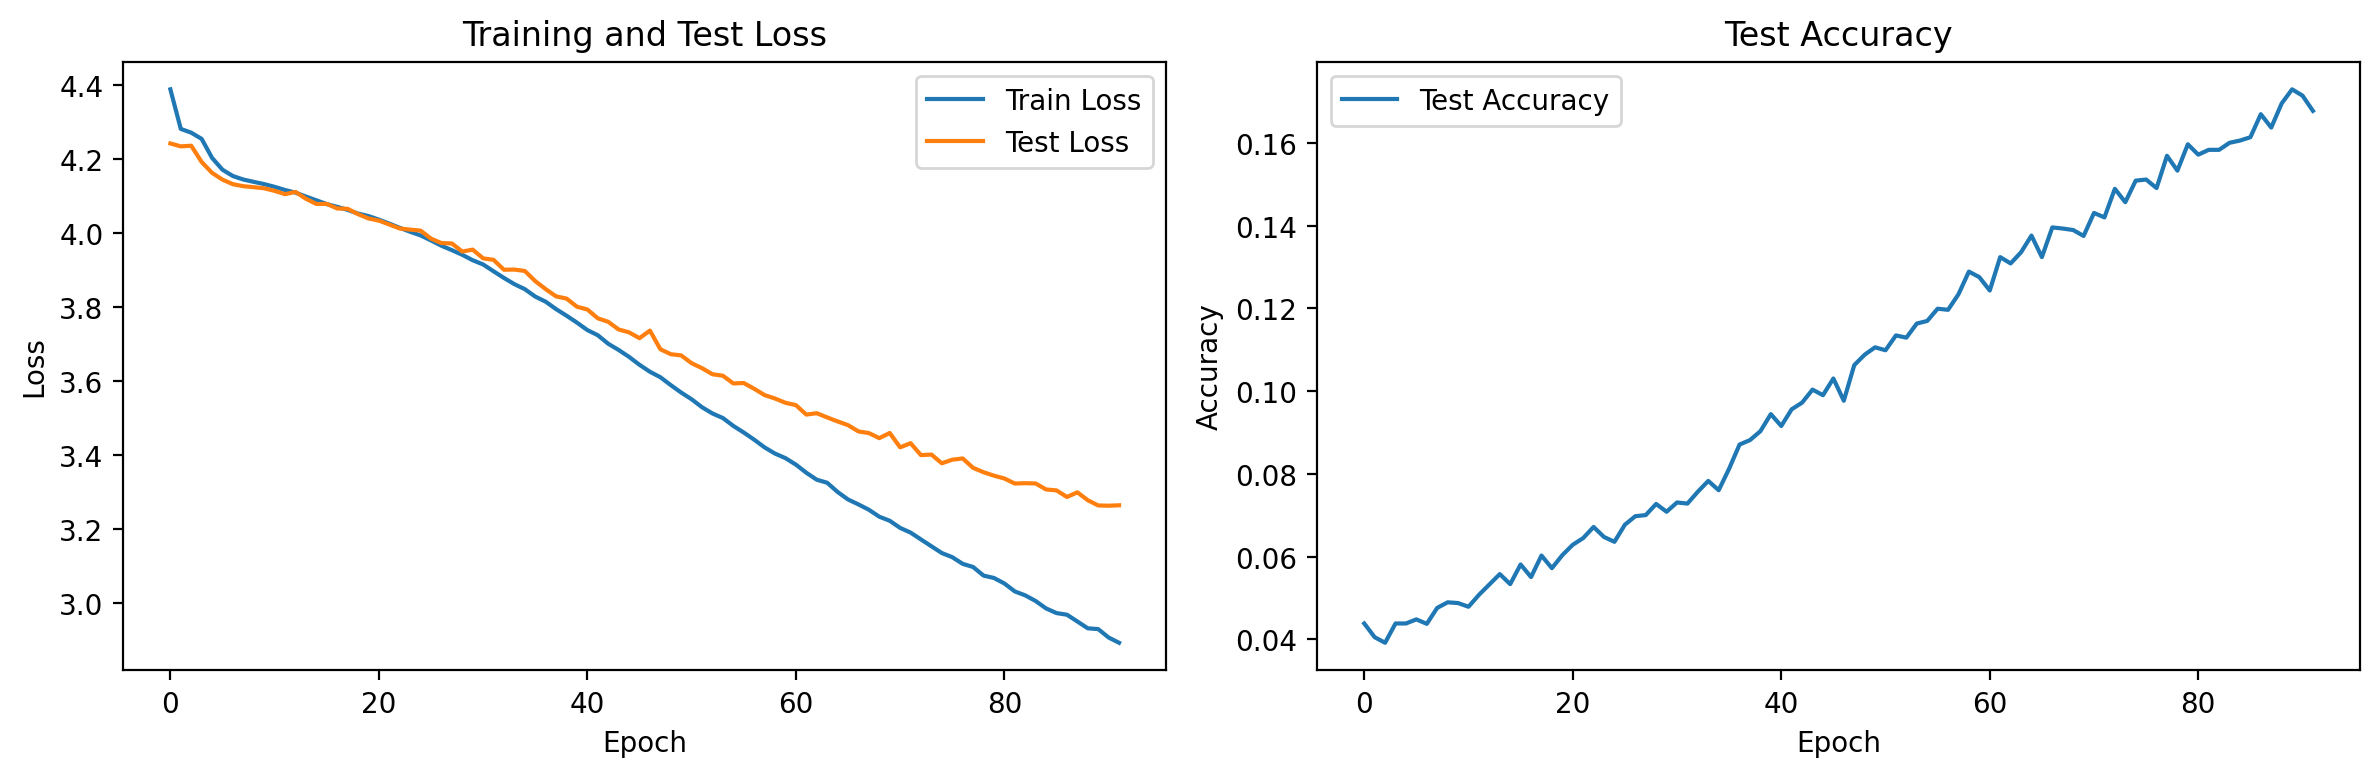

Epoch 92/100, Train Loss: 2.8921, Test Loss: 3.2635, Test Accuracy: 0.1678
Epoch 93/100, Train Loss: 2.8769, Test Loss: 3.2569, Test Accuracy: 0.1718
Epoch 94/100, Train Loss: 2.8617, Test Loss: 3.2379, Test Accuracy: 0.1795
Epoch 95/100, Train Loss: 2.8582, Test Loss: 3.2419, Test Accuracy: 0.1757
Epoch 96/100, Train Loss: 2.8361, Test Loss: 3.2360, Test Accuracy: 0.1766
Epoch 97/100, Train Loss: 2.8224, Test Loss: 3.2184, Test Accuracy: 0.1794
Epoch 98/100, Train Loss: 2.8115, Test Loss: 3.2147, Test Accuracy: 0.1826
Epoch 99/100, Train Loss: 2.8009, Test Loss: 3.2000, Test Accuracy: 0.1864
Epoch 100/100, Train Loss: 2.7831, Test Loss: 3.1954, Test Accuracy: 0.1867


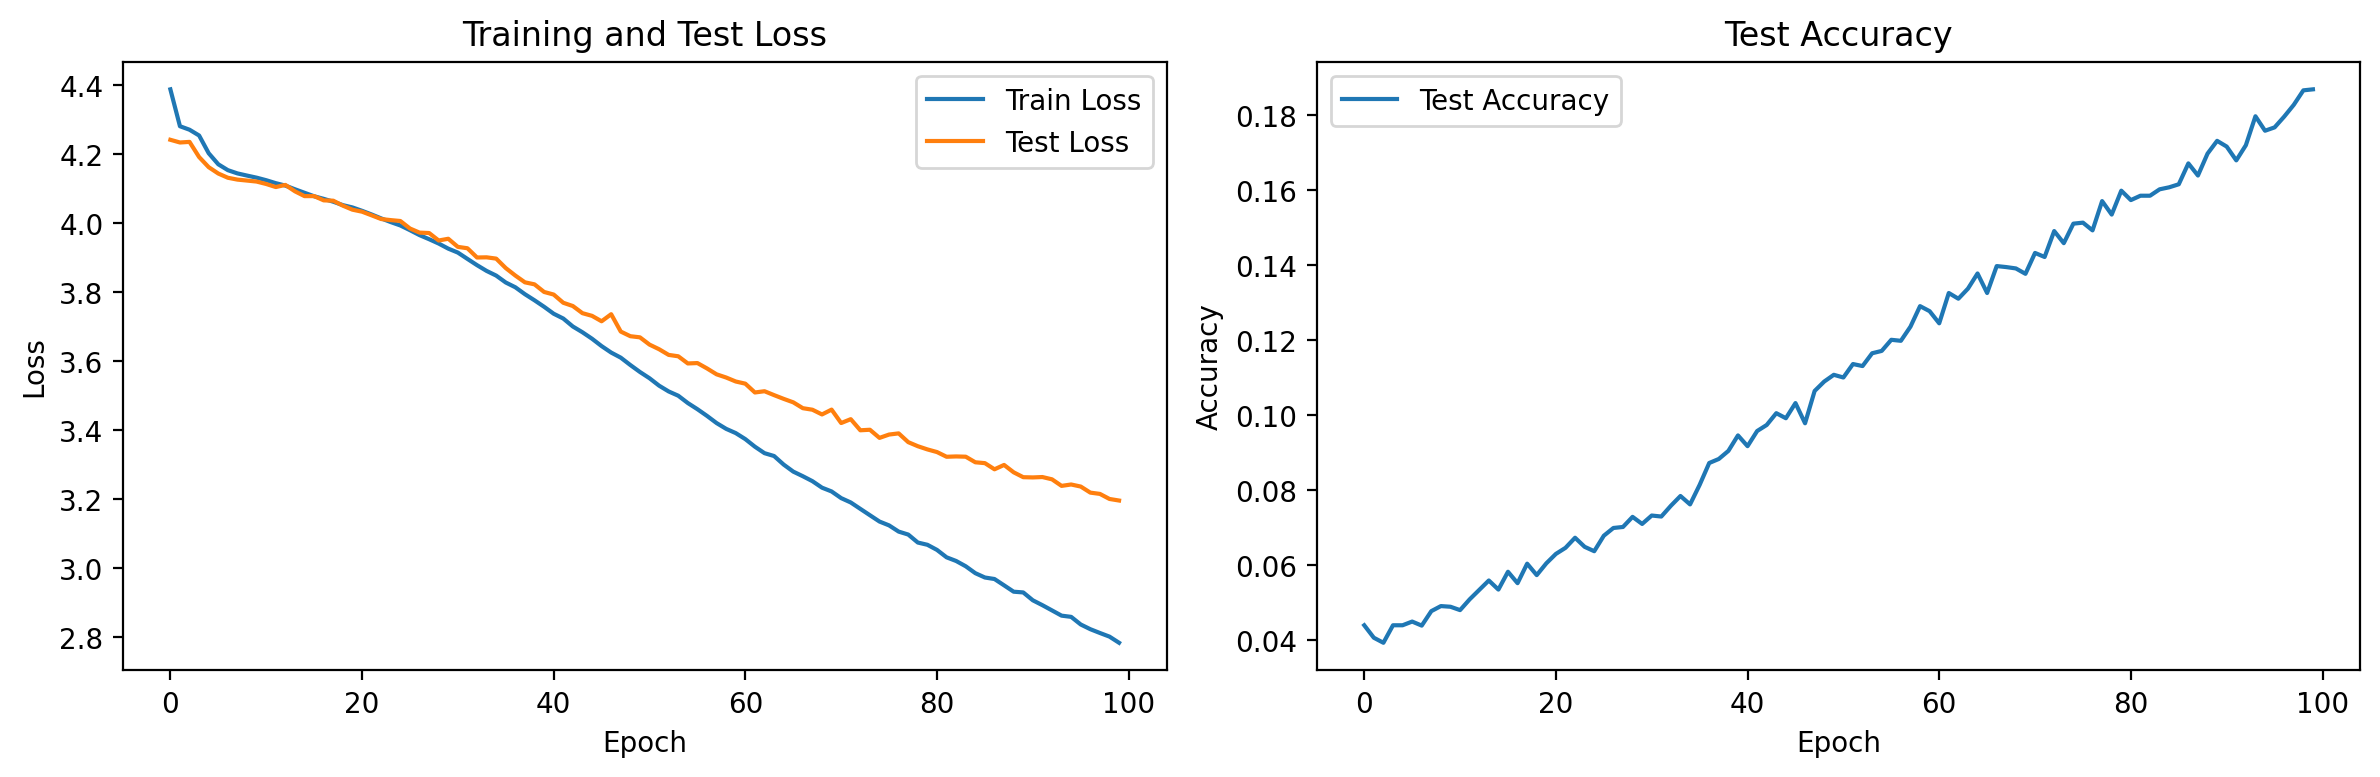

Model saved as 'music_generator_model_mozart.pth'
Generating sample music...
Sample of generated notes:
['A2', 'G5', 'F5', 'F5', 'A5', 'A5', 'A5', 'G5', 'E-5', 'F5']
Generated music saved to 'generated_music_mozart.txt'


AttributeError: 'str' object has no attribute 'Note'

In [ ]:
all_pieces_notes = preprocess_data(chopin_midi_dir = "./mozart")

network_input, network_output, note_to_int, int_to_note = process_notes_for_training(
        all_pieces_notes,
        min_occurrences=4,
        sequence_length=40
    )

save_processed_data(network_input, network_output, note_to_int, int_to_note, output_dir="./processed_data_mozart")

# Split data into train and test sets
train_loader, test_loader = pretrain_dataset(
    network_input,
    network_output,
    test_size=0.2,
    batch_size=64
)


sequence_length = network_input.shape[1]
n_vocab = network_output.shape[1]

# Initialize model with architecture from the image
model = DropOutMusicLSTM(
    input_size=1,       # Single feature (note index)
    output_size=n_vocab # Size of output (vocabulary size)
)

# Print model summary to confirm architecture
print("Model Architecture:")
print(model)

# Calculate total parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

# Choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Choose loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Train model
print("Starting training...")
model, history = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    num_epochs=100,
    device=device
)

# Plot training history
plot_training_history(history)

# Save model
torch.save(model.state_dict(), 'music_generator_model_mozart.pth')
print("Model saved as 'music_generator_model_mozart.pth'")

# Generate sample music
print("Generating sample music...")
# Get a random seed sequence from the test set
seed_sequence = network_input[0]
seed_sequence = seed_sequence.reshape((sequence_length, 1))

generated_notes = generate_music(
    model,
    seed_sequence,
    int_to_note,
    sequence_length,
    n_vocab,
    num_notes=100
)

print("Sample of generated notes:")
print(generated_notes[:10])

# Save generated notes to a file
with open('generated_music_mozart.txt', 'w') as f:
    for note1 in generated_notes:
        f.write(f"{note1}\n")


print("Generated music saved to 'generated_music_mozart.txt'")

notes_to_midi("generated_music_mozart.txt", "generated_music_mozart.mid")
midi_to_wav("generated_music_mozart.mid", "generated_music_mozart.wav")